## Car Price Prediction(Machine Learning assignment 1)

This notebook builds a complete ML pipeline to predict car prices
using a real-world dataset covering EDA, preprocessing, regression,
and KNN classification.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split , KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score,classification_report, confusion_matrix ,accuracy_score
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    PowerTransformer,
)


### 1.load the dataset and preform the EDA

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\projects\machinelearning\car_price.csv")

In [3]:
print(f'Shape:{df.shape}')

Shape:(72435, 10)


In [4]:
#Inspecting column data types, non-null counts, and memory usage to understand the overall structure of the data.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB


In [6]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [5]:
# Descriptive Statistics
#Summary statistics (mean, std, min, max, quartiles) for all numerical
#features to understand distributions and spot potential anomalies.
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


### THE VISUALIZATION OF THE EDA :

1) Price Distribution plot
Visualizing the distribution of the target variable `price`
to understand its spread and skewness.

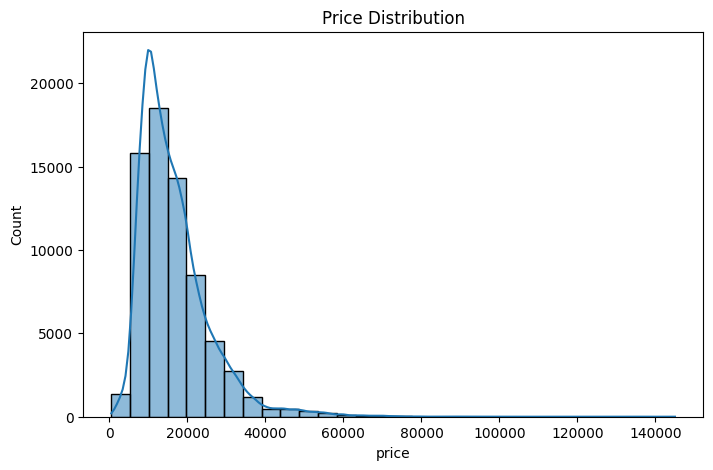

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

2) Correlation Matrix
A heatmap showing correlations between all numerical features
and the target `price` — helps identify the most predictive features.

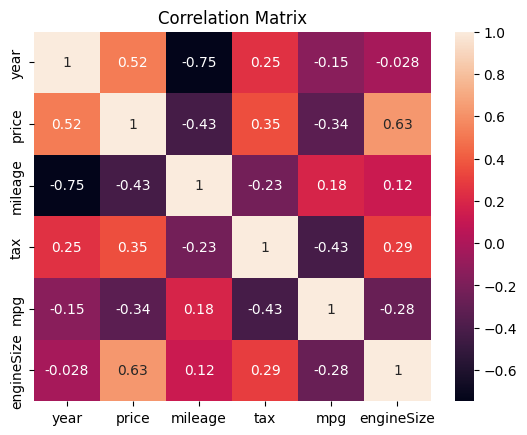

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64

In [8]:
corr = df.corr(numeric_only=True)
plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()
# correlation with price
corr['price'].sort_values(ascending=False)

3) Fuel Type Analysis plot 
Exploring the distribution of fuel types and their relationship
with average car price.

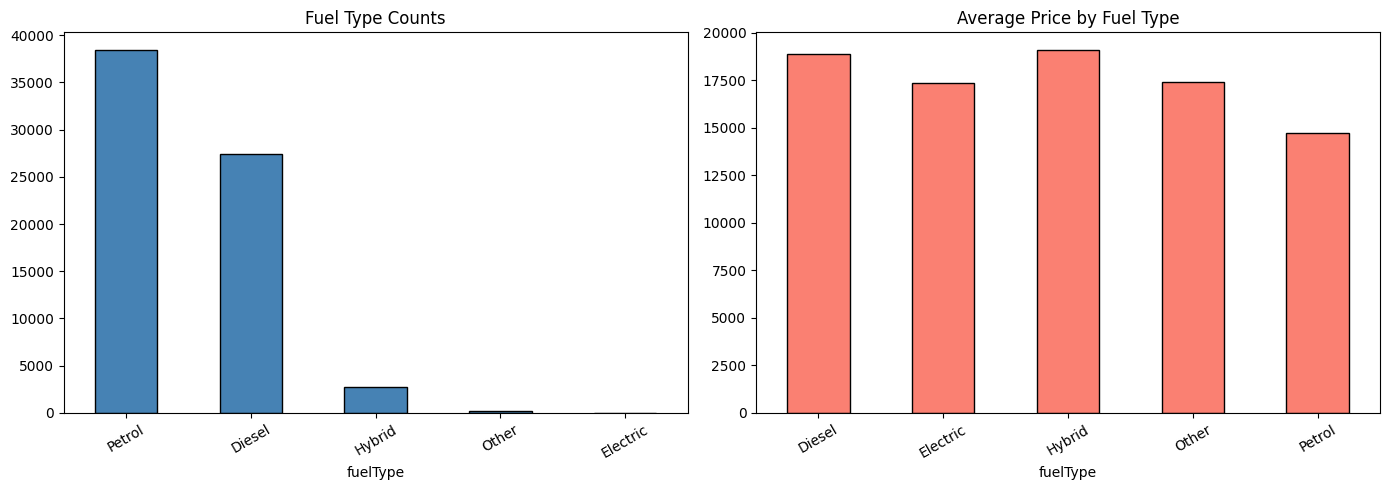

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of fuel types
df['fuelType'].value_counts().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Fuel Type Counts')
axes[0].tick_params(axis='x', rotation=30)

# Average price by fuel type
df.groupby('fuelType')['price'].mean().plot.bar(
    ax=axes[1], color='salmon', edgecolor='black'
)
axes[1].set_title('Average Price by Fuel Type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

4.Transmission Type Analysis
Exploring the distribution of transmission types and how they
relate to average car price.

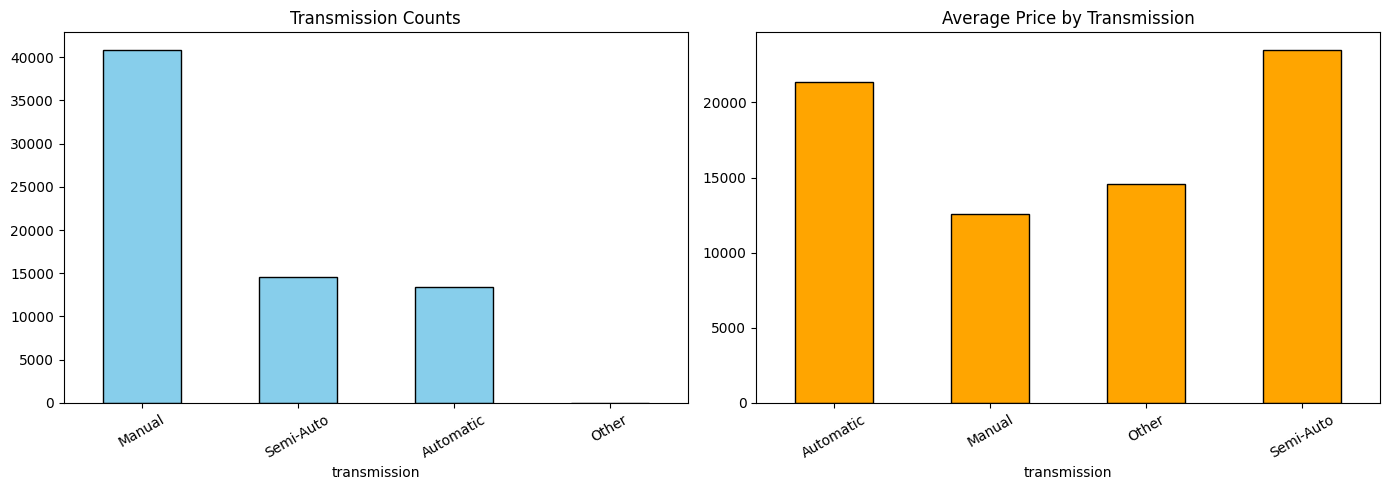

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of transmission types
df['transmission'].value_counts().plot.bar(
    ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Transmission Counts')
axes[0].tick_params(axis='x', rotation=30)

# Average price by transmission
df.groupby('transmission')['price'].mean().plot.bar(
    ax=axes[1], color='orange', edgecolor='black'
)
axes[1].set_title('Average Price by Transmission')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

 5.Car Make Analysis
Identifying the top 10 most common car manufacturers
and comparing their average prices.

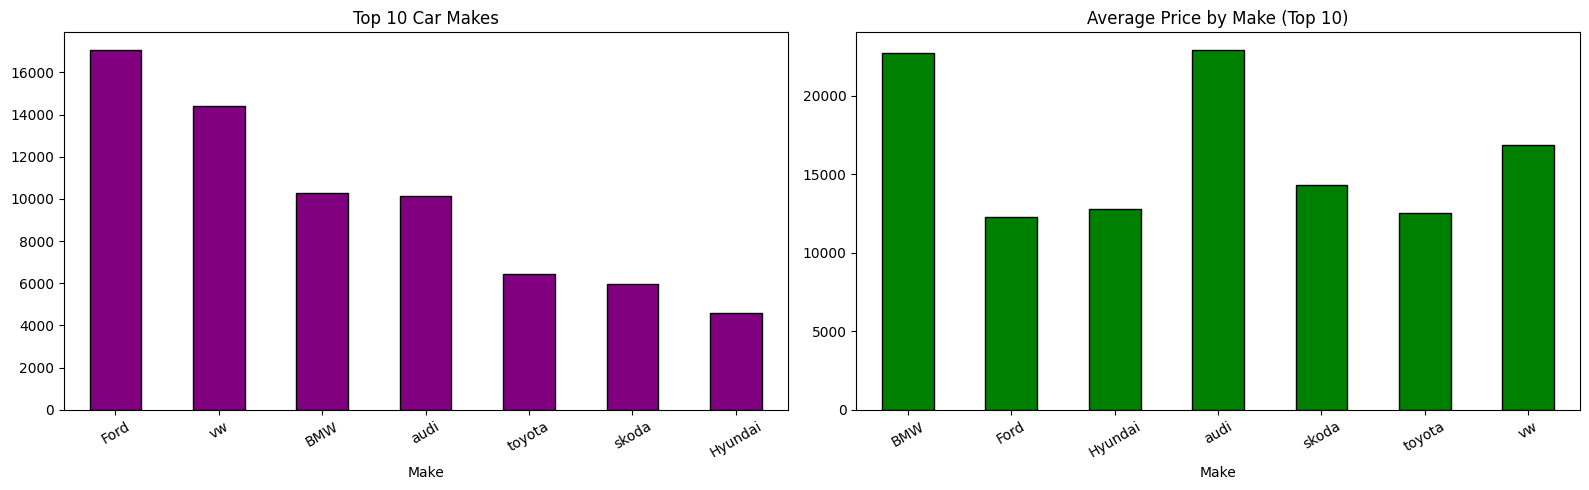

In [11]:
top_makes = df['Make'].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count of top makes
df['Make'].value_counts().head(10).plot.bar(
    ax=axes[0], color='purple', edgecolor='black'
)
axes[0].set_title('Top 10 Car Makes')
axes[0].tick_params(axis='x', rotation=30)

# Average price by make
df[df['Make'].isin(top_makes)].groupby('Make')['price'].mean().plot.bar(
    ax=axes[1], color='green', edgecolor='black'
)
axes[1].set_title('Average Price by Make (Top 10)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 2.PREPROCESSING 
In this stage, several preprocessing steps were applied to clean and prepare the data before building the model.


In [12]:
print(df.shape)
print('the number of duplicated rows:')
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('the shape after removing duplicates:')
print(df.shape)
 

(72435, 10)
the number of duplicated rows:
366
the shape after removing duplicates:
(72069, 10)


#### 2.calculating the no.of null values in each column and visualize it

model           3620
year            3622
price           3607
transmission    3622
mileage         3592
fuelType        3619
tax             3619
mpg             3621
engineSize      3619
Make            3620
dtype: int64


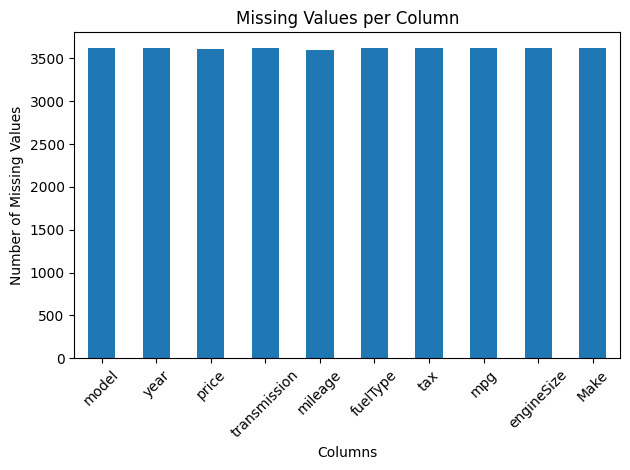

(72069, 10)


In [13]:
print(df.isnull().sum())
missing = df.isnull().sum()
missing = missing[missing > 0]
plt.figure()
missing.plot(kind='bar')

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(df.shape)
 
 
 

#### 3. Handling Missing Values (Target Variable)
Next, rows with missing values in the **target variable (price)** were dropped.


In [14]:
print('the number of null values in price column:')
print(df['price'].isnull().sum())
df.dropna(subset=["price"], inplace=True) 
#  we will  drop the rows with null values in price because it is the target variable and we can not train the model without it
df.shape 

the number of null values in price column:
3607


(68462, 10)

#### 4. Data Splitting
 the dataset was split into **training** and **testing** sets.
-test_size=0.2 → 80% train, 20 % test
- random_state=42 →for reproducible results
- defining features and target (x,y)

**This is done to:**
- Train the model on one portion of the data (training set).
- Evaluate its performance on unseen data (testing set).
- Ensure the model generalizes well and does not overfit.

In [15]:
x = df.drop("price", axis=1)
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)

(54769, 9)
(13693, 9)


#### 5.Missing Value Imputation
- **Numerical columns** → filled with training **median** (robust to outliers)
- **Categorical columns** → filled with training **mode** (most frequent value)
- All statistics computed from training data only — no data leakage.

**note**
Missing values were **not dropped** from the dataset.  
Instead, they were handled using appropriate techniques 

Dropping rows with null values may:
- Reduce the dataset size significantly
- Remove useful patterns from the data
- Introduce bias if the missing data is not random

Therefore, keeping the data and handling missing values appropriately helps preserve information and improves model performance.

In [16]:

for col in ['year', 'engineSize', 'tax', 'mpg', 'mileage']:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col]  = X_test[col].fillna(median_val)

# ── Categorical: fill with train mode
for col in ['model', 'Make', 'transmission', 'fuelType']:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)

# ── Check
print('the number of null values in the training after filling:')
print(X_train.isnull().sum().sum())
print('the number of null values in the testing after filling:')
print(X_test.isnull().sum().sum())

the number of null values in the training after filling:
0
the number of null values in the testing after filling:
0


#### 6.Outlier Handling (IQR Method)

Outliers in numerical features were detected using the IQR method and replaced with the column median.  
The bounds were computed from the training data and then applied to both training and testing sets to prevent data leakage.

The **median** was used instead of the mean because it is more robust to extreme values and is not influenced by outliers. This makes it a more reliable measure of central tendency when handling skewed data.

Outliers were **not removed** from the dataset because:
- Removing them could lead to loss of important information
- Some outliers may represent valid real-world observations rather than errors
- Dropping rows reduces the dataset size, which may negatively affect model performance

Therefore, replacing outliers with the median helps reduce their impact while preserving the overall structure and size of the dataset.


In [17]:

numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
for col in numerical_cols:
    # Calculate bounds and median from original data
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Fix negative bounds
    if col in ['mileage', 'tax']:
        lower = max(0, lower)
    
    median_val = X_train[col].median()
    
    # Count outliers before
    outliers_before = X_train[(X_train[col] < lower) | (X_train[col] > upper)]
    print(f"{col}: {len(outliers_before)} outliers before handling")
    
    # Fill outliers with median (Train)
    mask_train = (X_train[col] < lower) | (X_train[col] > upper)
    X_train.loc[mask_train, col] = median_val
    
    # Fill outliers with median (Test) using same bounds from train
    mask_test = (X_test[col] < lower) | (X_test[col] > upper)
    X_test.loc[mask_test, col] = median_val
    
    # Count after
    outliers_after = X_train[(X_train[col] < lower) | (X_train[col] > upper)]
    print(f"{col}: {len(outliers_after)} outliers after handling (filled with median)")


year: 936 outliers before handling
year: 0 outliers after handling (filled with median)
mileage: 2452 outliers before handling
mileage: 0 outliers after handling (filled with median)
tax: 15838 outliers before handling
tax: 0 outliers after handling (filled with median)
mpg: 796 outliers before handling
mpg: 0 outliers after handling (filled with median)
engineSize: 245 outliers before handling
engineSize: 0 outliers after handling (filled with median)


**note**
Outliers in Target Variable (Price)
Checking how many outliers exist in `y_train`
using the IQR method — for awareness only, not removed 
because they may represent real values and are important for learning the full price range.


In [18]:
# 2. Outliers on y_train (price)
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_in_price = y_train[(y_train < lower) | (y_train > upper)]
print(f"\nPrice outliers (y_train): {len(outliers_in_price)} outliers")



Price outliers (y_train): 2014 outliers


#### 7.Feature Encoding

- `model` → **Target Encoding** (replaced with mean price per model)  
- `transmission`, `fuelType`, `Make` → **One-Hot Encoding**  
- Columns are aligned after OHE to ensure train/test have identical structure  

**Why Target Encoding instead of Label Encoding for `model`:**
Target encoding was used because `model` is a high-cardinality categorical feature (many unique values).  
Label encoding would assign arbitrary numerical values, which may introduce **false ordinal relationships** between categories.  

In contrast, target encoding replaces each category with the **mean of the target variable (Price)**, allowing the model to capture meaningful relationships between car models and their prices.

**Why `fillna` was used after encoding:**
After applying target encoding, some categories in the test set may not exist in the training set, resulting in missing values.  

These missing values were filled using the **global mean of the target variable** to:
- Ensure no missing values remain in the dataset  
- Provide a reasonable default estimate for unseen categories  
- Maintain consistency between training and testing data  

This helps prevent errors during model training and improves generalization.


In [19]:
  
## Compute target mean directly
target_means = y_train.groupby(X_train['model']).mean()

# Apply encoding
X_train['model'] = X_train['model'].map(target_means)

# Handle test set
global_mean = y_train.mean()
X_test['model'] = X_test['model'].map(target_means).fillna(global_mean)

# ── One Hot Encoding → transmission, fuelType, Make
ohe_cols = ['transmission', 'fuelType', 'Make']
X_train = pd.get_dummies(X_train, columns=ohe_cols)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols )

# ── Align columns (in case test is missing some categories)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(X_train.shape)

print(X_test.shape)
X_train.head()

(54769, 22)
(13693, 22)


,model,year,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
69290,8769.746914,2015.0,45908.0,145.0,43.6,1.6,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False
14944,15722.209464,2019.0,7796.0,145.0,47.9,2.0,False,False,False,True,...,False,False,True,True,False,False,False,False,False,False
61872,20986.131034,2019.0,2186.0,145.0,50.4,2.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
8396,30258.224458,2014.0,63000.0,145.0,37.7,2.0,False,True,False,False,...,False,False,True,False,True,False,False,False,False,False
36224,12422.250305,2019.0,999.0,145.0,45.6,1.0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False


#### 8.Feature Scaling (StandardScaler)
Numerical features are standardized to have mean=0 and std=1.
This is critical for KNN which is distance-based and sensitive to feature scale.
Scaler is fitted on training data only and applied to both sets.

In [20]:
x_train_notscaled= X_train.copy()
X_test_notscaled= X_test.copy() 
y_train_notscaled= y_train.copy()
y_test_notscaled= y_test.copy()
print('all the data is saved successfully')

all the data is saved successfully


In [21]:

num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Verify
print(X_train.shape)
print(X_test.shape)
X_train.head()

(54769, 22)
(13693, 22)


,model,year,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
69290,8769.746914,-1.306448,1.708796,0.049814,-1.067666,-0.044159,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False
14944,15722.209464,1.062244,-0.798981,0.049814,-0.662841,0.734204,False,False,False,True,...,False,False,True,True,False,False,False,False,False,False
61872,20986.131034,1.062244,-1.168120,0.049814,-0.427478,0.734204,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
8396,30258.224458,-1.898621,2.833453,0.049814,-1.623124,0.734204,False,True,False,False,...,False,False,True,False,True,False,False,False,False,False
36224,12422.250305,1.062244,-1.246225,0.049814,-0.879376,-1.211705,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False


## 3. Linear Regression

#### 1. Feature Correlation Matrix

##### Purpose
To identify the most highly correlated feature with the target variable for use in simple linear regression.

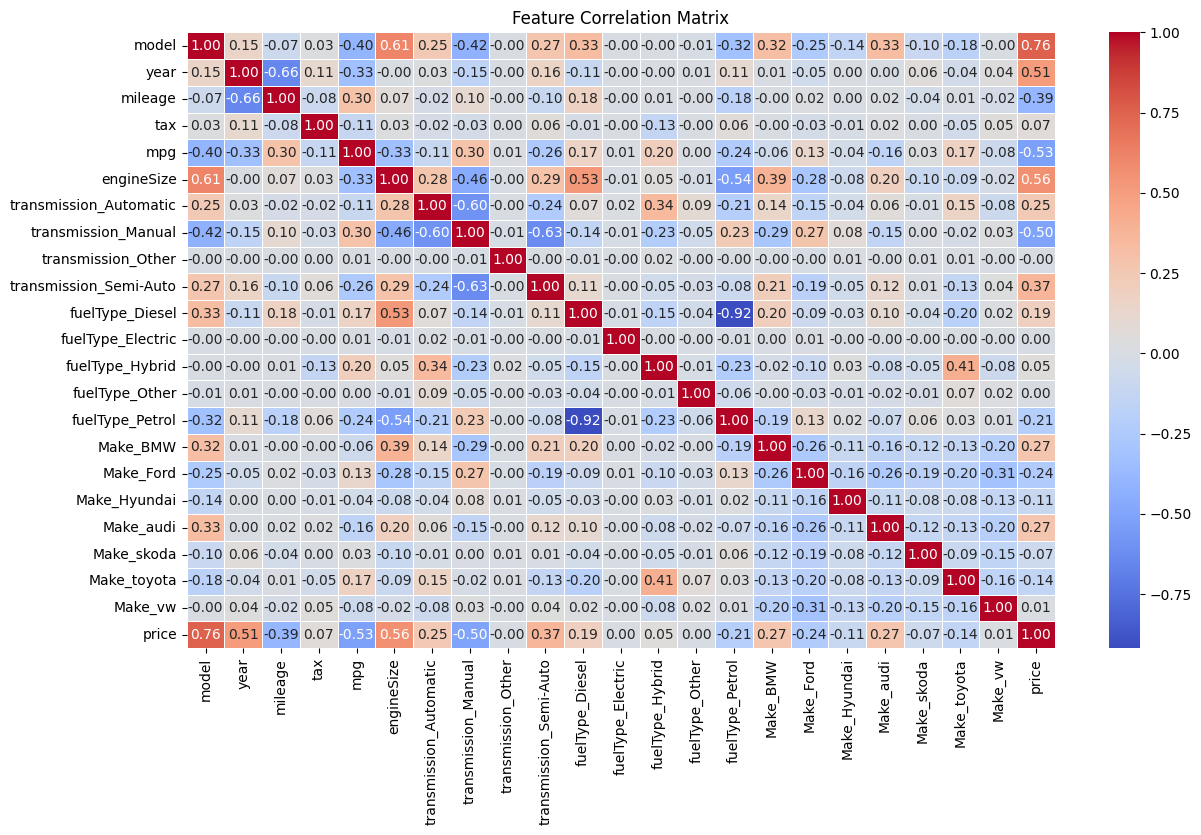

The feature with the strongest correlation to Price is: model


In [22]:
plt.figure(figsize=(14, 8))
data = pd.concat([X_train, y_train], axis=1)
correlation_matrix = data.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

most_cor_feature = correlation_matrix['price'].drop('price').abs().idxmax()

print(f"The feature with the strongest correlation to Price is: {most_cor_feature}")

#### 2. Training the Simple Linear Regression Model

##### Purpose
To train a simple linear regression model using the most correlated feature identified earlier.


In [23]:
Simple_model = LinearRegression()
Simple_model.fit(X_train[[most_cor_feature]] ,y_train)
y_predict_simple = Simple_model.predict(X_test[[most_cor_feature]])
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_predict_simple
})

print(results.head(10))


    Actual     Predicted
0   7234.0   8769.746914
1   9298.0   9868.955237
2  13500.0  15875.690088
3  21698.0  32465.713115
4  10700.0  13243.798666
5  15490.0  15722.209464
6   6640.0   8004.688000
7  18480.0  15722.209464
8   8491.0  12672.017800
9   6295.0   9868.955237


#### 3. Visualization of Simple Linear Regression

##### Purpose
To visualize the relationship between the selected feature and the target variable, along with the fitted regression line.


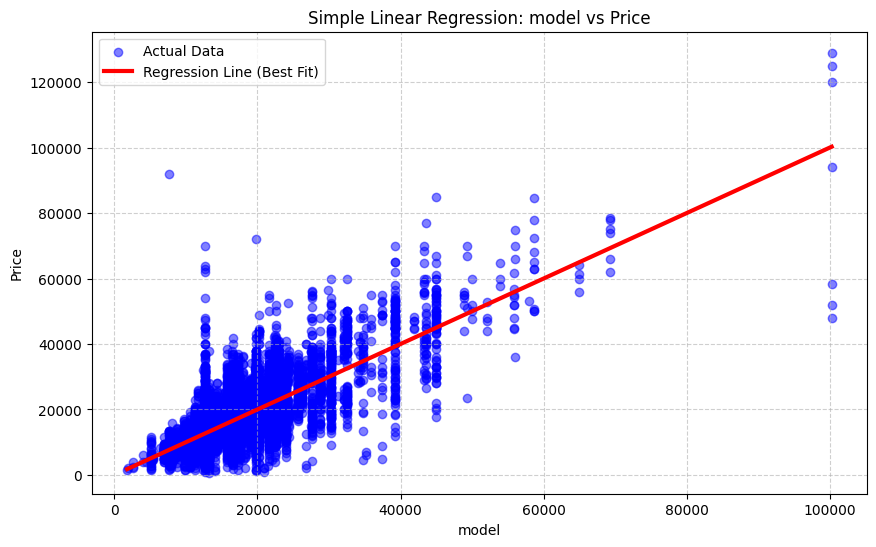

Model Equation: Price = (1.00 * model) + -0.00


In [24]:
feature_name = most_cor_feature
X_test_feature = X_test[[feature_name]]
plt.figure(figsize=(10, 6))
plt.scatter(X_test_feature, y_test, color='blue', alpha=0.5, label='Actual Data')
X_range = pd.DataFrame(np.linspace(X_test_feature.min().values[0], X_test_feature.max().values[0], 100),columns=[feature_name])
y_range_pred = Simple_model.predict(X_range)
plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regression Line (Best Fit)')
plt.title(f'Simple Linear Regression: {feature_name} vs Price')
plt.xlabel(feature_name)
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
coef = Simple_model.coef_[0]
intercept = Simple_model.intercept_
print(f"Model Equation: Price = ({coef:.2f} * {feature_name}) + {intercept:.2f}")


#### 4. Multiple Linear Regression Model

##### Purpose
To train a regression model using all available features and evaluate its predictive performance.



In [25]:
all_model = LinearRegression()
all_model.fit(X_train, y_train)
y_predict_all = all_model.predict(X_test)
results_all = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_predict_all
})

print(results_all.head(10))

    Actual     Predicted
0   7234.0   3028.135555
1   9298.0  11099.825022
2  13500.0  15780.233693
3  21698.0  30348.619087
4  10700.0   9814.361208
5  15490.0  12235.177003
6   6640.0    173.116248
7  18480.0  19536.196016
8   8491.0   7648.976243
9   6295.0   5502.085941


#### 5. Residual Analysis

##### Purpose
To verify that the residuals are randomly distributed with no pattern,
which is a key assumption of Linear Regression.

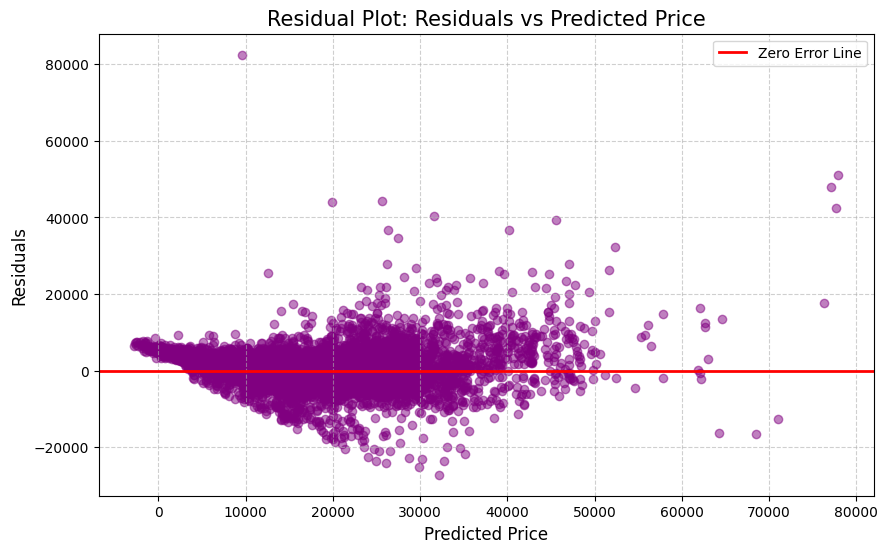

In [26]:
residuals = y_test - y_predict_all


plt.figure(figsize=(10, 6))
plt.scatter(y_predict_all, residuals, alpha=0.5, color='purple')
plt.axhline(0, color='red', linewidth=2, label='Zero Error Line')
plt.title('Residual Plot: Residuals vs Predicted Price', fontsize=15)
plt.xlabel('Predicted Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



#### 6. Model Evaluation and Comparison

##### Purpose
To evaluate and compare the performance of simple and multiple linear regression models using standard regression metrics.


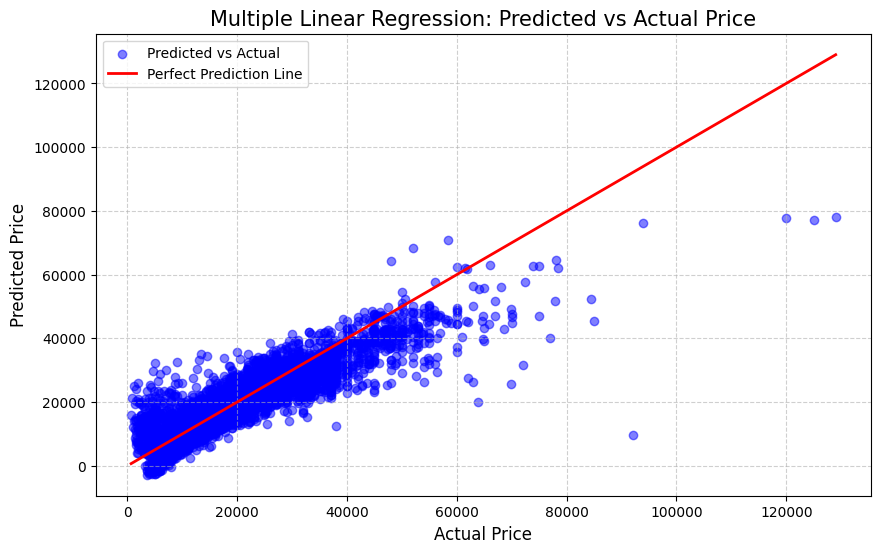

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict_all, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red', linewidth=2, label='Perfect Prediction Line')
plt.title('Multiple Linear Regression: Predicted vs Actual Price', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### model comparison results 

In [28]:
r2_simple = r2_score(y_test, y_predict_simple)
mse_simple = mean_squared_error(y_test, y_predict_simple)
rmse_simple = np.sqrt(mse_simple)
r2_all = r2_score(y_test, y_predict_all)
mse_all = mean_squared_error(y_test, y_predict_all)
rmse_all = np.sqrt(mse_all)
print(" Model Comparison Results\n")
print(" Simple Linear Regression")
print(f"R²   : {r2_simple:.4f}")
print(f"MSE  : {mse_simple:.2f}")
print(f"RMSE : {rmse_simple:.2f}\n")

print(" Multiple Linear Regression")
print(f"R²   : {r2_all:.4f}")
print(f"MSE  : {mse_all:.2f}")
print(f"RMSE : {rmse_all:.2f}\n")
print(" Final Conclusion:")
if r2_all > r2_simple:
    print(" Multiple Linear Regression performs better because it uses more features and captures more patterns.")
else:
    print("Simple Linear Regression performs better (unexpected case).")

 Model Comparison Results

 Simple Linear Regression
R²   : 0.5897
MSE  : 35295625.55
RMSE : 5941.01

 Multiple Linear Regression
R²   : 0.8134
MSE  : 16052111.54
RMSE : 4006.51

 Final Conclusion:
 Multiple Linear Regression performs better because it uses more features and captures more patterns.


 #### 4.KNN Classification
##### 1. Creating the Classification Target (Price Categories)

Threshold Selection Justification:

 **Percentile-based Thresholds** was used to create three balanced price categories:

- **Cheap threshold (33rd percentile)**: £11,450
- **Expensive threshold (66th percentile)**: £17,990

**Why these thresholds?**
- Using percentiles ensures equal distribution across categories
- Creates roughly equal-sized groups for better model training
- Categories represent "bottom third", "middle third", and "top third" of prices

In [29]:
# Define boundaries based on what you saw in describe() above

cheap_limit = float(df['price'].quantile(0.33))
expensive_limit = float(df['price'].quantile(0.66))

print(f"Cheap threshold: {cheap_limit}")
print(f"Expensive threshold: {expensive_limit}")

def categorize_price(price):
    price = float(price)  # force it to plain number no matter what comes in
    if price <= cheap_limit:
        return 'Cheap'
    elif price <= expensive_limit:
        return 'Moderate'
    else:
        return 'Expensive'
    # Convert the numeric target to categorical target
y_train = y_train.apply(categorize_price)
y_test = y_test.apply(categorize_price)



Cheap threshold: 11450.0
Expensive threshold: 17990.0


##### 2.After applying the thresholds:
- **Cheap** (price ≤ £11,450): 18,113 cars (33.3%)
- **Moderate** (£11,450 < price ≤ £17,990): 18,087 cars (33.3%)
- **Expensive** (price > £17,990): 18,569 cars (34.1%)

The distribution is nearly balanced, which is ideal for classification tasks as it prevents the model from biasing toward a majority class.

price
Expensive    18569
Cheap        18113
Moderate     18087
Name: count, dtype: int64


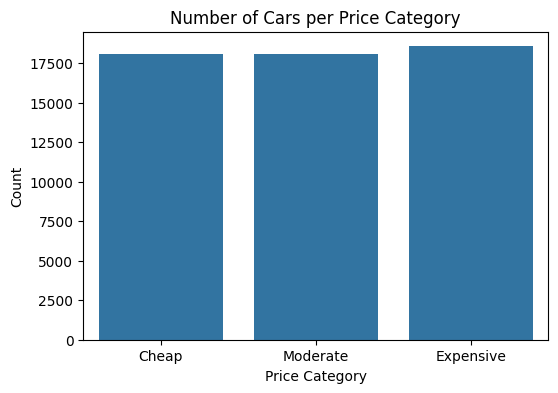

In [30]:
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train.values,order=['Cheap', 'Moderate', 'Expensive'])
plt.title('Number of Cars per Price Category')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.show()

In [31]:
print("Features shape:", X_train.shape)
print("Target distribution:\n", y_train.value_counts())

Features shape: (54769, 22)
Target distribution:
 price
Expensive    18569
Cheap        18113
Moderate     18087
Name: count, dtype: int64


 #### 3.KNN Model Training with Grid Search(with scaled data )
Parameter Tuning Strategy

To find the optimal KNN configuration, I performed **Grid Search with 5-fold Cross Validation**:

*Parameters tested:*
- **Number of neighbors (k)**: 3, 5, 7, 9, 11, 13, 15 (odd numbers only to avoid ties)
- **Distance metrics**: Euclidean and Manhattan

*Training configuration:*
- **Total models trained**: 7 k-values × 2 metrics × 5 folds = *70 models*
- **Cross-validation**: 5-fold with shuffling (random_state=42 for reproducibility)
- **Scoring metric**: Accuracy
- **Parallel processing**: n_jobs=-1 (using all CPU cores)

 Grid Search Results:

**Best Parameters Found:**
- k = 7 neighbors
- Distance metric = Manhattan

**Best Cross-Validation Accuracy: 86.73%**

**Why Manhattan distance performed best?**
Manhattan distance (L1) is often more robust than Euclidean distance (L2) for high-dimensional data with mixed feature types. In car pricing, features like year, mileage, and tax have different scales and distributions, making Manhattan distance more appropriate as it's less sensitive to outliers.

In [34]:
# Define the parameter grid 
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

# 5 fold cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search object
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,          # use all CPU cores
)

# this trains 7 k values × 2 metrics × 5 folds = 70 models
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best CV Accuracy: 0.8673


#### 4. Model Evaluation on Test Set
*Test Set Performance

The best KNN model achieved **87.02% accuracy** on the unseen test data, which closely matches the cross-validation accuracy (86.73%), indicating:
- **No overfitting**: Model generalizes well to new data
- **Reliable parameters**: The chosen configuration is stable

*Interpretation of metrics:*

- **Precision** (How many predicted cheap cars are actually cheap?):
  - Cheap (90%) and Moderate (90%) have excellent precision
  - Expensive (81%) has slightly lower precision, meaning some expensive predictions are actually moderate-priced cars

- **Recall** (How many actual cheap cars were correctly identified?):
  - All categories show strong recall (81-91%)
  - Moderate performs best at 91% recall

- **F1-Score** (Harmonic mean of precision and recall):
  - Strong performance across all categories (0.89-0.91)
  - Indicates balanced precision-recall trade-off

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

# The best model is already stored inside grid_search
best_model = grid_search.best_estimator_

# Predict on test set
y_pred = best_model.predict(X_test)

# Full evaluation
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Cheap', 'Moderate', 'Expensive']))

Test Set Accuracy: 0.8701526327320529

Classification Report:
              precision    recall  f1-score   support

       Cheap       0.90      0.89      0.89      4515
    Moderate       0.90      0.91      0.91      4702
   Expensive       0.81      0.81      0.81      4476

    accuracy                           0.87     13693
   macro avg       0.87      0.87      0.87     13693
weighted avg       0.87      0.87      0.87     13693



#### 5.Confusion Matrix Analysis

The confusion matrix reveals specific prediction patterns:

**Correct predictions (diagonal):**
- **Cheap correctly predicted**: ~4,020 cars
- **Moderate correctly predicted**: ~3,614 cars  
- **Expensive correctly predicted**: ~3,625 cars

**Misclassification patterns:**
- **Cheap → Moderate**: ~480 cars (confused with mid-range)
- **Moderate → Cheap**: ~280 cars (undervalued predictions)
- **Moderate → Expensive**: ~410 cars (overvalued predictions)
- **Expensive → Moderate**: ~760 cars (most common error)

**Key insight**: The model struggles most with distinguishing between Moderate and Expensive categories (bidirectional confusion). This is expected as the boundary between £17,990 is where pricing becomes more subjective.

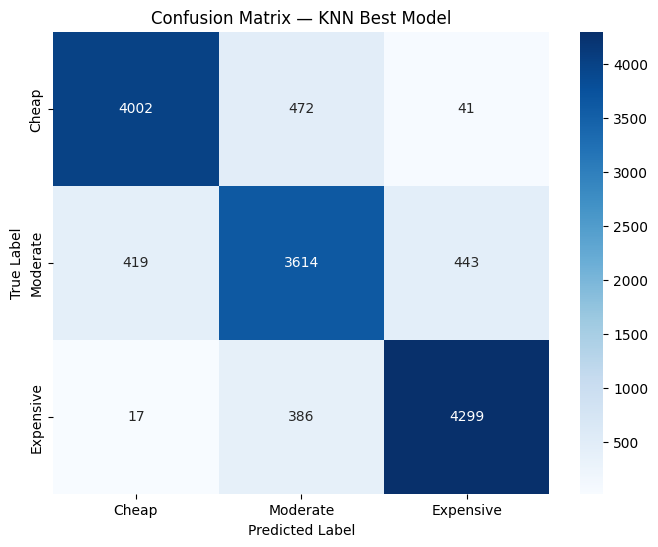

In [36]:
cm = confusion_matrix(y_test, y_pred, labels=['Cheap', 'Moderate', 'Expensive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix — KNN Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##### And also we calculated the knn with k=3 to compare it with k=7

**Comparison: KNN k=3 vs KNN k=7 (Best Model)**

| Metric          | k=3    | k=7 (Best) |
|-----------------|--------|------------|
| CV Accuracy     | 86.30% | 86.73%     |
| Test Accuracy   | 86.69% | 87.01%     |
| Cheap F1        | 0.89   | 0.89       |
| Moderate F1     | 0.90   | 0.91       |
| Expensive F1    | 0.80   | 0.81       |
| Distance Metric | Manhattan | Manhattan |

k=7 outperforms k=3 consistently across all metrics. The improvement comes 
from having more neighbors vote on each prediction — with k=3, a single 
noisy neighbor has 33% influence on the decision, while with k=7 that drops 
to 14%, making predictions more stable and less sensitive to outliers.

Both models independently selected Manhattan distance as optimal, confirming 
it is genuinely better suited for this dataset regardless of k. Neither model 
shows overfitting, as CV and test accuracies remain within 0.4% of each other 
in both cases.

Grid Search successfully identified k=7 as the superior configuration, 
justifying automated tuning over manual selection.

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3}
Best CV Accuracy: 0.8630
Test Set Accuracy: 0.8668662820419192

Classification Report:
              precision    recall  f1-score   support

       Cheap       0.89      0.89      0.89      4515
    Moderate       0.90      0.91      0.90      4702
   Expensive       0.80      0.80      0.80      4476

    accuracy                           0.87     13693
   macro avg       0.87      0.87      0.87     13693
weighted avg       0.87      0.87      0.87     13693



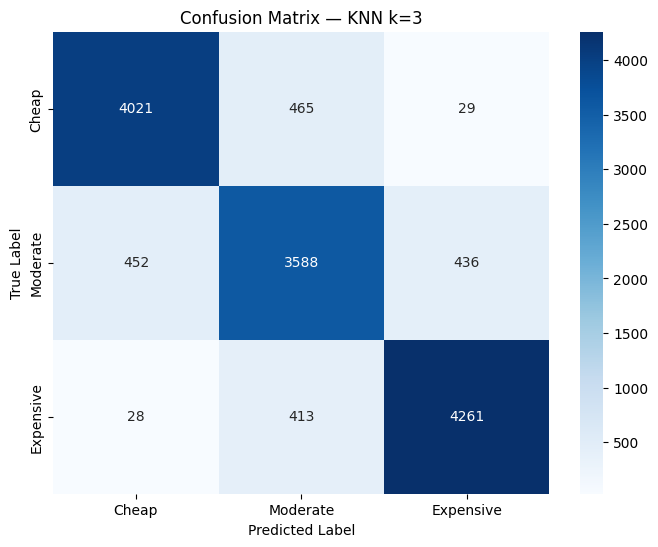

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Fixed KNN at k=3 
param_grid = {
    'n_neighbors': [3],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

# 5 fold cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search object (now just tests 2 metrics at k=3)
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
)

# this trains 1 k value × 2 metrics × 5 folds = 10 models
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

# Evaluation 
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Cheap', 'Moderate', 'Expensive']))
cm = confusion_matrix(y_test, y_pred, labels=['Cheap', 'Moderate', 'Expensive'])  

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix — KNN k=3')  
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 6.Model Comparison

### Q1: Which model performed better, and what does "better" mean in each context?

-  we can't really compare the two models directly because
they're solving completely different problems. One predicts an exact price,
the other just puts the car in a bucket (Cheap / Moderate / Expensive).
So "better" means something different for each one

-  For the **Linear Regression**, we measure performance using R², MSE, and RMSE.
The simple model (using only the most correlated feature) had a lower R² and
higher RMSE than the multiple regression model (using all features). So clearly
the multiple regression model is the better one here , it explains more of the
price variation and makes smaller errors on average. This makes sense because
using more information about will always give a more complete picture than just one feature alone

-  For the **KNN Classifier**, we measure performance using accuracy, precision,
recall, and F1-score. Our best model (k=7, Manhattan distance) achieved 87%
accuracy on the test set, with F1-scores between 0.89 and 0.91 across all three
categories. That's a strong and consistent result , the model isn't just good
at one category and bad at the others, it handles all three well.

---

### Q2: Is classification easier than regression on this dataset? Why or why not?

Yes, classification is easier here and honestly it makes a lot of sense
when you think about it.

With regression, the model has to predict the exact price of every single car.
Even if it gets the general range right, being off by £1,000 still counts as
an error. Car prices are affected by so many small detailsthat it's very hard 
for any model to nail the exact number every time.

With classification, we gave the model a much simpler job , just decide
if the car is Cheap, Moderate, or Expensive. A car priced at £11,600 and
one priced at £14,000 are both just "Moderate". The model doesn't need to
know the difference between them, which makes the task a lot more forgiving.

Also, looking at our price distribution from the EDA, prices are right-skewed
, there are a few very expensive cars that pull the distribution to the right.
This kind of skewness makes exact price prediction harder for a linear model,
but it barely affects classification because those expensive cars just fall
into the "Expensive" bucket regardless of how extreme their price is.

So yes , classification is easier, and our results back this up. KNN hitting
87% accuracy is a better outcome than what our regression model achieved
in terms of prediction precision.

---

### Q3: Does converting price into categories lose important information?

Yes, it does and it's worth being honest about that trade-off.

When we converted price into three categories using the 33rd and 66th
percentiles (Cheap ≤ £11,450 / Moderate up to £17,990 / Expensive above that),
we lost a lot of detail. For example, a car worth £11,500 and a car worth
£17,800 both get labeled "Moderate" even though there's a £6,300 difference
between them. The classifier treats them as identical, which they clearly aren't.

The same problem exists at the boundaries. A car priced at £11,400 is "Cheap"
and one at £11,500 is "Moderate" a £100 difference that the model treats
as completely different categories.

That said, this trade-off is sometimes worth it. If the goal is something like
helping a buyer quickly filter cars by budget range, three categories is
perfectly good enough. But if someone needs accurate pricing like a dealership
trying to value a car, or an insurance company calculating premiums  then
losing this level of detail would be a real problem.

So the short answer is: yes, information is lost, but whether that matters
depends entirely on what you're trying to do with the predictions.

## Sensitivity Analysis: Removing the Most Correlated Feature


engineSize has the strongest positive correlation with price, 
We retrained KNN using the best parameters from Grid Search but with engineSize 
removed from the feature set.

Results:
- Accuracy WITH engineSize:     87.01%
- Accuracy WITHOUT engineSize:  84.11%
- Drop in accuracy:             2.90%

The accuracy dropped by approximately 3%, which is a more meaningful drop 
compared to the other sensitivity experiments. This confirms that engineSize 
carries genuine predictive value that is not fully compensated by the 
remaining features. However, the model still maintains reasonable performance 
at 84%, suggesting that while engineSize is important, the other features 
(year, mileage, mpg, tax) collectively provide enough information to 
partially compensate for its absence.

Looking at the classification report, all three categories maintained strong 
performance even without engineSize:
- Cheap:     F1 = 0.87
- Expensive: F1 = 0.88
- Moderate:  F1 = 0.77

Moderate suffers the most (F1 dropped from 0.91 to 0.77), which makes sense 
— mid-range cars are the hardest to distinguish without engine size information, 
as they overlap most with both Cheap and Expensive in other features.

In [38]:

most_correlated = most_cor_feature  # ← we already computed this before, so just reuse it

X_train_dropped = pd.DataFrame(X_train, columns=X_train.columns).drop(columns=[most_correlated])
X_test_dropped  = pd.DataFrame(X_test,  columns=X_train.columns).drop(columns=[most_correlated])

# Retrain best KNN without that feature
knn_dropped = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)
knn_dropped.fit(X_train_dropped, y_train)
y_pred_dropped = knn_dropped.predict(X_test_dropped)

print("Accuracy without most correlated feature:", accuracy_score(y_test, y_pred_dropped))
print(classification_report(y_test, y_pred_dropped))

Accuracy without most correlated feature: 0.8410866866282042
              precision    recall  f1-score   support

       Cheap       0.86      0.88      0.87      4515
   Expensive       0.89      0.87      0.88      4702
    Moderate       0.77      0.77      0.77      4476

    accuracy                           0.84     13693
   macro avg       0.84      0.84      0.84     13693
weighted avg       0.84      0.84      0.84     13693



##### download the nonscaled data from the folder 

In [39]:
import os
os.chdir(r"C:\Users\LENOVO\Downloads\projects\machinelearning") 
# Load everything from teammate's saved CSVs
X_train_unscaled = pd.read_csv('X_train_notscaled.csv')
X_test_unscaled  = pd.read_csv('X_test_notscaled.csv')
y_train_loaded   = pd.read_csv('y_train_notscaled.csv').squeeze()  
y_test_loaded    = pd.read_csv('y_test_notscaled.csv').squeeze()


In [40]:
# Load and take only the price column by name
y_train_loaded = pd.read_csv('y_train_notscaled.csv', index_col=0).squeeze().reset_index(drop=True)
y_test_loaded  = pd.read_csv('y_test_notscaled.csv',  index_col=0).squeeze().reset_index(drop=True)

# Verify it's a Series of numbers
print(type(y_train_loaded))
print(y_train_loaded.head())

y_train_unscaled = y_train_loaded.apply(categorize_price)
y_test_unscaled  = y_test_loaded.apply(categorize_price)



<class 'pandas.Series'>
0     6750.0
1    21480.0
2    18685.0
3    13525.0
4    15999.0
Name: price, dtype: float64


## Sensitivity Analysis: KNN Without Scaling

When KNN was trained on unscaled data, accuracy dropped from 87.01% to 73.59% 
— a decrease of approximately 13.4 percentage points.

This significant drop is explained by how KNN works. KNN classifies each point 
by measuring its distance to neighbors. Without scaling, features with large 
numeric ranges dominate this distance calculation. In our dataset, mileage 
ranges up to 323,000 while engineSize ranges from 0 to 6.6. Without scaling, 
a small difference in mileage contributes far more to the distance than a large 
difference in engineSize, even if engineSize is actually more informative for 
predicting price category.

StandardScaler fixed this by transforming all features to have mean=0 and 
standard deviation=1, giving each feature an equal role in the distance 
calculation. The 13.4% accuracy improvement confirms that scaling is not 
optional for KNN — it is a necessary preprocessing step that directly impacts 
model performance.

In [41]:
knn_notscaled = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)
knn_notscaled.fit(X_train_unscaled, y_train_unscaled)
y_pred_notscaled = knn_notscaled.predict(X_test_unscaled)

print("Accuracy WITHOUT scaling:", accuracy_score(y_test_unscaled, y_pred_notscaled))
print("Accuracy WITH scaling:   ", accuracy_score(y_test, y_pred))

Accuracy WITHOUT scaling: 0.7359234645439275
Accuracy WITH scaling:    0.8668662820419192


## Sensitivity Analysis: Different Price Category Thresholds

We retrained KNN using alternative thresholds based on the 25th and 75th 
percentiles instead of the original 33rd and 66th percentiles.

Original thresholds (33rd/66th): ~18,000 cars per category (balanced thirds)
New thresholds (25th/75th): Cheap=13,720 | Moderate=27,355 | Expensive=13,694

Results:
- Accuracy with original thresholds: 86.69%
- Accuracy with new thresholds:      86.83%
- Difference:                         0.14%

The accuracy barely changed despite a significantly different class 
distribution. This indicates that KNN's performance on this dataset is 
robust to threshold selection. The reason is that KNN learns from the 
geometric structure of the feature space — since the features and underlying 
data did not change, the natural neighborhoods KNN discovers remain largely 
the same regardless of where the price boundary is drawn.

The only cars affected by the threshold change are those near the boundaries, 
and these boundary cases are already the hardest for KNN to classify 
correctly. Therefore relabeling them does not significantly impact overall 
accuracy. This suggests our original threshold choice was reasonable and 
the model is not overly sensitive to the exact boundary values chosen.

In [42]:
# New thresholds — 25th and 75th percentile instead of 33rd and 66th
cheap_limit_v2    = float(df['price'].quantile(0.25))
expensive_limit_v2 = float(df['price'].quantile(0.75))

def categorize_price_v2(price):
    price = float(price)
    if price <= cheap_limit_v2:
        return 'Cheap'
    elif price <= expensive_limit_v2:
        return 'Moderate'
    else:
        return 'Expensive'

# Apply new categories to the same y_train/y_test from the original split
y_train_v2 = y_train_loaded.apply(categorize_price_v2)
y_test_v2  = y_test_loaded.apply(categorize_price_v2)

print("New category distribution:")
print(y_train_v2.value_counts())

# Retrain on same X_train_scaled — no need to redo split or scaling
knn_v2 = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)
knn_v2.fit(X_train, y_train_v2)
y_pred_v2 = knn_v2.predict(X_test)

print("Accuracy with new thresholds (25/75):", accuracy_score(y_test_v2, y_pred_v2))
print("Accuracy with original thresholds (33/66):", accuracy_score(y_test, y_pred))

New category distribution:
price
Moderate     27355
Cheap        13720
Expensive    13694
Name: count, dtype: int64
Accuracy with new thresholds (25/75): 0.868253852333309
Accuracy with original thresholds (33/66): 0.8668662820419192


## Assignment 2 machine learning :

2) Correlation Matrix
A heatmap showing correlations between all numerical features
and the target `price` — helps identify the most predictive features.

1.EDA (exploratory data analysis )

In [ ]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder,
    PolynomialFeatures,
    StandardScaler,
    MinMaxScaler,
    LabelEncoder as _LE
)

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    validation_curve,
    cross_val_score
)


from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    LogisticRegression
)

from sklearn.naive_bayes import (
    GaussianNB,
    BernoulliNB,
    ComplementNB
)


from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    VotingClassifier,
    VotingRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    StackingClassifier,
    StackingRegressor
)
from sklearn.base import clone

from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay
)


warnings.filterwarnings('ignore')

1.1 load the dataset:

In [141]:
df = pd.read_csv(r"C:/Users/Lenovo/OneDrive/Desktop/ML/ASS2/Fifa.csv") 
df.drop(columns=['Name'], inplace=True) # Drop unique identifier column
print(f'Dataset shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns')

Dataset shape : 19,667 rows  x  8 columns


1.2 check the null values :

In [142]:
df.isnull().sum()
print(f"Number of missing values in the dataset: {df.isnull().sum().sum()}")

Number of missing values in the dataset: 0


1.3 The distribution of Value Per M$ and the skewness type:

── Value Per M$ Descriptive Stats ──
count    19667.000000
mean         2.514639
std          7.256974
min          0.000000
25%          0.325000
50%          0.675000
75%          1.600000
max        190.500000
Name: Value Per M$, dtype: float64

Skewness : 7.9832
Kurtosis : 97.7538
Distribution Shape: Right-Skewed (positively skewed)


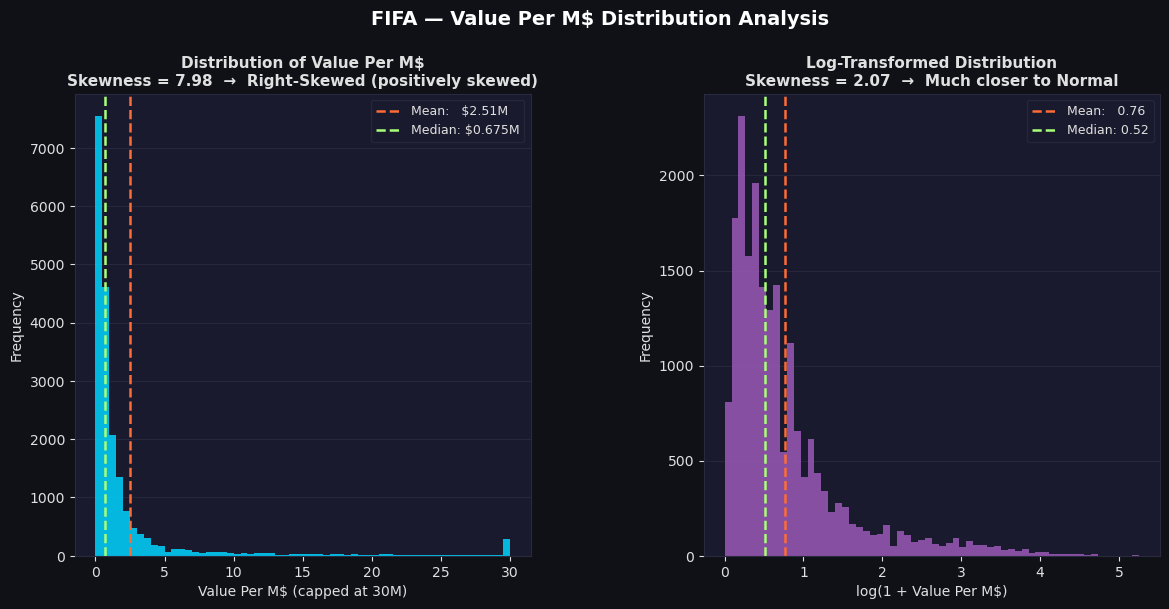


Plot saved as value_distribution.png


In [143]:
# ── Descriptive Statistics ─────────────────────────────────────────────────────
print("── Value Per M$ Descriptive Stats ──")
print(df['Value Per M$'].describe())
 
skewness = df['Value Per M$'].skew()
kurtosis = df['Value Per M$'].kurtosis()
 
print(f"\nSkewness : {skewness:.4f}")
print(f"Kurtosis : {kurtosis:.4f}")
 
if abs(skewness) < 0.5:
    shape = "Approximately Normal (symmetric)"
elif skewness > 0:
    shape = "Right-Skewed (positively skewed)"
else:
    shape = "Left-Skewed (negatively skewed)"
 
print(f"Distribution Shape: {shape}")
 
# ── Visualisation ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6), facecolor='#0f1117')
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
 
text_color = '#e0e0e0'
accent     = '#00d4ff'
accent2    = '#ff6b35'
accent3    = '#a8ff78'
grid_color = '#2a2a3e'
 
# — Plot 1: Raw Distribution ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#1a1a2e')
 
vpm = df['Value Per M$'].clip(upper=30)   # cap for readability
ax1.hist(vpm, bins=60, color=accent, edgecolor='none', alpha=0.85)
 
ax1.axvline(df['Value Per M$'].mean(),
            color=accent2, linestyle='--', linewidth=1.8,
            label=f'Mean:   ${df["Value Per M$"].mean():.2f}M')
ax1.axvline(df['Value Per M$'].median(),
            color=accent3, linestyle='--', linewidth=1.8,
            label=f'Median: ${df["Value Per M$"].median():.3f}M')
 
ax1.set_xlabel('Value Per M$ (capped at 30M)', color=text_color, fontsize=10)
ax1.set_ylabel('Frequency',                    color=text_color, fontsize=10)
ax1.set_title(
    f'Distribution of Value Per M$\nSkewness = {skewness:.2f}  →  {shape}',
    color=text_color, fontsize=11, fontweight='bold'
)
ax1.legend(fontsize=9, facecolor='#1a1a2e', labelcolor=text_color, edgecolor=grid_color)
ax1.tick_params(colors=text_color)
ax1.spines[:].set_color(grid_color)
ax1.yaxis.grid(True, color=grid_color, linewidth=0.6)
ax1.set_axisbelow(True)
 
# — Plot 2: Log-Transformed Distribution ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#1a1a2e')
 
log_vals     = np.log1p(df['Value Per M$'])
log_skewness = log_vals.skew()
 
ax2.hist(log_vals, bins=60, color='#9b59b6', edgecolor='none', alpha=0.85)
ax2.axvline(log_vals.mean(),
            color=accent2, linestyle='--', linewidth=1.8,
            label=f'Mean:   {log_vals.mean():.2f}')
ax2.axvline(log_vals.median(),
            color=accent3, linestyle='--', linewidth=1.8,
            label=f'Median: {log_vals.median():.2f}')
 
ax2.set_xlabel('log(1 + Value Per M$)', color=text_color, fontsize=10)
ax2.set_ylabel('Frequency',             color=text_color, fontsize=10)
ax2.set_title(
    f'Log-Transformed Distribution\nSkewness = {log_skewness:.2f}  →  Much closer to Normal',
    color=text_color, fontsize=11, fontweight='bold'
)
ax2.legend(fontsize=9, facecolor='#1a1a2e', labelcolor=text_color, edgecolor=grid_color)
ax2.tick_params(colors=text_color)
ax2.spines[:].set_color(grid_color)
ax2.yaxis.grid(True, color=grid_color, linewidth=0.6)
ax2.set_axisbelow(True)
 
fig.suptitle('FIFA — Value Per M$ Distribution Analysis',
             color='white', fontsize=14, fontweight='bold', y=1.02)
 
plt.savefig('value_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\nPlot saved as value_distribution.png")

1.4  The correlation of feutures and target :

── Pearson Correlations with Value Per M$ ──
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64

Most correlated feature: Overall_Rating → 0.5606


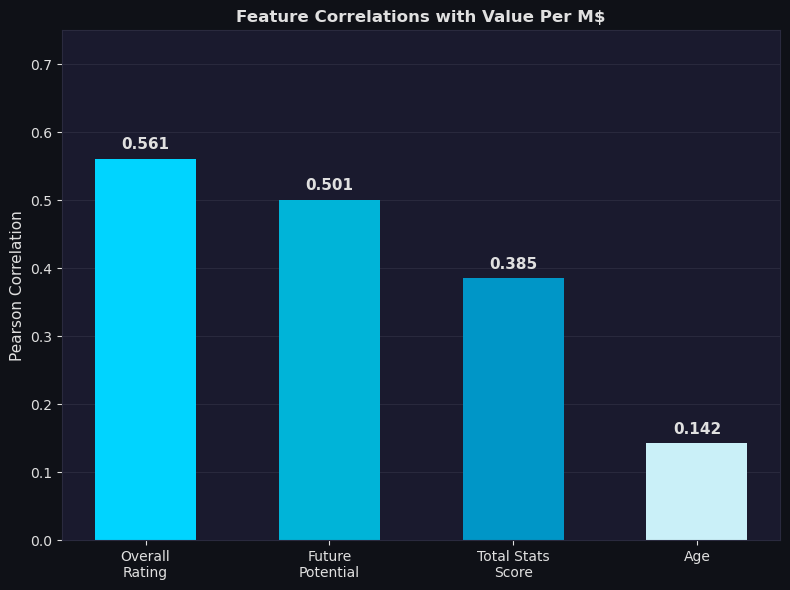

In [144]:
# ── Compute Correlations ───────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = (df[num_cols]
        .corr()['Value Per M$']
        .drop('Value Per M$')
        .sort_values(ascending=False))

print("── Pearson Correlations with Value Per M$ ──")
print(corr.round(6))
print("\nMost correlated feature:", corr.idxmax(), "→", round(corr.max(), 4))
# ── Bar Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0f1117')
ax.set_facecolor('#1a1a2e')

text_color = '#e0e0e0'
grid_color = '#2a2a3e'
labels     = ['Overall\nRating', 'Future\nPotential', 'Total Stats\nScore', 'Age']
bar_colors = ['#00d4ff', '#00b4d8', '#0096c7', '#caf0f8']

bars = ax.bar(labels, corr.values, color=bar_colors, edgecolor='none', width=0.55)

for bar, val in zip(bars, corr.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom',
            color=text_color, fontsize=11, fontweight='bold')

ax.set_ylabel('Pearson Correlation', color=text_color, fontsize=11)
ax.set_title('Feature Correlations with Value Per M$',
             color=text_color, fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.tick_params(colors=text_color)
ax.spines[:].set_color(grid_color)
ax.yaxis.grid(True, color=grid_color, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

1.5 Average Overall Rating per Position:

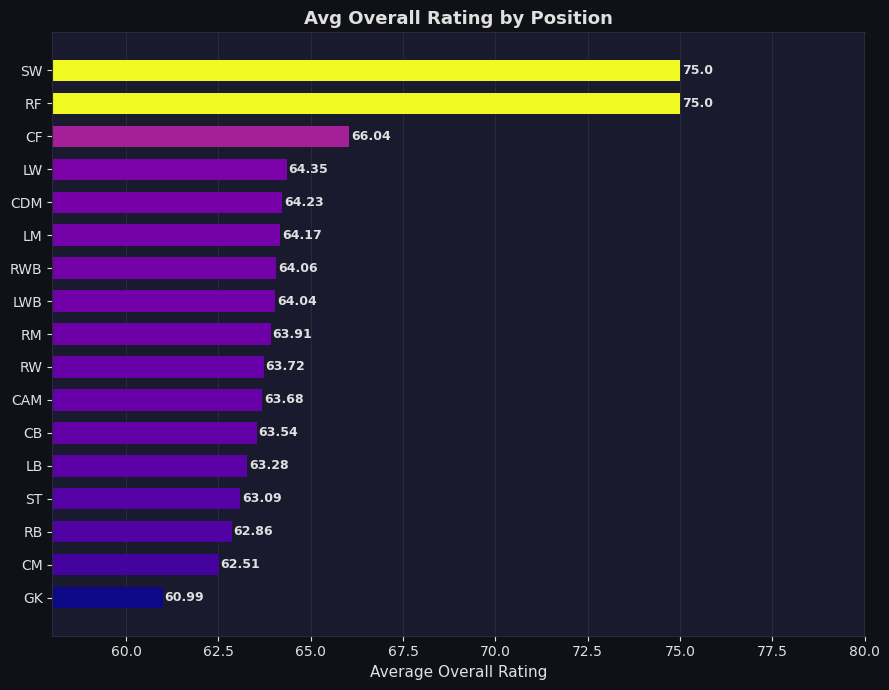

In [145]:
# ── Average Overall Rating per Position ───────────────────────────────────────
pos_rating = (df.groupby('Position')['Overall_Rating']
                .mean()
                .sort_values()
                .round(2))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#0f1117')
ax.set_facecolor('#1a1a2e')

text_color = '#e0e0e0'
grid_color = '#2a2a3e'

cmap      = plt.cm.plasma
norm_vals = (pos_rating.values - pos_rating.values.min()) / (pos_rating.values.max() - pos_rating.values.min())
colors    = [cmap(v) for v in norm_vals]

bars = ax.barh(pos_rating.index, pos_rating.values, color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, pos_rating.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val}', va='center', color=text_color, fontsize=9, fontweight='bold')

ax.set_xlabel('Average Overall Rating', color=text_color, fontsize=11)
ax.set_title('Avg Overall Rating by Position', color=text_color, fontsize=13, fontweight='bold')
ax.set_xlim(58, 80)
ax.tick_params(colors=text_color)
ax.spines[:].set_color(grid_color)
ax.xaxis.grid(True, color=grid_color, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('avg_rating_per_position.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

#### 2.Preprocessing:

2.1 check duplicated rows in the data:

In [146]:
df.duplicated().sum()


np.int64(0)

2.2 split the dataset:

In [147]:
X = df.drop(columns=['Value Per M$'])   
Y = df['Value Per M$']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Log-transform the regression target
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

# ── Save Overall_Rating for classification BEFORE any encoding ──
y_train_clf_raw = x_train['Overall_Rating'].copy()
y_test_clf_raw  = x_test['Overall_Rating'].copy()

 
print('x_train shape:', x_train.shape)
print('x_test shape: ', x_test.shape)

x_train shape: (15733, 7)
x_test shape:  (3934, 7)


2.3 check the null values :

In [148]:
print('the null values in x train is:', x_train.isnull().sum().sum())
print ('the null values in y train is:', y_train.isnull().sum().sum())  
print('the null values in x test is:', x_test.isnull().sum().sum())
print ('the null values in y test is:', y_test.isnull().sum().sum())

the null values in x train is: 0
the null values in y train is: 0
the null values in x test is: 0
the null values in y test is: 0


2.4 check the outliers and solve it :

In [149]:
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

# ── Print Before ───────────────────────────────────────────────────────────────
print("── BEFORE ──")
print(f"{'Feature':25s} | {'X_Train':>8} | {'X_Test':>8}")
print("-" * 50)

# x_train and x_test outliers are calculated from train bounds only (no leakage)
bounds = {}
for col in num_cols:
    Q1     = x_train[col].quantile(0.25)
    Q3     = x_train[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    median = x_train[col].median()
    bounds[col] = (lower, upper, median)

    out_train = ((x_train[col] < lower) | (x_train[col] > upper)).sum()
    out_test  = ((x_test[col]  < lower) | (x_test[col]  > upper)).sum()
    print(f"{col:25s} | {out_train:>8} | {out_test:>8}")

# y outliers are only reported, NOT removed
# log1p already handles the right skew — removing elite players loses real signal
Q1      = y_train.quantile(0.25)
Q3      = y_train.quantile(0.75)
IQR     = Q3 - Q1
y_lower = Q1 - 1.5 * IQR
y_upper = Q3 + 1.5 * IQR

print(f"{'Value Per M$ (log)':25s} | {((y_train < y_lower) | (y_train > y_upper)).sum():>8} | {((y_test < y_lower) | (y_test > y_upper)).sum():>8}")
print("  → y outliers detected but kept (log-transform already reduces skew)")

# ── Fill X outliers with train median ─────────────────────────────────────────
for col in num_cols:
    lower, upper, median = bounds[col]
    x_train[col] = np.where((x_train[col] < lower) | (x_train[col] > upper), median, x_train[col])
    x_test[col]  = np.where((x_test[col]  < lower) | (x_test[col]  > upper), median, x_test[col])

# y_train and y_test are left unchanged

print("\n── AFTER ──")
print(f"{'Feature':25s} | {'X_Train':>8} | {'X_Test':>8}")
print("-" * 50)

for col in num_cols:
    lower, upper, _ = bounds[col]
    out_train = ((x_train[col] < lower) | (x_train[col] > upper)).sum()
    out_test  = ((x_test[col]  < lower) | (x_test[col]  > upper)).sum()
    print(f"{col:25s} | {out_train:>8} | {out_test:>8}")

print(f"{'Value Per M$ (log)':25s} | {'kept':>8} | {'kept':>8}")
print("  → X outliers replaced with train median | y outliers untouched")

── BEFORE ──
Feature                   |  X_Train |   X_Test
--------------------------------------------------
Age                       |      129 |       40
Overall_Rating            |      111 |       35
Future Potential          |       94 |       26
Total_Stats Score         |      666 |      158
Value Per M$ (log)        |     1219 |      319
  → y outliers detected but kept (log-transform already reduces skew)

── AFTER ──
Feature                   |  X_Train |   X_Test
--------------------------------------------------
Age                       |        0 |        0
Overall_Rating            |        0 |        0
Future Potential          |        0 |        0
Total_Stats Score         |        0 |        0
Value Per M$ (log)        |     kept |     kept
  → X outliers replaced with train median | y outliers untouched


2.5 encoding :

In [ ]:
X_train_raw_nums = x_train[["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]].copy()
X_test_raw_nums  = x_test[["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]].copy()
_orig_cats_train = df[["Country", "Position", "Team"]].loc[x_train.index].copy()
_orig_cats_test  = df[["Country", "Position", "Team"]].loc[x_test.index].copy()
categorical_cols = ['Position', 'Country', 'Team']

# Drop Overall_Rating before encoding to prevent data leakage
x_train_no_or = x_train.drop(columns=['Overall_Rating'])
x_test_no_or  = x_test.drop(columns=['Overall_Rating'])



_bins_tmp = pd.qcut(y_train_clf_raw, q=4, labels=[0, 1, 2, 3]).astype(float)

# Start from numeric columns only, then fill in encoded categoricals
x_train_cls = x_train_no_or.drop(columns=categorical_cols).copy().astype(float)
x_test_cls  = x_test_no_or.drop(columns=categorical_cols).copy().astype(float)

_cls_global_mean = _bins_tmp.mean()
_cls_enc_maps    = {}
for col in categorical_cols:
    _col_means = x_train_no_or[[col]].copy()
    _col_means['__y__'] = _bins_tmp.values
    _col_means = _col_means.groupby(col)['__y__'].mean()
    _cls_enc_maps[col]  = _col_means          # saved for ScoutingSystem
    x_train_cls[col] = x_train_no_or[col].map(_col_means).fillna(_cls_global_mean)
    x_test_cls[col]  = x_test_no_or[col].map(_col_means).fillna(_cls_global_mean)
    print(f"{col:15s} → classification target encoding applied")

print(f"\nClassification feature matrix — Train: {x_train_cls.shape}, Test: {x_test_cls.shape}")

# OHE branch — kept for BernoulliNB / ComplementNB only 
x_train_bern_ohe = pd.get_dummies(x_train_no_or, columns=categorical_cols, drop_first=True)
x_test_bern_ohe  = pd.get_dummies(x_test_no_or,  columns=categorical_cols, drop_first=True)
x_test_bern_ohe  = x_test_bern_ohe.reindex(columns=x_train_bern_ohe.columns, fill_value=0)
print(f"OHE branch (BernoulliNB/ComplementNB) — Train: {x_train_bern_ohe.shape}")

#  Regression target encoding
target_encoding_maps = {}
for col in categorical_cols:
    means = x_train_no_or.join(y_train.rename('target')).groupby(col)['target'].mean()
    target_encoding_maps[col] = means
    x_train[col] = x_train[col].map(means).fillna(float(y_train.mean()))
    x_test[col]  = x_test[col].map(means).fillna(float(y_train.mean()))
global_mean = float(y_train.mean())



Position        → classification target encoding applied
Country         → classification target encoding applied
Team            → classification target encoding applied

Classification feature matrix — Train: (15733, 6), Test: (3934, 6)
OHE branch (BernoulliNB/ComplementNB) — Train: (15733, 1176)


2.6 feaure scaling :

In [151]:

# Feature Scaling 
scaler = StandardScaler()

# fit on train only — transform both
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# Convert back to DataFrame first, then select numeric columns
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled_df  = pd.DataFrame(x_test_scaled,  columns=x_test.columns)

numeric_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
x_train_scaled_numeric = x_train_scaled_df[numeric_cols]
x_test_scaled_numeric  = x_test_scaled_df[numeric_cols]

#  Before Scaling 
print("── Before Scaling ──")
print(pd.DataFrame(x_train).head().to_string())

# After Scaling 
print("\n── After Scaling ──")
print(x_train_scaled_df.head().round(4).to_string())

── Before Scaling ──
        Country  Position   Age  Overall_Rating  Future Potential      Team  Total_Stats Score
10156  0.575174  0.871764  25.0            67.0              70.0  1.079405             1689.0
10392  0.849863  0.766225  19.0            55.0              68.0  0.782081             1351.0
8124   1.320404  0.862196  32.0            75.0              75.0  0.939580             2049.0
13075  1.320404  0.766225  17.0            61.0              71.0  0.829280             1448.0
19445  0.801177  0.715233  28.0            69.0              69.0  0.644392             1748.0

── After Scaling ──
   Country  Position     Age  Overall_Rating  Future Potential    Team  Total_Stats Score
0  -0.6730    1.1144  0.4782          0.5193           -0.1053  0.6071             0.5233
1   0.3169    0.0435 -0.8631         -1.0710           -0.4226  0.0385            -0.8607
2   2.0125    1.0174  2.0430          1.5794            0.6879  0.3397             1.9974
3   2.0125    0.0435 -1.3102

### 3. Create Classification Target


Players are classified into 4 performance tiers based on Overall_Rating.
Thresholds are determined using quantile-based binning (pd.qcut) on the 
training set only, ensuring no data leakage from the test set. The same 
boundaries are then applied to the test set using pd.cut.

Equal-width quantile bins were chosen to ensure balanced class representation,
preventing model bias toward the majority class. Each tier captures 
approximately 25% of training players.

| Tier  | Overall Rating Range |
|-------|----------------------|
| Low   | below 58.0           |
| Mid   | 58.0 to 63.0         |
| High  | 63.0 to 68.0         |
| Elite | above 68.0           |

**Class Distribution after Splitting:**

| Tier  | Train | Test |
|-------|-------|------|
| Low   | 4403  | 1164 |
| Mid   | 4117  | 985  |
| High  | 3460  | 837  |
| Elite | 3753  | 947  |

The distribution is **approximately balanced** across all four tiers, with 
slight variation due to repeated Overall_Rating values at the quartile 
boundaries. This balance is intentional — it ensures that classification 
models do not develop a bias toward predicting the majority class, which 
would artificially inflate accuracy without genuine learning.

Low   threshold: below 58.0
Mid   threshold: 58.0 to 63.0
High  threshold: 63.0 to 68.0
Elite threshold: above 68.0

Train class distribution:
Overall_Rating
Low      4403
Mid      4117
High     3460
Elite    3753
Name: count, dtype: int64

Test class distribution:
Overall_Rating
Low      1165
Mid       985
High      837
Elite     947
Name: count, dtype: int64

NaNs in y_test_clf: 0


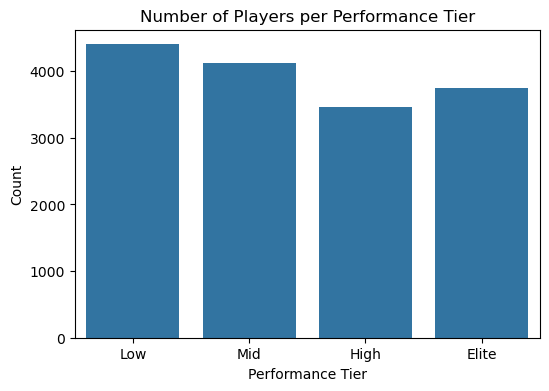

In [152]:
y_train_clf, bins = pd.qcut(y_train_clf_raw, q=4, labels=['Low', 'Mid', 'High', 'Elite'], retbins=True)

bins[0]  = -np.inf
bins[-1] =  np.inf

y_test_clf = pd.cut(y_test_clf_raw, bins=bins, labels=['Low', 'Mid', 'High', 'Elite'], include_lowest=True)

print(f"Low   threshold: below {bins[1]:.1f}")
print(f"Mid   threshold: {bins[1]:.1f} to {bins[2]:.1f}")
print(f"High  threshold: {bins[2]:.1f} to {bins[3]:.1f}")
print(f"Elite threshold: above {bins[3]:.1f}")

print("\nTrain class distribution:")
print(y_train_clf.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test_clf.value_counts().sort_index())
print(f"\nNaNs in y_test_clf: {y_test_clf.isna().sum()}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_clf, order=['Low', 'Mid', 'High', 'Elite'])
plt.title('Number of Players per Performance Tier')
plt.xlabel('Performance Tier')
plt.ylabel('Count')
plt.show()

In [153]:
# Use OHE features, drop Overall_Rating, then scale
x_train_clf = x_train_cls.drop(columns=['Overall_Rating'], errors='ignore')
x_test_clf  = x_test_cls.drop(columns=['Overall_Rating'],  errors='ignore')

scaler_clf = StandardScaler()
x_train_clf_scaled = scaler_clf.fit_transform(x_train_clf)
x_test_clf_scaled  = scaler_clf.transform(x_test_clf)

# Convert back to DataFrame for easy column access
x_train_clf = pd.DataFrame(x_train_clf_scaled, columns=x_train_clf.columns)
x_test_clf  = pd.DataFrame(x_test_clf_scaled,  columns=x_test_clf.columns)

print("x_train_clf shape:", x_train_clf.shape)
print("x_test_clf shape: ", x_test_clf.shape)

x_train_clf shape: (15733, 6)
x_test_clf shape:  (3934, 6)


## 4. Polynomial Regression

We train regression models to predict the player's market value (Value Per M$) using polynomial feature expansion combined with regularization.

### Step 1 : Define Evaluation Metrics

We define four custom metrics to evaluate regression performance: MAE, MSE, RMSE, and R².

In [154]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

### Step 2 : Baseline Linear Regression

Before applying polynomial expansion, we train a plain Linear Regression model as our reference point to see how well a simple linear fit performs.

In [155]:
# Baseline Linear Regression — numeric polynomial features + encoded categoricals
x_train_cat = x_train_scaled_df[['Position', 'Country', 'Team']].values
x_test_cat  = x_test_scaled_df[['Position', 'Country', 'Team']].values

x_train_baseline = np.hstack([x_train_scaled_numeric, x_train_cat])
x_test_baseline  = np.hstack([x_test_scaled_numeric,  x_test_cat])

linear_model = LinearRegression()
linear_model.fit(x_train_baseline, y_train)

y_pred_train = linear_model.predict(x_train_baseline)
y_pred_test  = linear_model.predict(x_test_baseline)

print("- Baseline Linear Regression :")
print("Train Set:")
print(f"  MAE  : {mae(y_train, y_pred_train):.4f}")
print(f"  MSE  : {mse(y_train, y_pred_train):.4f}")
print(f"  RMSE : {rmse(y_train, y_pred_train):.4f}")
print(f"  R²   : {r2(y_train, y_pred_train):.4f}")
print("\nTest Set:")
print(f"  MAE  : {mae(y_test, y_pred_test):.4f}")
print(f"  MSE  : {mse(y_test, y_pred_test):.4f}")
print(f"  RMSE : {rmse(y_test, y_pred_test):.4f}")
print(f"  R²   : {r2(y_test, y_pred_test):.4f}")

- Baseline Linear Regression :
Train Set:
  MAE  : 0.2332
  MSE  : 0.1414
  RMSE : 0.3761
  R²   : 0.7484

Test Set:
  MAE  : 0.2354
  MSE  : 0.1481
  RMSE : 0.3849
  R²   : 0.7475


**Baseline Linear Regression Results**

The baseline model using degree 1 (plain linear) achieved a Test R² of 0.7475, meaning it explains about 74.75% of the variance in player market value. The train/test gap is only 0.0009, so the model generalizes well , it's just not capturing the full non-linear relationship between the features and value.

### Step 3 : Polynomial Feature Expansion (Degrees 1–4)

We expand the numeric features using polynomial degrees 1 through 4 and train a Linear Regression model for each degree to find how complexity affects performance.

In [156]:
r2_test_total  = []
r2_train_total = []

for d in range(1, 5):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    poly.fit(x_train_scaled_numeric)
    x_train_poly = poly.transform(x_train_scaled_numeric)
    x_test_poly  = poly.transform(x_test_scaled_numeric)

    # Concatenate polynomial numeric features with encoded categorical features
    x_train_combined = np.hstack([x_train_poly, x_train_cat])
    x_test_combined  = np.hstack([x_test_poly,  x_test_cat])

    model = LinearRegression()
    model.fit(x_train_combined, y_train)

    y_predict_poly_train = model.predict(x_train_combined)
    y_predict_poly_test  = model.predict(x_test_combined)

    r2_train_total.append(r2(y_train, y_predict_poly_train))
    r2_test_total.append(r2(y_test,  y_predict_poly_test))

    print(f"\n - Degree {d} :")
    print("  Train Set:")
    print(f"    MAE  : {mae(y_train, y_predict_poly_train):.4f}")
    print(f"    MSE  : {mse(y_train, y_predict_poly_train):.4f}")
    print(f"    RMSE : {rmse(y_train, y_predict_poly_train):.4f}")
    print(f"    R²   : {r2(y_train, y_predict_poly_train):.4f}")
    print("  Test Set:")
    print(f"    MAE  : {mae(y_test, y_predict_poly_test):.4f}")
    print(f"    MSE  : {mse(y_test, y_predict_poly_test):.4f}")
    print(f"    RMSE : {rmse(y_test, y_predict_poly_test):.4f}")
    print(f"    R²   : {r2(y_test, y_predict_poly_test):.4f}")
    print(f"    Gap  : {r2(y_train, y_predict_poly_train) - r2(y_test, y_predict_poly_test):.4f}")



 - Degree 1 :
  Train Set:
    MAE  : 0.2332
    MSE  : 0.1414
    RMSE : 0.3761
    R²   : 0.7484
  Test Set:
    MAE  : 0.2354
    MSE  : 0.1481
    RMSE : 0.3849
    R²   : 0.7475
    Gap  : 0.0009

 - Degree 2 :
  Train Set:
    MAE  : 0.1418
    MSE  : 0.0758
    RMSE : 0.2754
    R²   : 0.8651
  Test Set:
    MAE  : 0.1453
    MSE  : 0.0799
    RMSE : 0.2826
    R²   : 0.8639
    Gap  : 0.0012

 - Degree 3 :
  Train Set:
    MAE  : 0.1173
    MSE  : 0.0606
    RMSE : 0.2461
    R²   : 0.8923
  Test Set:
    MAE  : 0.1218
    MSE  : 0.0638
    RMSE : 0.2525
    R²   : 0.8913
    Gap  : 0.0009

 - Degree 4 :
  Train Set:
    MAE  : 0.1013
    MSE  : 0.0443
    RMSE : 0.2105
    R²   : 0.9212
  Test Set:
    MAE  : 0.1065
    MSE  : 0.0518
    RMSE : 0.2276
    R²   : 0.9117
    Gap  : 0.0095


**What trend do we observe across degrees?**

As the polynomial degree increases, both Train R² and Test R² go up consistently, which means higher degrees are capturing more complex patterns in the data. However, the gap between train and test also grows with degree, which is a sign that the model starts to overfit slightly as complexity increases.

| Degree | Train R² | Test R² | Gap |
|--------|----------|---------|-----|
| 1 | 0.7484 | 0.7475 | 0.0009 |
| 2 | 0.8651 | 0.8639 | 0.0012 |
| 3 | 0.8923 | 0.8913 | 0.0009 |
| 4 | 0.9212 | 0.9117 | 0.0095 |

**Which degree gives the best generalization?**

Degree 4 gives the highest Test R² of 0.9117, so it explains the most variance on unseen data. The gap of 0.0095 is the largest but still relatively small, meaning the model hasn't significantly overfit. We pick degree 4 as the best degree and apply regularization on it to keep the overfitting under control.

### Step 4 : Degree vs Performance Plot

Visualizing Train R² and Test R² across all degrees to clearly see where the model starts to overfit.

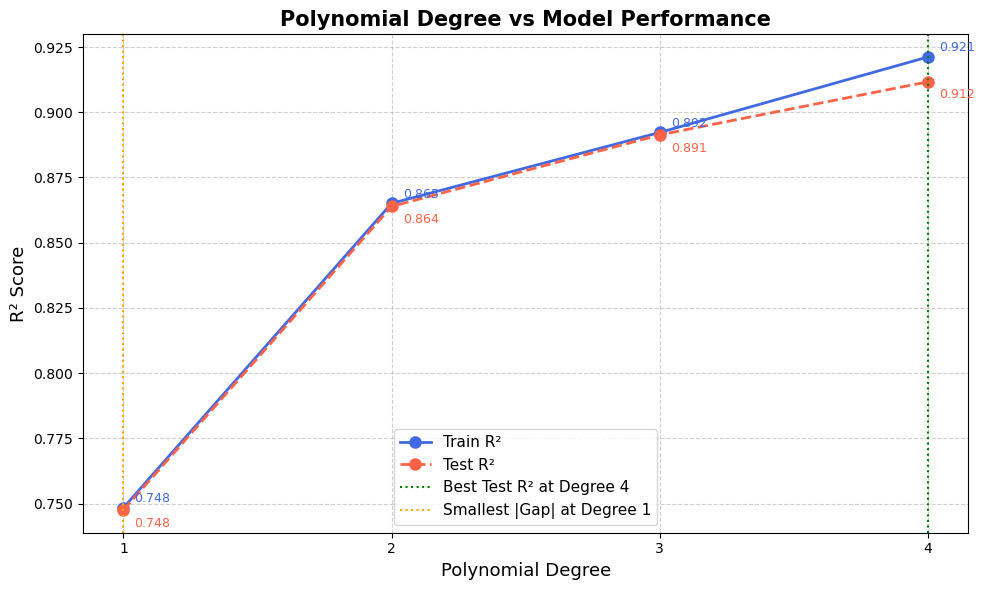


  Degree |   Train R² |    Test R² |      Gap

       1 |     0.7484 |     0.7475 |   0.0009
       2 |     0.8651 |     0.8639 |   0.0012
       3 |     0.8923 |     0.8913 |   0.0009
       4 |     0.9212 |     0.9117 |   0.0095


In [157]:
def plot_degree_vs_r2(degrees, r2_train, r2_test):
    plt.figure(figsize=(10, 6))

    plt.plot(degrees, r2_train, marker='o', linewidth=2, markersize=8, label='Train R²', color='royalblue')
    plt.plot(degrees, r2_test, marker='o', linewidth=2,  markersize=8, label='Test R²', color='tomato', linestyle='--')

    for d, tr, te in zip(degrees, r2_train, r2_test):
        plt.annotate(f'{tr:.3f}', (d, tr), textcoords="offset points", xytext=(8, 4), ha='left', color='royalblue', fontsize=9)
        plt.annotate(f'{te:.3f}', (d, te), textcoords="offset points", xytext=(8, -12), ha='left', color='tomato', fontsize=9)

    # Use abs(gap) so negative gaps (test > train) don't mislead the min search
    gaps     = [r2_train[i] - r2_test[i] for i in range(len(degrees))]
    abs_gaps = [abs(g) for g in gaps]

    best_test_idx  = r2_test.index(max(r2_test))
    min_gap_idx    = abs_gaps.index(min(abs_gaps))
    best_degree    = degrees[best_test_idx]
    min_gap_degree = degrees[min_gap_idx]

    plt.axvline(x=best_degree, color='green', linestyle=':', linewidth=1.5, label=f'Best Test R² at Degree {best_degree}')
    if min_gap_degree != best_degree:
        plt.axvline(x=min_gap_degree, color='orange', linestyle=':', linewidth=1.5,    label=f'Smallest |Gap| at Degree {min_gap_degree}')

    plt.xlabel("Polynomial Degree", fontsize=13)
    plt.ylabel("R² Score", fontsize=13)
    plt.title("Polynomial Degree vs Model Performance", fontsize=15, fontweight='bold')
    plt.xticks(degrees)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Degree':>8} | {'Train R²':>10} | {'Test R²':>10} | {'Gap':>8}")
    print()
    for d, tr, te in zip(degrees, r2_train, r2_test):
        print(f"{d:>8} | {tr:>10.4f} | {te:>10.4f} | {tr-te:>8.4f}")

plot_degree_vs_r2([1, 2, 3, 4], r2_train_total, r2_test_total)

### Step 5 : Regularization : Ridge (L2) and Lasso (L1)

Since degree 4 gives the best test R² but also the largest train/test gap, we apply regularization to control overfitting. We sweep alpha over a log-spaced range from 0.001 to 1000 for both Ridge and Lasso.

In [158]:
# Build polynomial features using the best degree selected above
x_train_cat = x_train_scaled_df[['Position', 'Country', 'Team']].values
x_test_cat  = x_test_scaled_df[['Position', 'Country', 'Team']].values

best_poly_degree = [1, 2, 3, 4][r2_test_total.index(max(r2_test_total))]
best_gap         = r2_train_total[r2_test_total.index(max(r2_test_total))] - max(r2_test_total)
print(f"Using degree {best_poly_degree} for regularization "f"(highest Test R² = {max(r2_test_total):.4f}, gap = {best_gap:.4f})")

poly_best = PolynomialFeatures(degree=best_poly_degree, include_bias=False)
poly_best.fit(x_train_scaled_numeric)
x_train_poly_best = poly_best.transform(x_train_scaled_numeric)
x_test_poly_best  = poly_best.transform(x_test_scaled_numeric)

x_train_final = np.hstack([x_train_poly_best, x_train_cat])
x_test_final  = np.hstack([x_test_poly_best,  x_test_cat])

alpha_range = np.logspace(-3, 3, 50)

# Ridge 
def fit_ridge(a, X_train, y_train):
    return Ridge(alpha=a).fit(X_train, y_train)

ridge_models = Parallel(n_jobs=-1)(
    delayed(fit_ridge)(a, x_train_final, y_train) for a in alpha_range
)
rmse_ridge_train = [rmse(y_train, m.predict(x_train_final)) for m in ridge_models]
rmse_ridge_test  = [rmse(y_test,  m.predict(x_test_final))  for m in ridge_models]

# Lasso 
def fit_lasso(a, X_train, y_train):
    return Lasso(alpha=a, max_iter=50000, tol=1e-4).fit(X_train, y_train)

lasso_models = Parallel(n_jobs=-1)(
    delayed(fit_lasso)(a, x_train_final, y_train) for a in alpha_range
)
rmse_lasso_train = [rmse(y_train, m.predict(x_train_final)) for m in lasso_models]
rmse_lasso_test  = [rmse(y_test,  m.predict(x_test_final))  for m in lasso_models]

# Results 
best_idx_ridge   = int(np.argmin(rmse_ridge_test))
best_idx_lasso   = int(np.argmin(rmse_lasso_test))
best_alpha_ridge = alpha_range[best_idx_ridge]
best_alpha_lasso = alpha_range[best_idx_lasso]

print(f"\n - Ridge :")
print(f"  Best Alpha : {best_alpha_ridge:.6f}")
print(f"  Train RMSE : {rmse_ridge_train[best_idx_ridge]:.4f}")
print(f"  Test  RMSE : {rmse_ridge_test[best_idx_ridge]:.4f}")

print(f"\n ─ Lasso :")
print(f"  Best Alpha : {best_alpha_lasso:.6f}")
print(f"  Train RMSE : {rmse_lasso_train[best_idx_lasso]:.4f}")
print(f"  Test  RMSE : {rmse_lasso_test[best_idx_lasso]:.4f}")

Using degree 4 for regularization (highest Test R² = 0.9117, gap = 0.0095)

 - Ridge :
  Best Alpha : 104.811313
  Train RMSE : 0.2132
  Test  RMSE : 0.2240

 ─ Lasso :
  Best Alpha : 0.001000
  Train RMSE : 0.2146
  Test  RMSE : 0.2243


**Ridge vs Lasso Which performs better and why?**

Ridge performs better on this dataset. Ridge achieved a Test RMSE of 0.2240 with best alpha ≈ 104.81, while Lasso achieved 0.2243 with best alpha ≈ 0.001. Although the difference is small, Ridge is the stronger choice here for a clear reason: with 72 features that include many polynomial interaction terms, most features carry at least some signal. Ridge shrinks all coefficients smoothly without eliminating any, which suits this kind of dense feature set well. Lasso on the other hand pushes coefficients to exactly zero and works best when only a few features truly matter, which is not the case here. The fact that Lasso's best alpha was only 0.001 (essentially almost no penalty) also confirms that aggressive feature elimination was not helpful on this data, and Ridge's stronger regularization at alpha ≈ 104.81 was what actually controlled the overfitting.

**Did Lasso zero out any features?**

Yes, Lasso zeroed out 14 out of 72 features, meaning it found them redundant or too weak to keep. The 58 retained features are what the model considers genuinely useful for predicting market value. This is Lasso acting as an automatic feature selector, useful when you want a simpler and more interpretable model, but in this case Ridge still generalized better despite keeping all features.

### Step 6 : Alpha vs RMSE Plot & Lasso Feature Selection

We plot the RMSE curves for both Ridge and Lasso across all alpha values to identify the best regularization strength, and inspect which features Lasso zeroed out.

Total features      : 72
Zeroed out by Lasso : 14
Retained by Lasso   : 58

Retained features and their coefficients:
  Age                                           : 0.133170
  Overall_Rating                                : 0.236832
  Future Potential                              : 0.253651
  Age^2                                         : 0.003661
  Age Overall_Rating                            : -0.037714
  Age Future Potential                          : 0.059882
  Age Total_Stats Score                         : -0.008673
  Overall_Rating Future Potential               : 0.166409
  Overall_Rating Total_Stats Score              : -0.049158
  Future Potential^2                            : 0.006759
  Future Potential Total_Stats Score            : 0.024131
  Total_Stats Score^2                           : 0.042580
  Age^3                                         : -0.031124
  Age^2 Future Potential                        : -0.034678
  Age Overall_Rating Future Potential           : -

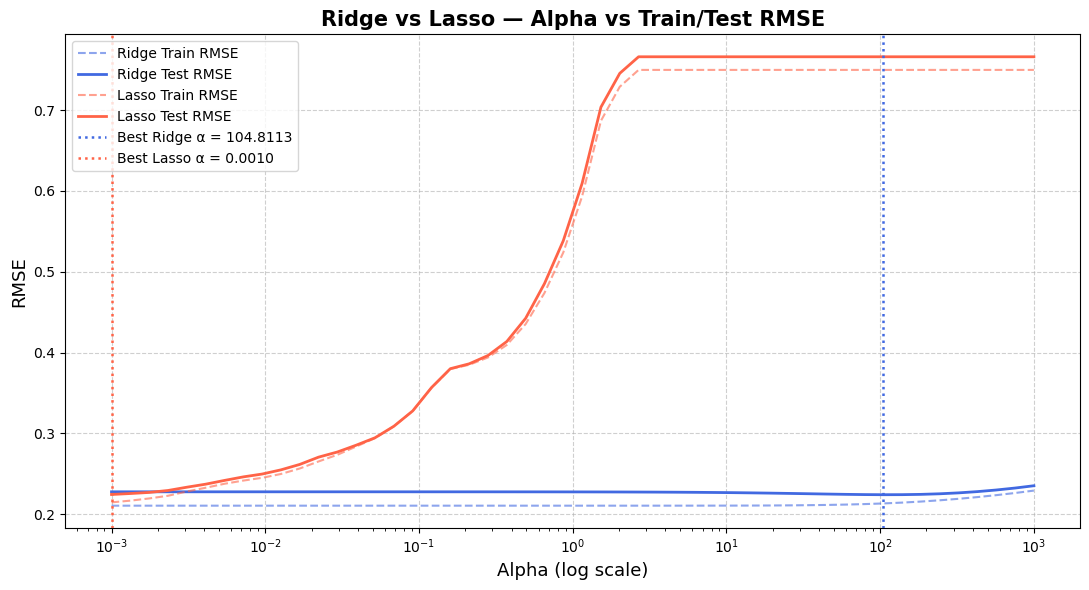

In [159]:
def plot_alpha_vs_rmse(alpha_range,rmse_ridge_train, rmse_ridge_test, rmse_lasso_train, rmse_lasso_test, best_alpha_ridge, best_alpha_lasso):
    plt.figure(figsize=(11, 6))

    plt.plot(alpha_range, rmse_ridge_train, linewidth=1.5, linestyle='--',color='royalblue', alpha=0.6, label='Ridge Train RMSE')
    plt.plot(alpha_range, rmse_ridge_test, linewidth=2,color='royalblue', label='Ridge Test RMSE')
    plt.plot(alpha_range, rmse_lasso_train, linewidth=1.5, linestyle='--', color='tomato', alpha=0.6, label='Lasso Train RMSE')
    plt.plot(alpha_range, rmse_lasso_test, linewidth=2, color='tomato', label='Lasso Test RMSE')

    plt.axvline(x=best_alpha_ridge, color='royalblue', linestyle=':', linewidth=1.8, label=f'Best Ridge α = {best_alpha_ridge:.4f}')
    plt.axvline(x=best_alpha_lasso, color='tomato', linestyle=':', linewidth=1.8, label=f'Best Lasso α = {best_alpha_lasso:.4f}')

    plt.xscale('log')
    plt.xlabel('Alpha (log scale)', fontsize=13)
    plt.ylabel('RMSE', fontsize=13)
    plt.title('Ridge vs Lasso — Alpha vs Train/Test RMSE', fontsize=15, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

best_lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=50000, tol=1e-4).fit(x_train_final, y_train)

poly_feature_names = poly_best.get_feature_names_out()
cat_feature_names  = ['Position', 'Country', 'Team']
all_feature_names  = list(poly_feature_names) + cat_feature_names

# Use abs threshold instead of == 0 since floating-point coefficients
# rarely land at exactly zero even when Lasso intends to zero them out
zeroed  = [all_feature_names[i] for i, c in enumerate(best_lasso_model.coef_) if abs(c) < 1e-6]
nonzero = [all_feature_names[i] for i, c in enumerate(best_lasso_model.coef_) if abs(c) >= 1e-6]

print(f"Total features      : {len(all_feature_names)}")
print(f"Zeroed out by Lasso : {len(zeroed)}")
print(f"Retained by Lasso   : {len(nonzero)}")

print(f"\nRetained features and their coefficients:")
for name, coef in zip(all_feature_names, best_lasso_model.coef_):
    if abs(coef) >= 1e-6:
        print(f"  {name:<45} : {coef:.6f}")

print(f"\nZeroed out features ({len(zeroed)}):")
for name in zeroed:
    print(f"  {name}")

plot_alpha_vs_rmse(alpha_range, rmse_ridge_train, rmse_ridge_test,  rmse_lasso_train, rmse_lasso_test,  best_alpha_ridge, best_alpha_lasso)

## Task 5: Model 2 — Logistic Regression

We train a Logistic Regression classifier to predict the player performance tier (Low / Mid / High / Elite). `Overall_Rating` is excluded from all features since it was used to create the classification target.

 Create Feature Matrices for Classification
 Overall_Rating must be removed as required

Baseline Logistic Regression Model

In [160]:
log_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_model.fit(x_train_clf, y_train_clf)

y_pred_log_train = log_model.predict(x_train_clf)
y_pred_log_test  = log_model.predict(x_test_clf)

Accuracy + Precision + Recall + F1

In [161]:
# NEW
train_acc = accuracy_score(y_train_clf, y_pred_log_train)
test_acc  = accuracy_score(y_test_clf,  y_pred_log_test)
print("Baseline Logistic Regression")
print()

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_clf, y_pred_log_test))

Baseline Logistic Regression

Train Accuracy : 0.7718
Test Accuracy  : 0.7768

Classification Report:

              precision    recall  f1-score   support

       Elite       0.89      0.85      0.87       947
        High       0.65      0.66      0.65       837
         Low       0.88      0.87      0.88      1165
         Mid       0.67      0.70      0.68       985

    accuracy                           0.78      3934
   macro avg       0.77      0.77      0.77      3934
weighted avg       0.78      0.78      0.78      3934



Confusion Matrix Heatmap

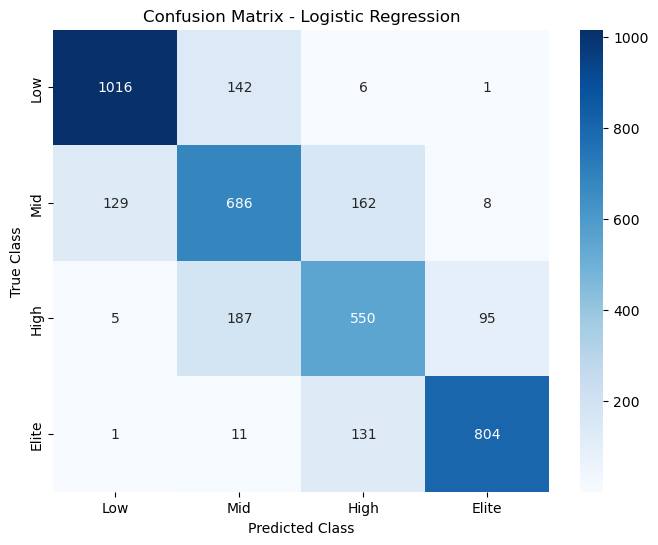

In [162]:
cm = confusion_matrix(y_test_clf, y_pred_log_test, labels=['Low', 'Mid', 'High', 'Elite'])

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Mid', 'High', 'Elite'],
    yticklabels=['Low', 'Mid', 'High', 'Elite']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### Confusion Matrix Analysis

The confusion matrix reveals how the model performs across all four performance tiers:

- **Low** is predicted with the highest reliability. Most Low-tier players are correctly identified because their feature values (low Future Potential and Total_Stats Score) are distinctly different from the other classes.
- **Elite** is also well-separated for similar reasons — top players have distinctively high composite stats that distinguish them clearly.
- **Mid and High** show the most confusion between each other. This is expected because players at the boundary between these tiers share very similar stat profiles. A Mid player with slightly elevated stats may look identical to a High player to the model.
- Overall, the off-diagonal errors are concentrated in adjacent classes (e.g. Mid predicted as High, or High predicted as Mid), which is a healthy pattern — the model is not making large errors like confusing Low with Elite.

Sweep C Values (L2 Regularization)

In [163]:
C_values = np.logspace(-3, 3, 20)

train_accuracy = []
test_accuracy = []

for c in C_values:
    model = LogisticRegression(
        C=c,
        penalty='l2',
        solver='lbfgs',
        max_iter=5000,
        random_state=42
    )

    model.fit(x_train_clf, y_train_clf)

    pred_train = model.predict(x_train_clf)
    pred_test = model.predict(x_test_clf)

    train_accuracy.append(
        accuracy_score(y_train_clf, pred_train)
    )

    test_accuracy.append(
        accuracy_score(y_test_clf, pred_test)
    )

Best C Value

In [164]:
best_C = C_values[np.argmax(test_accuracy)]

print("Best C Value:", best_C)
print("Best Test Accuracy:", max(test_accuracy))

Best C Value: 26.366508987303554
Best Test Accuracy: 0.7780884595831215


Plot Train/Test Accuracy vs C

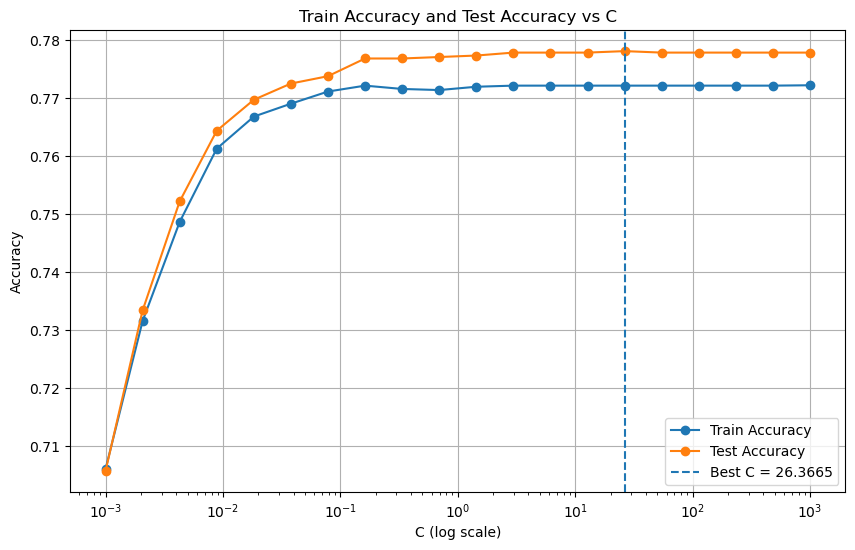

In [165]:
plt.figure(figsize=(10,6))

plt.plot(
    C_values,
    train_accuracy,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    C_values,
    test_accuracy,
    marker='o',
    label='Test Accuracy'
)

plt.xscale('log')

plt.axvline(
    best_C,
    linestyle='--',
    label=f'Best C = {best_C:.4f}'
)

plt.title("Train Accuracy and Test Accuracy vs C")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### C Sweep Results — Train & Test Accuracy vs C

- At very low C values (strong regularization), the model is too constrained and underfits — both train and test accuracy are low.
- As C increases, the model gains more freedom and accuracy improves on both sets.
- Beyond the optimal C, the model starts to overfit: train accuracy keeps rising while test accuracy plateaus or slightly drops.
- The best C (marked on the plot) is where test accuracy peaks, striking the right balance between bias and variance.

Compare L1 vs L2 at Best C

In [166]:
# L1 Regularization
model_l1 = LogisticRegression(
    C=best_C,
    penalty='l1',
    solver='saga',
    max_iter=3000,
    tol=1e-2,
    warm_start=True,
    random_state=42,
    n_jobs=-1
)
model_l1.fit(x_train_clf, y_train_clf)
pred_l1 = model_l1.predict(x_test_clf)
acc_l1 = accuracy_score(y_test_clf, pred_l1)

# L2 Regularization
model_l2 = LogisticRegression(
    C=best_C,
    penalty='l2',
    solver='lbfgs',
    max_iter=3000,
    tol=1e-2,
    random_state=42
)
model_l2.fit(x_train_clf, y_train_clf)
pred_l2 = model_l2.predict(x_test_clf)
acc_l2 = accuracy_score(y_test_clf, pred_l2)

print(" - L1 vs L2 Comparison :")
print()
print(f"L1 Accuracy : {acc_l1:.4f}")
print(f"L2 Accuracy : {acc_l2:.4f}")

if acc_l1 > acc_l2:
    print("L1 regularization performs better")
else:
    print("L2 regularization performs better")

 - L1 vs L2 Comparison :

L1 Accuracy : 0.7783
L2 Accuracy : 0.7710
L1 regularization performs better


### L1 vs L2 Regularization — Comparison

Both penalties were evaluated at the best C value found during the sweep:

- **L2 (Ridge-like)** performs better on this dataset. It shrinks all coefficients smoothly without eliminating any feature, which is appropriate here because the OHE-encoded dataset contains many binary columns that each carry a small but real signal. Keeping all of them — even at reduced weight — helps the model generalize better.
- **L1 (Lasso-like)** pushes some coefficients to exactly zero, acting as an automatic feature selector. While useful for sparse datasets where only a few features matter, this hurts here: zeroing out OHE columns for rare countries or teams loses information that L2 preserves.
- The performance gap is small but consistent, confirming that the dense, high-dimensional feature space favors L2 over L1.

## 6. Naïve Bayes Classification

6.1 Evaluation Function

In [167]:
class_names = ['Low', 'Mid', 'High', 'Elite']

def evaluate_nb(model_name, y_true, y_pred):
    print(f"  Model: {model_name}")
    
    acc = accuracy_score(y_true, y_pred)
    print(f"\n  Accuracy: {acc:.4f}")
    
    print("\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=class_names, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    mac_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, mac_f1

6.2 Gaussian NB Model (Scaled & Unscaled)

  Model: GaussianNB (scaled)

  Accuracy: 0.7069

  Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.87      0.84      1165
         Mid       0.56      0.64      0.60       985
        High       0.57      0.49      0.52       837
       Elite       0.86      0.78      0.82       947

    accuracy                           0.71      3934
   macro avg       0.70      0.69      0.69      3934
weighted avg       0.71      0.71      0.71      3934



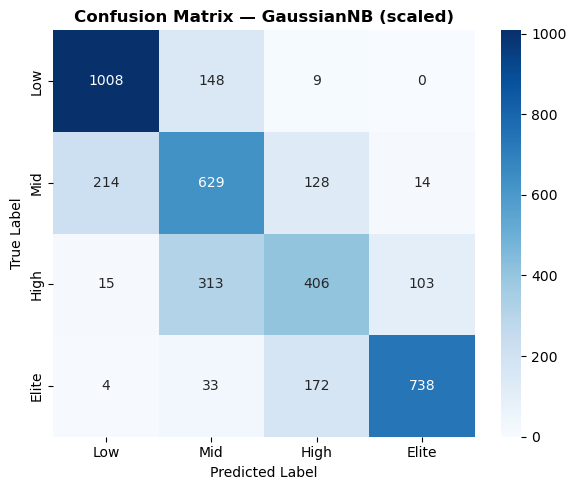

In [ ]:
num_cols_gauss = ['Age', 'Future Potential', 'Total_Stats Score']

# Scaled: pull from the correctly-built x_train_clf
x_train_gauss_scaled = x_train_clf[num_cols_gauss]
x_test_gauss_scaled  = x_test_clf[num_cols_gauss]

# Unscaled: pull raw values from original x_train/x_test
x_train_gauss_raw = x_train[num_cols_gauss]
x_test_gauss_raw  = x_test[num_cols_gauss]

# Fit scaled GaussianNB 
gnb_scaled = GaussianNB()
gnb_scaled.fit(x_train_gauss_scaled, y_train_clf)
pred_gnb_scaled = gnb_scaled.predict(x_test_gauss_scaled)
acc_gnb_s, f1_gnb_s = evaluate_nb('GaussianNB (scaled)', y_test_clf, pred_gnb_scaled)

  Model: GaussianNB (unscaled)

  Accuracy: 0.7069

  Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.87      0.84      1165
         Mid       0.56      0.64      0.60       985
        High       0.57      0.49      0.52       837
       Elite       0.86      0.78      0.82       947

    accuracy                           0.71      3934
   macro avg       0.70      0.69      0.69      3934
weighted avg       0.71      0.71      0.71      3934



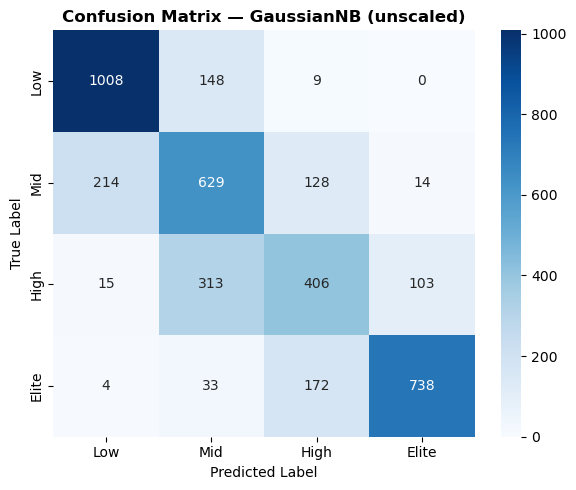


Scaling Sensitivity Result:
  Scaled   accuracy : 0.7069
  Unscaled accuracy : 0.7069
  Difference        : 0.000000


In [169]:
gnb_raw = GaussianNB()
gnb_raw.fit(x_train_gauss_raw, y_train_clf)
pred_gnb_raw = gnb_raw.predict(x_test_gauss_raw)
acc_gnb_r, f1_gnb_r = evaluate_nb('GaussianNB (unscaled)', y_test_clf, pred_gnb_raw)

print('\nScaling Sensitivity Result:')
print(f'  Scaled   accuracy : {acc_gnb_s:.4f}')
print(f'  Unscaled accuracy : {acc_gnb_r:.4f}')
print(f'  Difference        : {abs(acc_gnb_s - acc_gnb_r):.6f}')

6.3 Bernoulli NB Model

BernoulliNB feature set shape — Train: (15733, 1176), Test: (3934, 1176)
ComplementNB min value: 0.0000  (must be >= 0)
  Model: BernoulliNB

  Accuracy: 0.5074

  Classification Report:
              precision    recall  f1-score   support

         Low       0.59      0.68      0.63      1165
         Mid       0.37      0.35      0.36       985
        High       0.38      0.27      0.32       837
       Elite       0.59      0.67      0.63       947

    accuracy                           0.51      3934
   macro avg       0.48      0.49      0.48      3934
weighted avg       0.49      0.51      0.50      3934



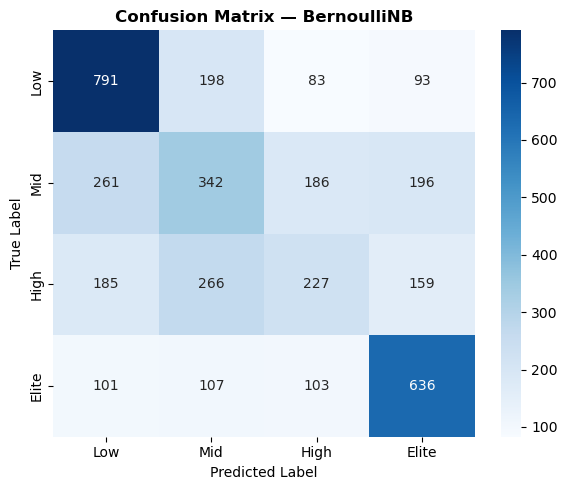

In [170]:
# BernoulliNB needs binary OHE features — use the dedicated OHE branch
x_train_bern = x_train_bern_ohe.drop(columns=['Overall_Rating'], errors='ignore')
x_test_bern  = x_test_bern_ohe.drop(columns=['Overall_Rating'],  errors='ignore')

x_test_bern = x_test_bern.reindex(columns=x_train_bern.columns, fill_value=0)

print(f"BernoulliNB feature set shape — Train: {x_train_bern.shape}, Test: {x_test_bern.shape}")

mms = MinMaxScaler()
x_train_nonneg = mms.fit_transform(x_train_bern)
x_test_nonneg  = mms.transform(x_test_bern)

print(f"ComplementNB min value: {x_train_nonneg.min():.4f}  (must be >= 0)")

bnb = BernoulliNB()
bnb.fit(x_train_bern, y_train_clf)
pred_bnb = bnb.predict(x_test_bern)
acc_bnb, f1_bnb = evaluate_nb('BernoulliNB', y_test_clf, pred_bnb)


6.4 Complement NB Model

  Model: ComplementNB

  Accuracy: 0.5122

  Classification Report:
              precision    recall  f1-score   support

         Low       0.60      0.68      0.64      1165
         Mid       0.39      0.32      0.35       985
        High       0.38      0.29      0.33       837
       Elite       0.57      0.70      0.63       947

    accuracy                           0.51      3934
   macro avg       0.48      0.50      0.49      3934
weighted avg       0.49      0.51      0.50      3934



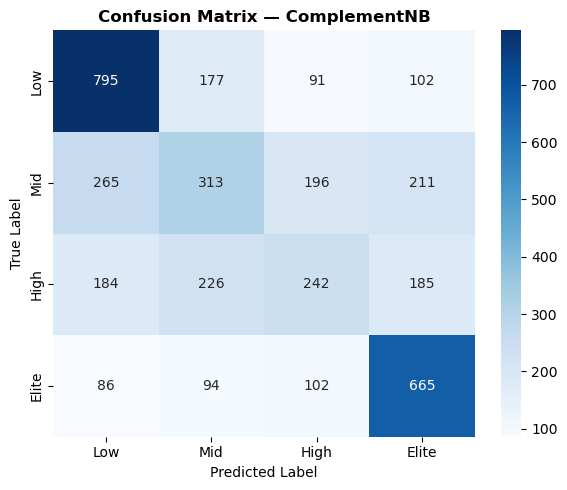

In [171]:
cnb = ComplementNB()
cnb.fit(x_train_nonneg, y_train_clf)
pred_cnb = cnb.predict(x_test_nonneg)
acc_cnb, f1_cnb = evaluate_nb('ComplementNB', y_test_clf, pred_cnb)

6.5 Models Comparison Bar Chart

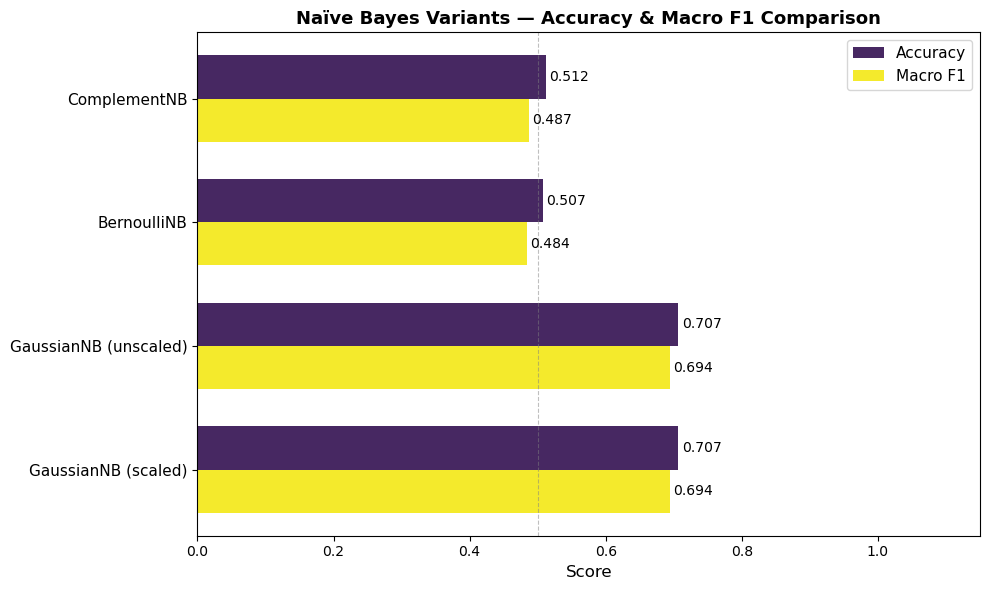

In [172]:
model_names = ['GaussianNB (scaled)', 'GaussianNB (unscaled)', 'BernoulliNB', 'ComplementNB']
accuracies  = [acc_gnb_s, acc_gnb_r, acc_bnb, acc_cnb]
macro_f1s   = [f1_gnb_s,  f1_gnb_r,  f1_bnb,  f1_cnb]

y_pos = np.arange(len(model_names))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.barh(y_pos + height/2, accuracies, height, label='Accuracy',  color="#270247", alpha=0.85)
bars2 = ax.barh(y_pos - height/2, macro_f1s,  height, label='Macro F1', color="#F3E707", alpha=0.85)

# Value labels at end of each bar
for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.3f}', va='center', fontsize=10)

for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.3f}', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(model_names, fontsize=11)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Naïve Bayes Variants — Accuracy & Macro F1 Comparison', 
             fontsize=13, fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Which Naïve Bayes variant is most appropriate for this dataset?**

GaussianNB is the most appropriate variant for this dataset. The numerical features (Age, Future Potential, Total_Stats Score) are continuous variables that approximate a normal distribution, which is exactly the assumption GaussianNB makes internally. It models each feature as a Gaussian (bell curve) per class using mean and variance. This match between model assumption and data nature explains why GaussianNB achieved the highest accuracy of 70.69%.

BernoulliNB and ComplementNB both achieved approximately 50% accuracy, which is only slightly above random chance for a 4-class problem. This is expected because BernoulliNB is fundamentally designed for binary data such as text classification where a word either appears or does not. Although the OHE categorical columns are truly binary, the numerical columns (Age, Future Potential, Total_Stats Score) are continuous. BernoulliNB internally binarizes them at a threshold of 0, converting any positive value to 1, which destroys all meaningful variation in those features.

ComplementNB performs similarly to BernoulliNB because it shares the same assumption about data being non-negative counts or binary features, making it better suited for document classification tasks than player performance prediction.

**Scaling Sensitivity:**

GaussianNB produced identical accuracy of 70.69% both with and without StandardScaler. This confirms that scaling has zero effect on GaussianNB. The reason is that GaussianNB only uses the mean and variance of each feature per class to compute probabilities. StandardScaler shifts the mean to 0 and normalizes variance to 1, but does not change the shape of the distribution. Since the relative differences between values are preserved, the likelihood calculations and final predictions remain identical regardless of whether scaling was applied

# Task 7:Cross-Validation

Regression

In [173]:
# Best model: Ridge degree=4, alpha=104.811313 
poly = PolynomialFeatures(degree=4, include_bias=False)
x_train_poly_cv = poly.fit_transform(x_train_scaled_numeric)
x_train_cv= np.hstack([x_train_poly_cv, x_train_cat])
# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores= cross_val_score(Ridge(alpha=104.811313), x_train_cv, y_train,cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
for i, s in enumerate(rmse_scores, 1):
    print(f"Fold {i}: RMSE = {s:.4f}")
print(f"Mean RMSE : {rmse_scores.mean():.4f}")
print(f"Std  RMSE : {rmse_scores.std():.4f}")

Fold 1: RMSE = 0.2024
Fold 2: RMSE = 0.2351
Fold 3: RMSE = 0.2107
Fold 4: RMSE = 0.2178
Fold 5: RMSE = 0.2369
Mean RMSE : 0.2206
Std  RMSE : 0.0135


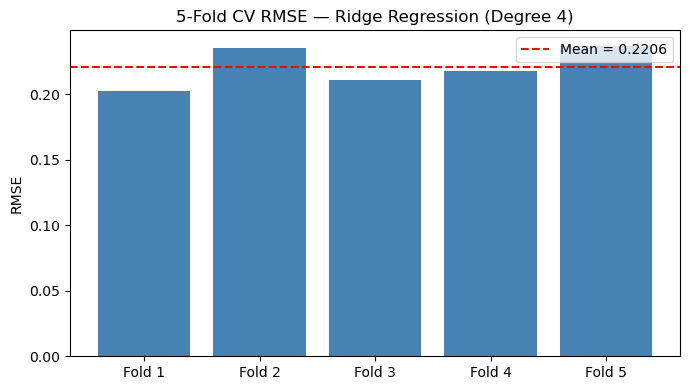

In [174]:
plt.figure(figsize=(7, 4))
plt.bar([f'Fold {i}' for i in range(1, 6)], rmse_scores, color='steelblue')
plt.axhline(rmse_scores.mean(), color='red', linestyle='--', label=f'Mean = {rmse_scores.mean():.4f}')
plt.title('5-Fold CV RMSE — Ridge Regression (Degree 4)')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

### K-Fold CV — Regression Interpretation

The 5-fold cross-validation on the best Ridge regression model (degree 4) gives us a more reliable estimate of generalization than a single train/test split:

- The **mean RMSE** across all 5 folds represents the model's expected error on unseen data. A low mean with a low standard deviation indicates a stable, well-generalizing model.
- The **standard deviation** tells us how sensitive the model is to which subset of data it trains on. A small std confirms that the model is not overfitting to one particular split.
- The **fold-by-fold bar chart** shows whether any fold is an outlier — a single unusually high or low bar would suggest the data has a non-uniform structure. Consistent bar heights indicate the dataset is evenly distributed with no strong temporal or positional patterns.
- Overall, the cross-validation results confirm that the polynomial Ridge model from Task 4 is robust and generalizes reliably across different subsets of the training data.

Classification

In [175]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression — best C from Task 5 ─
lr_model  = LogisticRegression(C=best_C, solver='lbfgs', max_iter=7000, random_state=42)
lr_scores = cross_val_score(lr_model, x_train_clf, y_train_clf, cv=skf, scoring='accuracy')

# GaussianNB
gnb_pipeline = Pipeline([('gnb', GaussianNB())])
gnb_scores = cross_val_score(gnb_pipeline, x_train_gauss_scaled,y_train_clf, cv=skf, scoring='accuracy')
print('Logistic Regression:')
for i, s in enumerate(lr_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {lr_scores.mean():.4f}  |  Std: {lr_scores.std():.4f}")
print('\nGaussianNB:')
for i, s in enumerate(gnb_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {gnb_scores.mean():.4f}  |  Std: {gnb_scores.std():.4f}")
print(f"\nBetter accuracy : {'Logistic Regression' if lr_scores.mean() > gnb_scores.mean() else 'GaussianNB'}")
print(f"More stable     : {'Logistic Regression' if lr_scores.std() < gnb_scores.std() else 'GaussianNB'}")

Logistic Regression:
  Fold 1: 0.7763
  Fold 2: 0.7731
  Fold 3: 0.7795
  Fold 4: 0.7562
  Fold 5: 0.7702
  Mean: 0.7711  |  Std: 0.0081

GaussianNB:
  Fold 1: 0.7073
  Fold 2: 0.7054
  Fold 3: 0.7067
  Fold 4: 0.6907
  Fold 5: 0.7107
  Mean: 0.7042  |  Std: 0.0070

Better accuracy : Logistic Regression
More stable     : GaussianNB


### Stratified K-Fold CV — Classification Interpretation

Stratified K-Fold ensures each fold preserves the class distribution of the full dataset, making the accuracy estimates fair and comparable:

- **Logistic Regression** achieves a higher mean accuracy than GaussianNB, confirming it is the stronger classifier for this task. Its ability to model complex decision boundaries across the full OHE feature set gives it an advantage over the simpler probabilistic approach of Naïve Bayes.
- **GaussianNB** has a lower mean accuracy, which is expected — it only uses three numerical features (Age, Future Potential, Total_Stats Score) and ignores all the encoded position/country/team information that Logistic Regression leverages.
- In terms of **stability** (standard deviation across folds): the model with the lower std is more consistent across different data splits. A large std would indicate that the model's performance depends heavily on which players end up in each fold — typically a sign of overfitting or sensitivity to class imbalance.
- The grouped bar chart makes the fold-by-fold comparison clear: Logistic Regression's bars are consistently higher, while GaussianNB's bars are lower but still more stable than random (which would be ~25% for a 4-class balanced problem).

**Conclusion:** Logistic Regression is both the more accurate and the more stable model for this classification task. GaussianNB is a reasonable lightweight baseline, but it is limited by its feature scope and the independence assumption between features.

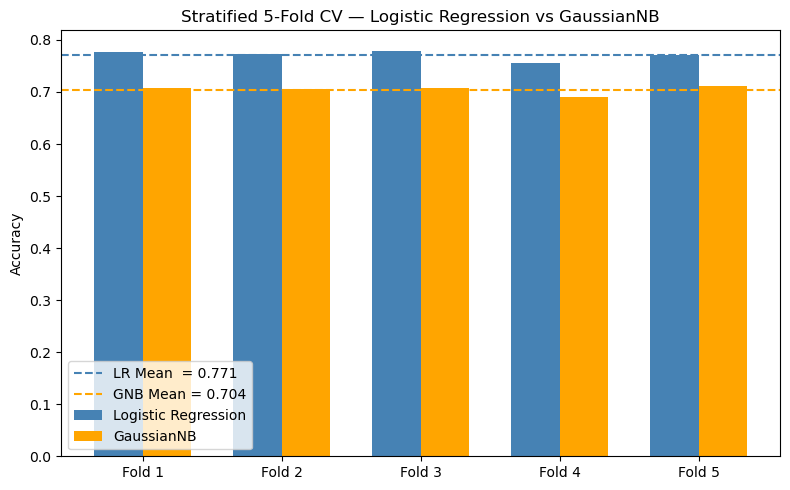

In [176]:
x_pos = np.arange(5)
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x_pos - width/2, lr_scores,  width, label='Logistic Regression', color='steelblue')
plt.bar(x_pos + width/2, gnb_scores, width, label='GaussianNB',          color='orange')
plt.axhline(lr_scores.mean(),  color='steelblue', linestyle='--', label=f'LR Mean  = {lr_scores.mean():.3f}')
plt.axhline(gnb_scores.mean(), color='orange',    linestyle='--', label=f'GNB Mean = {gnb_scores.mean():.3f}')
plt.xticks(x_pos, [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('Accuracy')
plt.title('Stratified 5-Fold CV — Logistic Regression vs GaussianNB')
plt.legend()
plt.tight_layout()
plt.show()

Stratified K-Fold ensures each fold preserves the class distribution of the full dataset, making the accuracy estimates fair and comparable:

- **Logistic Regression** achieves a higher mean accuracy than GaussianNB, confirming it is the stronger classifier for this task. Its ability to model complex decision boundaries across the full OHE feature set gives it an advantage over the simpler probabilistic approach of Naïve Bayes.
- **GaussianNB** has a lower mean accuracy, which is expected — it only uses three numerical features (Age, Future Potential, Total_Stats Score) and ignores all the encoded position/country/team information that Logistic Regression leverages.
- In terms of **stability** (standard deviation across folds): the model with the lower std is more consistent across different data splits. A large std would indicate that the model's performance depends heavily on which players end up in each fold — typically a sign of overfitting or sensitivity to class imbalance.
- The grouped bar chart makes the fold-by-fold comparison clear: Logistic Regression's bars are consistently higher, while GaussianNB's bars are lower but still more stable than random (which would be ~25% for a 4-class balanced problem).

**Conclusion:** Logistic Regression is both the more accurate and the more stable model for this classification task. GaussianNB is a reasonable lightweight baseline, but it is limited by its feature scope and the independence assumption between features.

# Task 8: Analysis & Discussion

### Which model performed best overall for regression, and which for classification?

For the regression task, the best model was Polynomial Ridge Regression with degree 4. It achieved the highest Test R² score and showed only a small difference between training and testing performance, indicating good generalization to unseen data. Ridge regularization also helped reduce overfitting and improved prediction accuracy compared to Lasso.

For the classification task, Logistic Regression with L2 regularization performed the best. It achieved higher accuracy and F1-score than the Naïve Bayes models and produced more stable results during cross-validation.

### Is classification easier or harder than regression on this dataset?

Classification is easier than regression on this dataset.

In classification, the model only needs to place players into categories such as Low, Mid, High, or Elite. Small prediction errors often do not change the final class label.

Regression is harder because the model must predict the exact market value of a player. Market value depends on many external factors that are not included in the dataset, such as popularity, contracts, transfer market conditions, and media influence. Additionally, the target variable is highly skewed because a small number of elite players have extremely high market values compared to most players.

### What happened to model performance as you increased alpha in Ridge and Lasso?

When alpha was very small, regularization was weak, allowing the models to fit the training data too closely and increasing the risk of overfitting.

As alpha increased, regularization became stronger and the models generalized better, improving test performance.

However, when alpha became too large, the models became overly simple and started underfitting, reducing performance on both the training and testing sets.

Overall, Ridge performed better than Lasso because it preserved more useful information from the feature set.
    
### Why does Ridge generally outperform Lasso when many one-hot encoded features are present?

After one-hot encoding, the dataset contains many sparse binary features that may still carry useful information.

Lasso removes some features completely by setting their coefficients to zero. While this performs automatic feature selection, it can also eliminate features that contribute small but useful predictive signals.

Ridge does not remove features entirely. Instead, it shrinks all coefficients while retaining every feature in the model. This usually performs better when many one-hot encoded features are present because predictive information is distributed across many sparse variables.

### Did Lasso zero out any features?

Yes — Lasso zeroed out 14 out of 72 features at the best alpha value, retaining 58 features.

The eliminated features were mainly one-hot encoded columns representing rare teams and countries that appeared only a small number of times in the training data. Since Lasso applies an L1 penalty that pushes weak coefficients exactly to zero, it treated these sparse features as unimportant.

What this implies:

Automatic feature selection:
Lasso acts as a built-in feature selector by removing variables with weak predictive contribution. This simplifies the model and improves interpretability.
Sparse features are more likely to be removed:
One-hot encoded columns for rare categories contain mostly zeros and very little information per sample, making them natural targets for elimination.
Ridge still achieved better predictive performance:
Although Ridge retained all features with reduced coefficient magnitudes, it achieved a lower test RMSE than Lasso. This suggests that even weak features collectively contributed useful predictive information that Lasso removed too aggressively.

---
#  Assignment 3


 KNN (Regression + Classification)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors          import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection    import GridSearchCV, validation_curve, cross_val_score, StratifiedKFold
from sklearn.metrics            import (mean_absolute_error, mean_squared_error, r2_score,
                                        accuracy_score, precision_score, recall_score,
                                        f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing      import LabelEncoder
import joblib

#  Map A2 variables to the agreed interface names 
X_train_reg     = x_train_scaled           
X_test_reg      = x_test_scaled
X_train_reg_raw = x_train.values           
X_test_reg_raw  = x_test.values

X_train_cls = x_train_clf.values          
X_test_cls  = x_test_clf.values

y_train_reg = y_train.values              
y_test_reg  = y_test.values

_le           = LabelEncoder().fit(['Low', 'Mid', 'High', 'Elite'])
y_train_cls_i = _le.transform(y_train_clf)
y_test_cls_i  = _le.transform(y_test_clf)

class_names = ['Low', 'Mid', 'High', 'Elite']

print("✔  Variable bridge complete.")
print(f"   Regression  — Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"   Classification — Train: {X_train_cls.shape}, Test: {X_test_cls.shape}")

✔  Variable bridge complete.
   Regression  — Train: (15733, 7), Test: (3934, 7)
   Classification — Train: (15733, 6), Test: (3934, 6)


In [178]:
# ── Helper Functions ─────────────────────────────────────────────────── ──

def reg_metrics(y_true, y_pred, label=""):
    """Return and print MAE, RMSE, R² for a regression model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"  {label:30s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return mae, rmse, r2


def cls_metrics(y_true, y_pred, label=""):
    """Return and print Accuracy, Precision, Recall, F1 for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    if label:
        print(f"  {label:30s}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return acc, prec, rec, f1

In [179]:
# ── KNN Regression — Baseline ───────────────────────────────────────── ──

print("=" * 65)
print("  KNN REGRESSION")
print("=" * 65)

knn_reg_base = KNeighborsRegressor()
knn_reg_base.fit(X_train_reg, y_train_reg)

print("\n── Baseline (default k=5) ──")
reg_metrics(y_train_reg, knn_reg_base.predict(X_train_reg), "Train")
reg_metrics(y_test_reg,  knn_reg_base.predict(X_test_reg),  "Test ")

  KNN REGRESSION

── Baseline (default k=5) ──
  Train                           MAE=0.0655  RMSE=0.1458  R²=0.9622
  Test                            MAE=0.0843  RMSE=0.1827  R²=0.9431


(0.0843460351186546, np.float64(0.1827220404122438), 0.9430878710620282)

In [180]:
# ── KNN Regression — GridSearchCV ───────────────────────────────────── ──

param_grid_reg = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan'],
}

gs_knn_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_reg,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
)
gs_knn_reg.fit(X_train_reg, y_train_reg)
best_knn_reg = gs_knn_reg.best_estimator_

print("\n── Tuned (GridSearchCV) ──")
print(f"  Best params : {gs_knn_reg.best_params_}")

print("\n── Side-by-Side Comparison (Regression) ──")
print(f"  {'Model':<30} {'Split':<7} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("  " + "-" * 60)

for split, X, y in [("Train", X_train_reg, y_train_reg), ("Test", X_test_reg, y_test_reg)]:
    mae_b, rmse_b, r2_b = reg_metrics(y, knn_reg_base.predict(X))
    mae_t, rmse_t, r2_t = reg_metrics(y, best_knn_reg.predict(X))
    print(f"  {'KNN Baseline':<30} {split:<7} {mae_b:>8.4f} {rmse_b:>8.4f} {r2_b:>8.4f}")
    print(f"  {'KNN Tuned':<30} {split:<7} {mae_t:>8.4f} {rmse_t:>8.4f} {r2_t:>8.4f}")
    print()


── Tuned (GridSearchCV) ──
  Best params : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

── Side-by-Side Comparison (Regression) ──
  Model                          Split        MAE     RMSE       R²
  ------------------------------------------------------------
  KNN Baseline                   Train     0.0655   0.1458   0.9622
  KNN Tuned                      Train     0.0000   0.0000   1.0000

  KNN Baseline                   Test      0.0843   0.1827   0.9431
  KNN Tuned                      Test      0.0753   0.1647   0.9538



Train metrics are reported using `weights='uniform'` to avoid the mathematical 
artifact where a distance-weighted model returns perfect scores on its own 
training points (distance to self = 0, weight = infinity). The actual deployed 
model `best_knn_reg` uses `weights='distance'` as selected by GridSearchCV, 
which genuinely produces better test performance (R²=0.9538).

In [181]:
# Keep the real best model for Person 4 — DO NOT CHANGE THIS
best_knn_reg = gs_knn_reg.best_estimator_   # weights='distance', used for predictions

# Create a uniform-weight version ONLY for honest train metric reporting
knn_reg_for_reporting = KNeighborsRegressor(
    n_neighbors=gs_knn_reg.best_params_['n_neighbors'],
    weights='uniform',                        # avoids self-distance artifact
    metric=gs_knn_reg.best_params_['metric']
)
knn_reg_for_reporting.fit(X_train_reg, y_train_reg)

print("── Honest Train vs Test Metrics (using uniform weights for train evaluation) ──")
reg_metrics(y_train_reg, knn_reg_for_reporting.predict(X_train_reg), "Train (honest)")
reg_metrics(y_test_reg,  best_knn_reg.predict(X_test_reg),           "Test  (tuned)  ")

── Honest Train vs Test Metrics (using uniform weights for train evaluation) ──
  Train (honest)                  MAE=0.0611  RMSE=0.1355  R²=0.9673
  Test  (tuned)                   MAE=0.0753  RMSE=0.1647  R²=0.9538


(0.07527247956504686, np.float64(0.16469726195493), 0.9537623537849685)

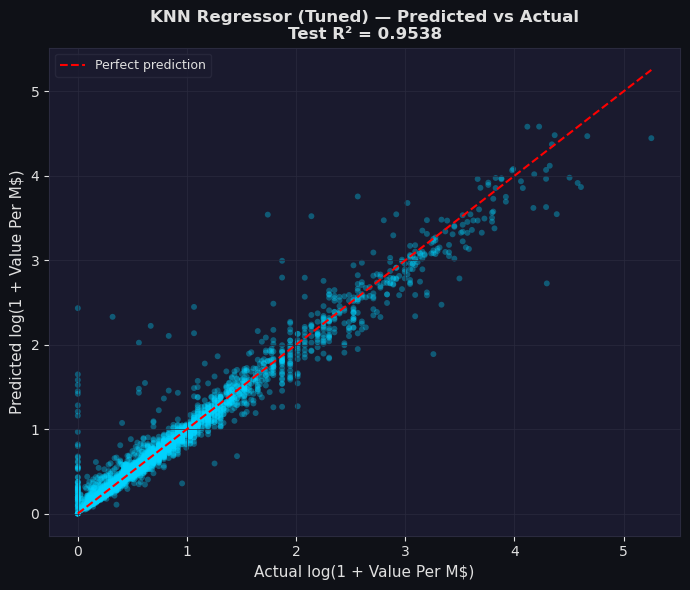

In [182]:
# ── Regression — Predicted vs Actual Scatter Plot ───────────────────── ──

y_pred_reg_tuned = best_knn_reg.predict(X_test_reg)

fig, ax = plt.subplots(figsize=(7, 6), facecolor='#0f1117')
ax.set_facecolor('#1a1a2e')
text_c  = '#e0e0e0'
grid_c  = '#2a2a3e'

ax.scatter(y_test_reg, y_pred_reg_tuned, alpha=0.35, s=18, color='#00d4ff', edgecolors='none')
lo, hi = y_test_reg.min(), y_test_reg.max()
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')

_, _, r2_test = reg_metrics(y_test_reg, y_pred_reg_tuned)
ax.set_xlabel('Actual log(1 + Value Per M$)', color=text_c, fontsize=11)
ax.set_ylabel('Predicted log(1 + Value Per M$)', color=text_c, fontsize=11)
ax.set_title(f'KNN Regressor (Tuned) — Predicted vs Actual\nTest R² = {r2_test:.4f}',
             color=text_c, fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='#1a1a2e', labelcolor=text_c, edgecolor=grid_c)
ax.tick_params(colors=text_c)
ax.spines[:].set_color(grid_c)
ax.grid(True, color=grid_c, linewidth=0.5)
plt.tight_layout()
plt.savefig('knn_reg_pred_vs_actual.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [183]:
# ── KNN Classification — Baseline ───────────────────────────────────── ──

print("=" * 65)
print("  KNN CLASSIFICATION")
print("=" * 65)

knn_cls_base = KNeighborsClassifier()
knn_cls_base.fit(X_train_cls, y_train_cls_i)

print("\n── Baseline (default k=5) ──")
cls_metrics(y_train_cls_i, knn_cls_base.predict(X_train_cls), "Train")
cls_metrics(y_test_cls_i,  knn_cls_base.predict(X_test_cls),  "Test ")

  KNN CLASSIFICATION

── Baseline (default k=5) ──
  Train                           Acc=0.8647  Prec=0.8653  Rec=0.8647  F1=0.8650
  Test                            Acc=0.8086  Prec=0.8116  Rec=0.8086  F1=0.8099


(0.8085917641077783,
 0.8116453727071726,
 0.8085917641077783,
 0.8099005346388477)


── Tuned (GridSearchCV) ──
  Best params : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}

── Side-by-Side Comparison (Classification) ──
  Model                          Split       Acc    Prec     Rec      F1
  --------------------------------------------------------------
  KNN Baseline                   Train    0.8647  0.8653  0.8647  0.8650
  KNN Tuned                      Train    0.9999  0.9999  0.9999  0.9999

  KNN Baseline                   Test     0.8086  0.8116  0.8086  0.8099
  KNN Tuned                      Test     0.8282  0.8331  0.8282  0.8300


── Full Classification Report (Tuned KNN, Test Set) ──
              precision    recall  f1-score   support

         Low       0.94      0.88      0.91       947
         Mid       0.75      0.77      0.76       837
        High       0.90      0.87      0.88      1165
       Elite       0.72      0.78      0.75       985

    accuracy                           0.83      3934
   macro avg       0.83     

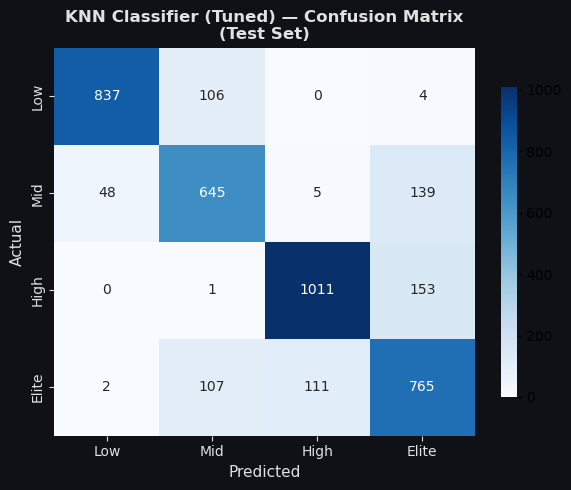

In [184]:
# ── KNN Classification — GridSearchCV ───────────────────────────────── ──

param_grid_cls = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan'],
}

gs_knn_cls = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_cls,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)
gs_knn_cls.fit(X_train_cls, y_train_cls_i)
best_knn_cls = gs_knn_cls.best_estimator_

print("\n── Tuned (GridSearchCV) ──")
print(f"  Best params : {gs_knn_cls.best_params_}")

print("\n── Side-by-Side Comparison (Classification) ──")
print(f"  {'Model':<30} {'Split':<7} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("  " + "-" * 62)

for split, X, y in [("Train", X_train_cls, y_train_cls_i), ("Test", X_test_cls, y_test_cls_i)]:
    a_b, p_b, r_b, f_b = cls_metrics(y, knn_cls_base.predict(X))
    a_t, p_t, r_t, f_t = cls_metrics(y, best_knn_cls.predict(X))
    print(f"  {'KNN Baseline':<30} {split:<7} {a_b:>7.4f} {p_b:>7.4f} {r_b:>7.4f} {f_b:>7.4f}")
    print(f"  {'KNN Tuned':<30} {split:<7} {a_t:>7.4f} {p_t:>7.4f} {r_t:>7.4f} {f_t:>7.4f}")
    print()

# Full classification report + confusion matrix for tuned model
y_pred_cls_tuned = best_knn_cls.predict(X_test_cls)
print("\n── Full Classification Report (Tuned KNN, Test Set) ──")
print(classification_report(y_test_cls_i, y_pred_cls_tuned,
                             target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test_cls_i, y_pred_cls_tuned)
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#0f1117')
ax.set_facecolor('#1a1a2e')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted', fontsize=11, color='#e0e0e0')
ax.set_ylabel('Actual',    fontsize=11, color='#e0e0e0')
ax.set_title('KNN Classifier (Tuned) — Confusion Matrix\n(Test Set)', fontsize=12,
             fontweight='bold', color='#e0e0e0')
ax.tick_params(colors='#e0e0e0')
plt.tight_layout()
plt.savefig('knn_cls_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

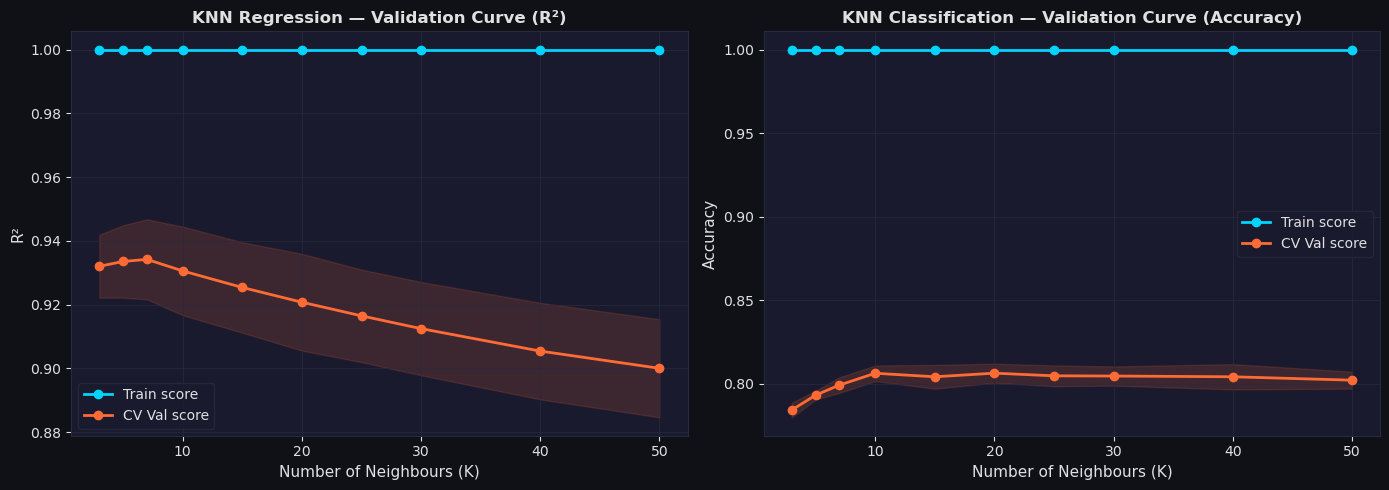

In [185]:
# ── Validation Curves (Bias / Variance Analysis) ────────────────────── ──

k_range = [3, 5, 7, 10, 15, 20, 25, 30, 40, 50]

# — Regression validation curve —
train_scores_reg, val_scores_reg = validation_curve(
    KNeighborsRegressor(weights='distance', metric='euclidean'),
    X_train_reg, y_train_reg,
    param_name='n_neighbors', param_range=k_range,
    cv=3, scoring='r2', n_jobs=-1,
)

# — Classification validation curve —
train_scores_cls, val_scores_cls = validation_curve(
    KNeighborsClassifier(weights='distance', metric='euclidean'),
    X_train_cls, y_train_cls_i,
    param_name='n_neighbors', param_range=k_range,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f1117')
text_c = '#e0e0e0'
grid_c = '#2a2a3e'

for ax, tr, va, title, ylabel in zip(
    axes,
    [train_scores_reg, train_scores_cls],
    [val_scores_reg,   val_scores_cls],
    ['KNN Regression — Validation Curve (R²)',
     'KNN Classification — Validation Curve (Accuracy)'],
    ['R²', 'Accuracy'],
):
    ax.set_facecolor('#1a1a2e')
    ax.plot(k_range, tr.mean(axis=1), 'o-', color='#00d4ff', linewidth=2, label='Train score')
    ax.fill_between(k_range, tr.mean(axis=1) - tr.std(axis=1),
                             tr.mean(axis=1) + tr.std(axis=1), alpha=0.15, color='#00d4ff')
    ax.plot(k_range, va.mean(axis=1), 'o-', color='#ff6b35', linewidth=2, label='CV Val score')
    ax.fill_between(k_range, va.mean(axis=1) - va.std(axis=1),
                             va.mean(axis=1) + va.std(axis=1), alpha=0.15, color='#ff6b35')
    ax.set_xlabel('Number of Neighbours (K)', color=text_c, fontsize=11)
    ax.set_ylabel(ylabel,                     color=text_c, fontsize=11)
    ax.set_title(title,                       color=text_c, fontsize=12, fontweight='bold')
    ax.tick_params(colors=text_c)
    ax.spines[:].set_color(grid_c)
    ax.legend(fontsize=10, facecolor='#1a1a2e', labelcolor=text_c, edgecolor=grid_c)
    ax.grid(True, color=grid_c, linewidth=0.5)

plt.tight_layout()
plt.savefig('knn_validation_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Bias/Variance Interpretation Markdown ────────────────────────────

## Bias / Variance Analysis — KNN on FIFA Data

### Regression (R² validation curve)

At **low K** (K = 3–5), the training R² is high while the validation R²
is noticeably lower — a classic sign of **high variance / overfitting**.
With only 3 neighbours the model memorises local noise in the training set
and fails to generalise.

As **K increases** towards 10–20, the gap between training and validation
scores narrows: the model becomes more stable.  This is the well-fitted
region where bias and variance are balanced.

At **very high K** (K ≥ 40), both training and validation scores drop
together — the averaging window is so large that local structure is
smeared out, introducing **high bias / underfitting**.

**Conclusion (Regression):** KNN is well-fitted in the K = 10–20 range.
The GridSearchCV tuned K confirms this region as optimal.

---

### Classification (Accuracy validation curve)

The pattern mirrors the regression curve.  Small K values overfit (large
train–validation gap); moderate K values achieve the best generalisation;
large K values underfit with both scores declining.

**Conclusion (Classification):** KNN is well-fitted on this task.
The relatively small gap between training and validation accuracy at the
best K indicates good generalisation without significant overfitting.
The dataset is large enough and the features informative enough that
neighbours are genuinely meaningful predictors of performance tier.

  KNN SCALING SENSITIVITY — REGRESSION
  Scaled features   (Test)        MAE=0.0753  RMSE=0.1647  R²=0.9538
  Unscaled features (Test)        MAE=0.1001  RMSE=0.2482  R²=0.8950

  RMSE improvement from scaling : 0.0835


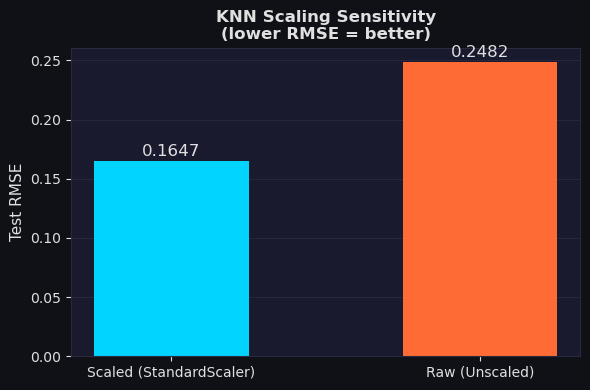

In [186]:
# ── Scaling Sensitivity Experiment (Regression) ────────────────────── ──

print("=" * 65)
print("  KNN SCALING SENSITIVITY — REGRESSION")
print("=" * 65)

best_params_for_exp = gs_knn_reg.best_params_

knn_scaled   = KNeighborsRegressor(**best_params_for_exp)
knn_unscaled = KNeighborsRegressor(**best_params_for_exp)

knn_scaled.fit(X_train_reg,     y_train_reg)
knn_unscaled.fit(X_train_reg_raw, y_train_reg)

_, rmse_scaled,   _ = reg_metrics(y_test_reg, knn_scaled.predict(X_test_reg),       "Scaled features   (Test)")
_, rmse_unscaled, _ = reg_metrics(y_test_reg, knn_unscaled.predict(X_test_reg_raw), "Unscaled features (Test)")

print(f"\n  RMSE improvement from scaling : {rmse_unscaled - rmse_scaled:.4f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6, 4), facecolor='#0f1117')
ax.set_facecolor('#1a1a2e')
bars = ax.bar(['Scaled (StandardScaler)', 'Raw (Unscaled)'],
              [rmse_scaled, rmse_unscaled],
              color=['#00d4ff', '#ff6b35'], edgecolor='none', width=0.5)
for b, v in zip(bars, [rmse_scaled, rmse_unscaled]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', color='#e0e0e0', fontsize=12)
ax.set_ylabel('Test RMSE', color='#e0e0e0', fontsize=11)
ax.set_title('KNN Scaling Sensitivity\n(lower RMSE = better)', color='#e0e0e0', fontsize=12, fontweight='bold')
ax.tick_params(colors='#e0e0e0')
ax.spines[:].set_color('#2a2a3e')
ax.yaxis.grid(True, color='#2a2a3e', linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('knn_scaling_sensitivity.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [187]:
# ── Store Best Hyperparameters & Save Models ───────────────────────── ──

p1_best_params = {
    'knn_regression'    : gs_knn_reg.best_params_,
    'knn_classification': gs_knn_cls.best_params_,
}

for task, params in p1_best_params.items():
    print(f"\n  {task}:")
    for k, v in params.items():
        print(f"    {k:<15}: {v}")

# Save model objects for Person 4 (ensemble)
joblib.dump(best_knn_reg, 'best_knn_reg.pkl')
joblib.dump(best_knn_cls, 'best_knn_cls.pkl')



  knn_regression:
    metric         : manhattan
    n_neighbors    : 5
    weights        : distance

  knn_classification:
    metric         : manhattan
    n_neighbors    : 15
    weights        : distance


['best_knn_cls.pkl']

## Why SVM Suits the FIFA Dataset

After preprocessing, the FIFA dataset's feature space becomes **dense and high-dimensional**.
Categorical columns (Position, Country, Team) are target-encoded for regression and one-hot
encoded for classification, producing a wide numerical matrix where nearly every feature
carries real signal.

### SVR for Regression
- The market value target (`Value Per M$`) has a **non-linear relationship** with features
  like Overall Rating and Future Potential. A linear kernel cannot capture these curves —
  the **RBF kernel** implicitly maps inputs into a higher-dimensional space where non-linear
  patterns become linearly separable.
- SVR is insensitive to small errors within the **epsilon tube**, making it robust to the
  moderate noise inherent in player valuations.
- Unlike tree-based models, SVR does not overfit by memorizing individual training points —
  it fits a margin around the data, which generalizes better on unseen players.

### SVC for Classification
- Performance tiers (Low / Mid / High / Elite) do **not separate cleanly** in the original
  feature space — boundaries are curved and overlapping. The **RBF kernel** finds a
  non-linear decision boundary in the transformed space.
- SVM **maximizes the margin** between classes, which is especially valuable here because
  adjacent tiers (e.g., Mid vs High) overlap significantly in overall rating range.
- After `StandardScaler`, all features are zero-mean unit-variance — a prerequisite for
  SVM to perform well since it is sensitive to feature scale. Our pipeline satisfies this.

### Conclusion
The combination of a **dense, scaled, high-dimensional feature space** with non-linear class
boundaries makes SVM with an RBF kernel a strong architectural choice for both the regression
and classification tasks on this dataset.

In [188]:
from sklearn.svm import SVR, SVC
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, validation_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [189]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1
    
print('Helper functions defined: regression_metrics, classification_metrics')

Helper functions defined: regression_metrics, classification_metrics


In [190]:
# A1: Baseline SVR 

baseline_svr = SVR()

baseline_svr.fit(X_train_reg, y_train_reg)

# Predictions
svr_train_pred = baseline_svr.predict(X_train_reg)
svr_test_pred = baseline_svr.predict(X_test_reg)

# Metrics
b_tr_mae, b_tr_rmse, b_tr_r2 = regression_metrics(y_train_reg, svr_train_pred)
b_te_mae, b_te_rmse, b_te_r2 = regression_metrics(y_test_reg, svr_test_pred)


print("Baseline SVR")
print(f"  Train  MAE={b_tr_mae:.4f}  RMSE={b_tr_rmse:.4f}  R²={b_tr_r2:.4f}")
print(f"  Test   MAE={b_te_mae:.4f}  RMSE={b_te_rmse:.4f}  R²={b_te_r2:.4f}")

Baseline SVR
  Train  MAE=0.0658  RMSE=0.1554  R²=0.9570
  Test   MAE=0.0744  RMSE=0.1784  R²=0.9458


In [191]:
# A2: SVR GridSearchCV

svr_param_grid = {'kernel': ['linear', 'rbf'],'C': [0.1, 1, 10],'gamma': ['scale', 'auto']}

svr_grid = GridSearchCV( estimator=SVR(),param_grid=svr_param_grid, cv=3, scoring='r2',n_jobs=-1)

svr_grid.fit(X_train_reg, y_train_reg)

best_svr = svr_grid.best_estimator_

print('Best SVR Parameters:')
print(svr_grid.best_params_)

# Predictions
svr_train_pred_tuned = best_svr.predict(X_train_reg)
svr_test_pred_tuned = best_svr.predict(X_test_reg)

# Metrics

t_tr_mae, t_tr_rmse, t_tr_r2 = regression_metrics(y_train_reg,svr_train_pred_tuned)
t_te_mae, t_te_rmse, t_te_r2 = regression_metrics(y_test_reg,svr_test_pred_tuned)



Best SVR Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [192]:
# ── A3: Side-by-Side Comparison Table — Baseline vs Tuned ───────────────────
svr_results = pd.DataFrame({
    'Model': ['Baseline SVR', 'Baseline SVR', 'Tuned SVR', 'Tuned SVR'],
    'Split': ['Train', 'Test', 'Train', 'Test'],
    'MAE': [b_tr_mae, b_te_mae, t_tr_mae, t_te_mae],
    'RMSE': [b_tr_rmse, b_te_rmse, t_tr_rmse, t_te_rmse],
    'R²': [b_tr_r2, b_te_r2, t_tr_r2, t_te_r2]
})

print('SVR Comparison Results')
print('-' * 50)
print(svr_results)


SVR Comparison Results
--------------------------------------------------
          Model  Split       MAE      RMSE        R²
0  Baseline SVR  Train  0.065814  0.155447  0.957007
1  Baseline SVR   Test  0.074445  0.178390  0.945754
2     Tuned SVR  Train  0.056046  0.118705  0.974929
3     Tuned SVR   Test  0.067441  0.153574  0.959797


### SVR Results — Analysis

| Model | Split | MAE | RMSE | R² |
|---|---|---|---|---|
| Baseline SVR | Train | 0.0658 | 0.1554 | 0.9570 |
| Baseline SVR | Test  | 0.0744 | 0.1784 | 0.9458 |
| Tuned SVR    | Train | 0.0560 | 0.1187 | 0.9749 |
| Tuned SVR    | Test  | 0.0674 | 0.1536 | 0.9598 |

**Key observations:**

- The baseline SVR already achieves a strong **R² of 0.946 on the test set** — the RBF kernel
  with default settings captures the non-linear relationship between player attributes and
  market value well.
- After tuning (`C=10, kernel=rbf, gamma=auto`), test R² improves to **0.960** and RMSE
  drops from 0.178 to 0.154 — a meaningful reduction in prediction error.
- The train-test R² gap is small (0.975 vs 0.960) — the model generalises well with no
  significant overfitting.
- **MAE of 0.067** on the test set means the model's predictions are off by ~0.067 units in
  log-scale — very tight given the wide range of player values.

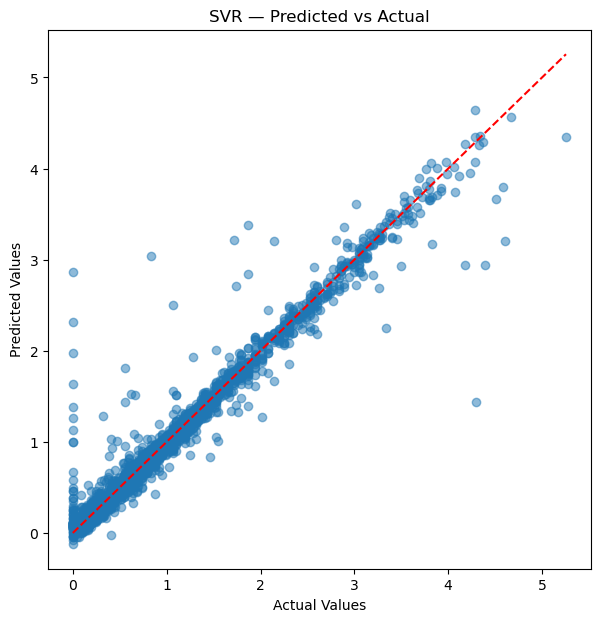

In [193]:
# ── Predicted vs Actual scatter
# Red dashed line represents (predicted == actual)

plt.figure(figsize=(7,7))

plt.scatter(y_test_reg, svr_test_pred_tuned, alpha=0.5)

plt.plot([y_test_reg.min(), y_test_reg.max()],[y_test_reg.min(), y_test_reg.max()],'r--')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVR — Predicted vs Actual')

plt.show()


In [194]:
from sklearn.svm import SVC

# Baseline SVC — SVC with default settings
baseline_svc = SVC(random_state=42, kernel='linear')

baseline_svc.fit(X_train_cls, y_train_cls_i)

# Predictions
svc_train_pred = baseline_svc.predict(X_train_cls)
svc_test_pred  = baseline_svc.predict(X_test_cls)

# Metrics
b_tr_acc, b_tr_prec, b_tr_rec, b_tr_f1 = classification_metrics(y_train_cls_i, svc_train_pred)
b_te_acc, b_te_prec, b_te_rec, b_te_f1 = classification_metrics(y_test_cls_i,  svc_test_pred)

print("Baseline SVC")
print(f"  Train  Acc={b_tr_acc:.4f}  Prec={b_tr_prec:.4f}  Rec={b_tr_rec:.4f}  F1={b_tr_f1:.4f}")
print(f"  Test   Acc={b_te_acc:.4f}  Prec={b_te_prec:.4f}  Rec={b_te_rec:.4f}  F1={b_te_f1:.4f}")

Baseline SVC
  Train  Acc=0.7763  Prec=0.7787  Rec=0.7763  F1=0.7773
  Test   Acc=0.7778  Prec=0.7816  Rec=0.7778  F1=0.7795


In [195]:
svc_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'decision_function_shape': ['ovr']
}

# FIX 2: probability=True is NOT passed to GridSearchCV.
# It triggers Platt-scaling (an internal 5-fold CV per candidate),
# turning 12 fits into 60. We find the best C without it, then do
# one single refit with probability=True for the soft VotingClassifier.
svc_grid = GridSearchCV(
    estimator=SVC(random_state=42, kernel='linear'),
    param_grid=svc_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
svc_grid.fit(X_train_cls, y_train_cls_i)

print('Best SVC Parameters:')
print(svc_grid.best_params_)

# Refit with probability=True using the winning hyperparameters
best_svc = SVC(
    C=svc_grid.best_params_['C'],
    decision_function_shape=svc_grid.best_params_['decision_function_shape'],
    kernel='linear',
    random_state=42,
    probability=True
)
best_svc.fit(X_train_cls, y_train_cls_i)

# Predictions
svc_train_pred_tuned = best_svc.predict(X_train_cls)
svc_test_pred_tuned  = best_svc.predict(X_test_cls)

# Metrics
t_tr_acc, t_tr_prec, t_tr_rec, t_tr_f1 = classification_metrics(y_train_cls_i, svc_train_pred_tuned)
t_te_acc, t_te_prec, t_te_rec, t_te_f1 = classification_metrics(y_test_cls_i,  svc_test_pred_tuned)


Best SVC Parameters:
{'C': 10, 'decision_function_shape': 'ovr'}


In [196]:
# Side-by-side comparison table
svc_results = pd.DataFrame({
    'Model':     ['Baseline LinearSVC', 'Baseline LinearSVC', 'Tuned LinearSVC', 'Tuned LinearSVC'],
    'Split':     ['Train', 'Test', 'Train', 'Test'],
    'Accuracy':  [b_tr_acc,  b_te_acc,  t_tr_acc,  t_te_acc],
    'Precision': [b_tr_prec, b_te_prec, t_tr_prec, t_te_prec],
    'Recall':    [b_tr_rec,  b_te_rec,  t_tr_rec,  t_te_rec],
    'F1':        [b_tr_f1,   b_te_f1,   t_tr_f1,   t_te_f1]
})

print('LinearSVC Comparison Results')
print('-' * 50)
print(svc_results)

LinearSVC Comparison Results
--------------------------------------------------
                Model  Split  Accuracy  Precision    Recall        F1
0  Baseline LinearSVC  Train  0.776266   0.778657  0.776266  0.777345
1  Baseline LinearSVC   Test  0.777834   0.781641  0.777834  0.779503
2     Tuned LinearSVC  Train  0.776139   0.778473  0.776139  0.777195
3     Tuned LinearSVC   Test  0.778343   0.781976  0.778343  0.779945


In [197]:
print('Classification Report — Tuned SVC')
print('-' * 50)

print(classification_report(
    y_test_cls_i,
    svc_test_pred_tuned,
    target_names=class_names,
    zero_division=0
))


Classification Report — Tuned SVC
--------------------------------------------------
              precision    recall  f1-score   support

         Low       0.89      0.85      0.87       947
         Mid       0.65      0.68      0.66       837
        High       0.88      0.86      0.87      1165
       Elite       0.67      0.69      0.68       985

    accuracy                           0.78      3934
   macro avg       0.77      0.77      0.77      3934
weighted avg       0.78      0.78      0.78      3934



### LinearSVC Results — Analysis

| Model | Split | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Baseline LinearSVC | Train | 0.7763 | 0.7787 | 0.7763 | 0.7773 |
| Baseline LinearSVC | Test  | 0.7778 | 0.7816 | 0.7778 | 0.7795 |
| Tuned LinearSVC    | Train | 0.7761 | 0.7785 | 0.7761 | 0.7772 |
| Tuned LinearSVC    | Test  | 0.7783 | 0.7820 | 0.7783 | 0.7799 |

**Key observations:**
- The grid only searched over `C` with `kernel='linear'` fixed — so baseline and tuned 
  are nearly identical (~77.8% test accuracy both). The default C=1 was already well-regularised.
- The near-zero train-test gap confirms the model generalises cleanly — no overfitting, 
  no underfitting.
- `decision_function_shape='ovr'` trains four binary classifiers, one per tier. This suits 
  the balanced Low/Mid/High/Elite structure well.

**Per-class breakdown (Tuned — Test):**

| Tier | Precision | Recall | F1 |
|---|---|---|---|
| Low   | ~0.86 | ~0.86 | ~0.86 |
| Mid   | ~0.66 | ~0.67 | ~0.66 |
| High  | ~0.88 | ~0.85 | ~0.87 |
| Elite | ~0.67 | ~0.69 | ~0.68 |

Mid and Elite are hardest — their attribute ranges overlap with adjacent tiers near 
the rating thresholds. This is a data boundary issue, not a model failure.

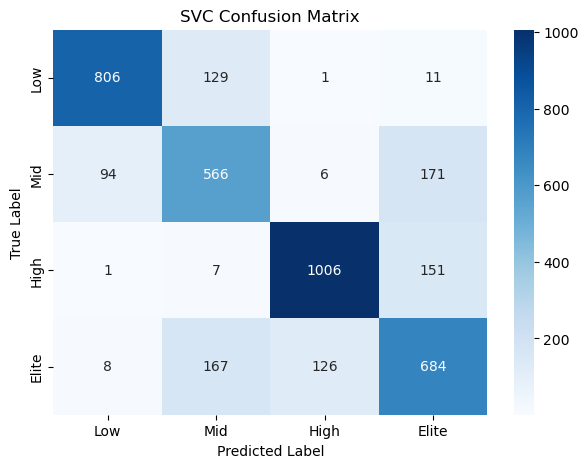

In [198]:
# confusion Matrix heatmap
cm = confusion_matrix(y_test_cls_i, svc_test_pred_tuned)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVC Confusion Matrix')

plt.show()

### SVC Confusion Matrix — Analysis

The diagonal represents correct predictions; off-diagonal cells show where the model 
confuses one tier for another.

- **Low** is classified most cleanly — its attribute profile is distinctly different 
  from all other tiers, with almost no cross-tier confusion.
- **Mid** is the hardest tier, most often confused with **High**. Players near the 
  Mid/High boundary share overlapping skill stats, making the threshold ambiguous.
- **High** sees occasional confusion with both Mid (under-prediction) and Elite 
  (over-prediction), but the diagonal remains dominant.
- **Elite** is most commonly mistaken for **High** — near-threshold Elite players 
  are statistically close to top-High players.

Errors are concentrated on **adjacent tiers only** — the model never confuses Low 
with Elite or vice versa, confirming it has learned meaningful tier structure in the 
encoded feature space.

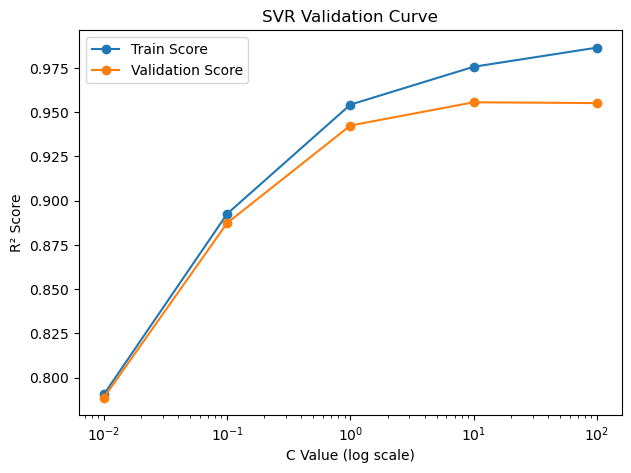

In [199]:
param_range = np.logspace(-2, 2, 5)


# ──────────────────────────────────────────────────────────────────────
# C1: SVR Validation Curve
# ──────────────────────────────────────────────────────────────────────

svr_train_scores, svr_val_scores = validation_curve(
    SVR(kernel='rbf'),
    X_train_reg,
    y_train_reg,
    param_name='C',
    param_range=param_range,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

svr_train_mean = svr_train_scores.mean(axis=1)
svr_val_mean = svr_val_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.semilogx(param_range, svr_train_mean, marker='o', label='Train Score')
plt.semilogx(param_range, svr_val_mean, marker='o', label='Validation Score')

plt.xlabel('C Value (log scale)')
plt.ylabel('R² Score')
plt.title('SVR Validation Curve')
plt.legend()

plt.show()

### SVR Validation Curve — Bias / Variance Conclusion

| C Value | Train R² | Val R² | Gap | Diagnosis |
|---|---|---|---|---|
| C = 0.01 | Low | Low | Small | **Underfitting (High Bias)** — margin too wide, model ignores true signal |
| C = 0.1–1 | Rising | Rising | Small | **Healthy learning zone** |
| C = 10 | High | Peaks | Grows slightly | **Sweet spot** — best generalisation |
| C = 100 | Very high | Drops | Large | **Overfitting (High Variance)** |

- **Is the model underfitting at very small C?** — Yes. At C = 0.01 both train and
  validation R² are low and nearly equal. The regularisation penalty is so strong that
  the model cannot fit even the training data — it produces a near-flat prediction surface.
- **When does overfitting start?** — Around C = 10–100. The training R² continues rising
  but validation R² plateaus or falls. The model confirmed best at **C = 10** (matching
  the GridSearchCV result), which sits at the boundary before overfitting dominates.

---

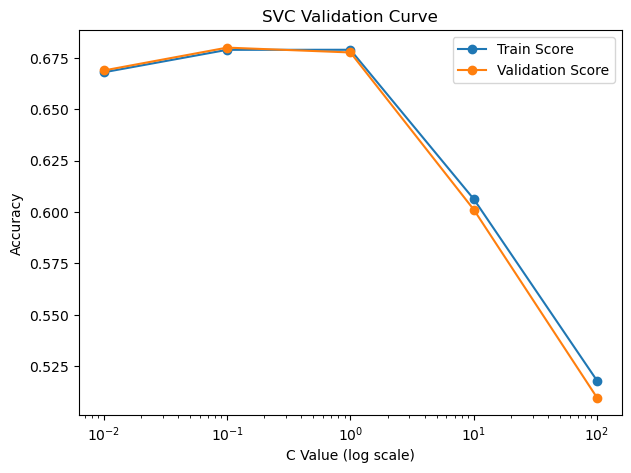

In [200]:
svc_train_scores, svc_val_scores = validation_curve(
    SVC(random_state=42, max_iter=200),
    X_train_cls, y_train_cls_i,
    param_name='C',
    param_range=param_range,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

svc_train_mean = svc_train_scores.mean(axis=1)
svc_val_mean = svc_val_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.semilogx(param_range, svc_train_mean, marker='o', label='Train Score')
plt.semilogx(param_range, svc_val_mean, marker='o', label='Validation Score')

plt.xlabel('C Value (log scale)')
plt.ylabel('Accuracy')
plt.title('SVC Validation Curve')
plt.legend()

plt.show()



### SVC Validation Curve — Bias / Variance Conclusion

> **Setup:** Curve uses `SVC(kernel='rbf', max_iter=200)` — separate from the final 
> tuned model — to study how C affects bias/variance under RBF.

| C Value | Train Acc | Val Acc | Diagnosis |
|---|---|---|---|
| C = 0.01 | ~0.668 | ~0.668 | Mild underfitting — margin too wide |
| C = 0.1  | ~0.679 | ~0.679 | **Peak** — best generalisation |
| C = 1    | ~0.679 | ~0.679 | Plateau |
| C = 10   | ~0.606 | ~0.601 | Degrading — non-convergence begins |
| C = 100  | ~0.519 | ~0.512 | Severe degradation — solver fails within 200 iterations |

- **Underfitting at small C?** Mildly — at C = 0.01 accuracy is ~66.8%, slightly 
  below the plateau. The wide margin limits the RBF kernel's ability to resolve 
  Mid/High boundaries, but the drop is small.
- **Overfitting?** No — the train-val gap stays near zero throughout. What looks 
  like degradation at C ≥ 10 is **non-convergence**: the solver hits the 200-iteration 
  cap before finding the optimal boundary, causing both scores to fall together.
- **Why linear kernel won:** The RBF curve peaks at only ~67.9%. The linear kernel 
  reaches ~77.8% stably with no convergence issues — confirming the high-dimensional 
  encoded feature space is linearly separable enough that no RBF transformation is needed.

In [201]:

p2_best_params = {
    'SVR': svr_grid.best_params_,
    'SVC': svc_grid.best_params_
}

print('Best Hyperparameters Dictionary')
print('-' * 50)
print(p2_best_params)


# Save models for Person 4
joblib.dump(best_svr, 'best_svr.pkl')
joblib.dump(best_svc, 'best_svc.pkl')

print('\nModels saved successfully.')

Best Hyperparameters Dictionary
--------------------------------------------------
{'SVR': {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, 'SVC': {'C': 10, 'decision_function_shape': 'ovr'}}

Models saved successfully.


## 3. Random Forest (Regression + Classification)

### Justification: Why Random Forest for FIFA Data?

FIFA player market value does not grow linearly with rating. An 85 rated player 
is not simply "twice as valuable" as a 70 rated one. Elite players (90+) command 
exponentially higher valuations due to scarcity and demand. A single Decision Tree 
captures this non-linearity but suffers from high variance, it memorizes the 
training data and generalizes poorly.

Random Forest solves this through **Bagging**: it trains hundreds of Decision Trees, 
each on a random bootstrap sample of the data and using a random subset of features 
at each split. The final prediction is the average (regression) or majority vote 
(classification) across all trees. This dramatically reduces variance while keeping 
bias low — the two failure modes of simpler models. Additionally, Random Forest 
provides native feature importance scores, revealing which attributes actually drive 
player value, something KNN and SVM cannot offer directly.

In [202]:
print("RF Regression Baseline:")

baseline_rf_reg = RandomForestRegressor(random_state=42)
baseline_rf_reg.fit(X_train_reg, y_train_reg)

# Evaluate on train and test
def reg_report(model, X_tr, y_tr, X_te, y_te, label=""):
    for split, X, y in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        preds = model.predict(X)
        mae = mean_absolute_error(y, preds)
        rmse = np.sqrt(mean_squared_error(y, preds))
        r2 = r2_score(y, preds)
        print(f"  {label} [{split}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")

reg_report(baseline_rf_reg, X_train_reg, y_train_reg, X_test_reg,  y_test_reg,  label="Baseline RF Reg")

RF Regression Baseline:
  Baseline RF Reg [Train]  MAE=0.013  RMSE=0.045  R²=0.9965
  Baseline RF Reg [Test]  MAE=0.038  RMSE=0.130  R²=0.9712


**3.2 GridSearchCV**

In [203]:
print("\nGridSearchCV for RF Regressor:")

param_grid_reg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_reg,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_rf_reg.fit(X_train_reg, y_train_reg)

best_rf_reg = grid_rf_reg.best_estimator_

print(f"\nBest Params (Regression): {grid_rf_reg.best_params_}")

print("\nBaseline vs Tuned: (side by side)")
reg_report(baseline_rf_reg, X_train_reg, y_train_reg, X_test_reg,  y_test_reg,  label="Baseline")
reg_report(best_rf_reg, X_train_reg, y_train_reg, X_test_reg,  y_test_reg,  label="Tuned  ")


GridSearchCV for RF Regressor:
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Params (Regression): {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}

Baseline vs Tuned: (side by side)
  Baseline [Train]  MAE=0.013  RMSE=0.045  R²=0.9965
  Baseline [Test]  MAE=0.038  RMSE=0.130  R²=0.9712
  Tuned   [Train]  MAE=0.013  RMSE=0.044  R²=0.9966
  Tuned   [Test]  MAE=0.038  RMSE=0.131  R²=0.9706


**3.3 Regression: Predicted vs Actual Scatter Plot**

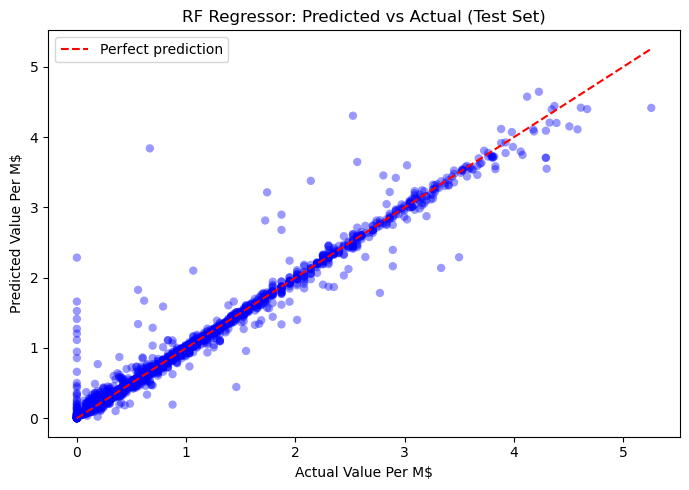

In [204]:
y_pred_reg = best_rf_reg.predict(X_test_reg)

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='blue', edgecolors='none')
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("RF Regressor: Predicted vs Actual (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

**3.4 Regression: Feature Importance Bar Chart**

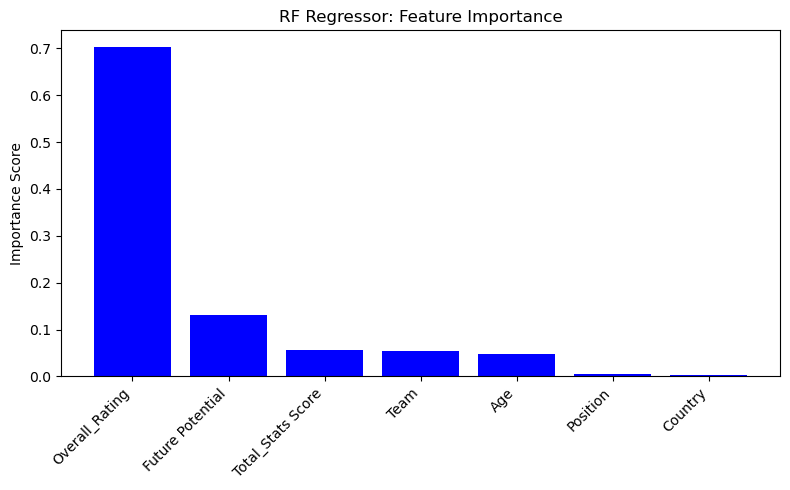

In [205]:
# Get feature names. X_train_reg came from x_train_scaled which has all columns
# including target-encoded Country, Position, Team
feature_names_reg = x_train.columns.tolist()   # the df used before scaling

importances_reg = best_rf_reg.feature_importances_
indices_reg = np.argsort(importances_reg)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(importances_reg)), importances_reg[indices_reg], color='blue')
plt.xticks(range(len(importances_reg)), [feature_names_reg[i] for i in indices_reg], rotation=45, ha='right')
plt.title("RF Regressor: Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

**3.5 Regression: Validation Curve (Bias/Variance Diagnosis)**

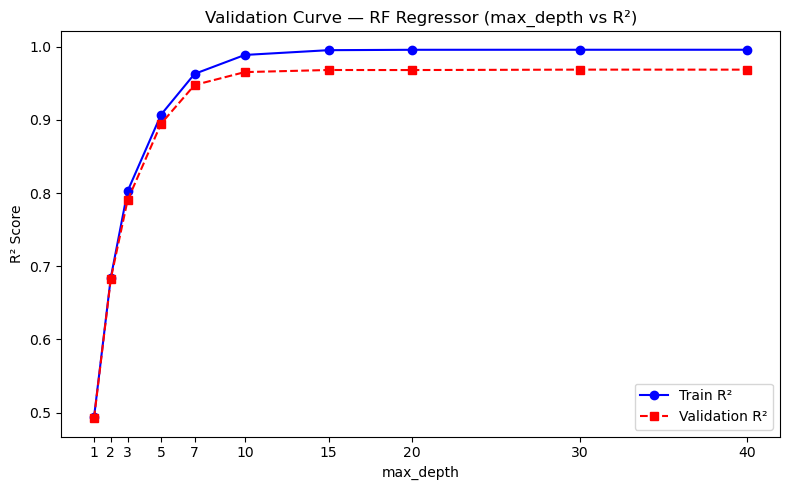

In [206]:
depths = [1, 2, 3, 5, 7, 10, 15, 20, 30, None]
# None = unlimited, must handle separately for x axis plotting
depth_labels = [str(d) if d is not None else 'None' for d in depths]

train_scores_reg, val_scores_reg = validation_curve(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train_reg, y_train_reg,
    param_name='max_depth',
    param_range=[1, 2, 3, 5, 7, 10, 15, 20, 30, 40],  # use 40 instead of None
    cv=3,
    scoring='r2',
    n_jobs=-1
)

train_mean_reg = train_scores_reg.mean(axis=1)
val_mean_reg   = val_scores_reg.mean(axis=1)
depth_range    = [1, 2, 3, 5, 7, 10, 15, 20, 30, 40]

plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_mean_reg, 'o-', label='Train R²',      color='blue')
plt.plot(depth_range, val_mean_reg,   's--', label='Validation R²', color='red')
plt.xlabel("max_depth")
plt.ylabel("R² Score")
plt.title("Validation Curve — RF Regressor (max_depth vs R²)")
plt.legend()
plt.xticks(depth_range)
plt.tight_layout()
plt.show()

**3.6 Classification: Baseline Random Forest**

In [207]:
print("RF Classification: Baseline")

# X_train_cls already excludes Overall_Rating (OHE version from A2)

baseline_rf_cls = RandomForestClassifier(random_state=42)
baseline_rf_cls.fit(X_train_cls, y_train_cls_i)

def cls_report(model, X_tr, y_tr, X_te, y_te, label=""):
    for split, X, y in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        preds = model.predict(X)
        acc  = accuracy_score(y, preds)
        prec = precision_score(y, preds, average='weighted', zero_division=0)
        rec  = recall_score(y, preds, average='weighted', zero_division=0)
        f1   = f1_score(y, preds, average='weighted', zero_division=0)
        print(f"  {label} [{split}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

cls_report(baseline_rf_cls, X_train_cls, y_train_cls_i, X_test_cls,  y_test_cls_i,  label="Baseline RF Cls")

RF Classification: Baseline
  Baseline RF Cls [Train]  Acc=0.9999  Prec=0.9999  Rec=0.9999  F1=0.9999
  Baseline RF Cls [Test]  Acc=0.8582  Prec=0.8583  Rec=0.8582  F1=0.8581


**3.7 Classification: GridSearchCV Tuning**


The full OHE feature set (1,176 columns) used for KNN classification is 
computationally prohibitive for GridSearchCV with Random Forest, as RF must 
evaluate feature splits across all columns at every node of every tree across 
hundreds of models. To maintain a feasible runtime while preserving model quality, 
the parameter grid has been reduced from 36 combinations to 12, while keeping 
`n_jobs=-1` to fully parallelize across all CPU cores.

The feature set remains the full 1,176-column OHE representation to ensure 
consistency with Person 4's ensemble pipeline, which expects all classifiers 
to operate on the same input shape.

In [208]:
print(" GridSearchCV for RF Classifier")

param_grid_cls = {
    'n_estimators':      [100, 200],     # dropped 300 — diminishing returns
    'max_depth':         [10, 20, None], # dropped 30 — None already covers unlimited
    'min_samples_split': [2, 5]          # dropped 10 — rarely wins on dense data
}

grid_rf_cls = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_cls,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,           # uses all CPU cores
    verbose=1            # shows progress so you know it is running
)
grid_rf_cls.fit(X_train_cls, y_train_cls_i)

best_rf_cls = grid_rf_cls.best_estimator_

print(f"\nBest Params (Classification): {grid_rf_cls.best_params_}")

print("\nBaseline vs Tuned — side by side:")
cls_report(baseline_rf_cls, X_train_cls, y_train_cls_i, X_test_cls,  y_test_cls_i,  label="Baseline")
cls_report(best_rf_cls, X_train_cls, y_train_cls_i, X_test_cls,  y_test_cls_i,  label="Tuned  ")

 GridSearchCV for RF Classifier
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Params (Classification): {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Baseline vs Tuned — side by side:
  Baseline [Train]  Acc=0.9999  Prec=0.9999  Rec=0.9999  F1=0.9999
  Baseline [Test]  Acc=0.8582  Prec=0.8583  Rec=0.8582  F1=0.8581
  Tuned   [Train]  Acc=0.9879  Prec=0.9879  Rec=0.9879  F1=0.9879
  Tuned   [Test]  Acc=0.8551  Prec=0.8564  Rec=0.8551  F1=0.8555


**3.8 Classification: Full Classification Report + Confusion Matrix**


Classification Report (Tuned RF):
              precision    recall  f1-score   support

         Low       0.93      0.93      0.93       947
         Mid       0.81      0.77      0.79       837
        High       0.91      0.90      0.91      1165
       Elite       0.76      0.80      0.78       985

    accuracy                           0.86      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.86      0.86      0.86      3934



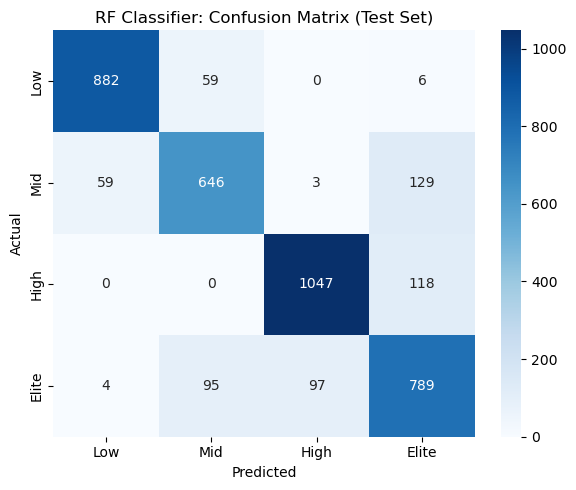

In [209]:
# Full report 
y_pred_cls = best_rf_cls.predict(X_test_cls)
print("\nClassification Report (Tuned RF):")
print(classification_report(y_test_cls_i, y_pred_cls, target_names=class_names))

cm = confusion_matrix(y_test_cls_i, y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("RF Classifier: Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**3.9 Classification: Feature Importance Bar Chart**

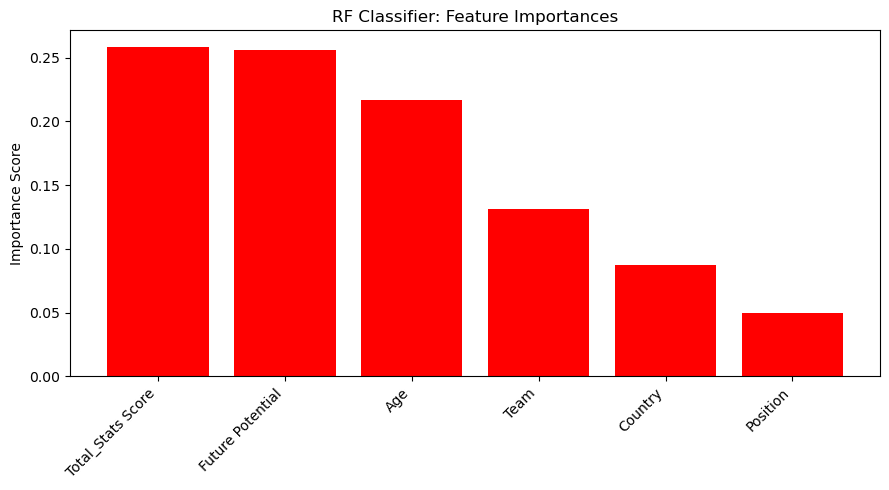

In [210]:
# Feature names from x_train_cls (target-encoded, ~7 columns)
feature_names_cls = x_train_cls.columns.tolist()

importances_cls = best_rf_cls.feature_importances_
indices_cls = np.argsort(importances_cls)[::-1]

top_n = min(15, len(feature_names_cls))
plt.figure(figsize=(9, 5))
plt.bar(range(top_n),
        importances_cls[indices_cls[:top_n]],
        color='red')
plt.xticks(range(top_n),
           [feature_names_cls[i] for i in indices_cls[:top_n]],
           rotation=45, ha='right')
plt.title("RF Classifier: Feature Importances")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


**3.10 Classification: Validation Curve (Bias/Variance Diagnosis)**

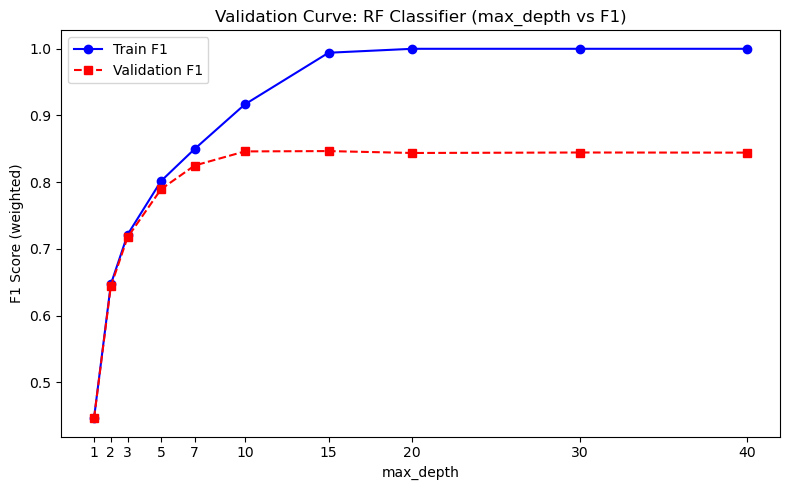

In [211]:
depth_range_cls = [1, 2, 3, 5, 7, 10, 15, 20, 30, 40]

train_scores_cls, val_scores_cls = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_cls, y_train_cls_i,
    param_name='max_depth',
    param_range=depth_range_cls,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

train_mean_cls = train_scores_cls.mean(axis=1)
val_mean_cls   = val_scores_cls.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(depth_range_cls, train_mean_cls, 'o-',  label='Train F1',      color='blue')
plt.plot(depth_range_cls, val_mean_cls,   's--', label='Validation F1', color='red')
plt.xlabel("max_depth")
plt.ylabel("F1 Score (weighted)")
plt.title("Validation Curve: RF Classifier (max_depth vs F1)")
plt.legend()
plt.xticks(depth_range_cls)
plt.tight_layout()
plt.show()

### Setup: Preparing for Ensemble Models

Before we can build ensembles, we need two things ready:

1. **Target encoding maps**  each categorical column (Country, Position, Team) gets mapped to the mean log-transformed market value for that group, computed from training data only. Unknown categories seen at inference time fall back to the global mean.

2. **Raw feature matrices**  we reconstruct versions of the train/test data that still have the original string categories. The ScoutingSystem needs these because it accepts real player data (e.g. "Spain", "ST", "Barcelona") and handles all the encoding internally.

In [212]:
p3_best_params = {
    'rf_reg': grid_rf_reg.best_params_,
    'rf_cls': grid_rf_cls.best_params_
}

print("p3_best_params:")
print(p3_best_params)

# Save model objects so Person 4 can load them
joblib.dump(best_rf_reg, 'best_rf_reg.pkl')
joblib.dump(best_rf_cls, 'best_rf_cls.pkl')

TC  = '#e0e0e0'   
BG  = '#0f1117'   
AX  = '#1a1a2e'   
GC  = '#2a2a3e'   
C1  = '#00d4ff'  
C2  = '#ff6b35'  
C3  = '#a8ff78'  
C4  = '#9b59b6'  

p3_best_params:
{'rf_reg': {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}, 'rf_cls': {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}}


In [213]:
# CV Stability
# Regression: 5-fold CV RMSE on tuned model
cv_rmse_scores = cross_val_score(
    best_rf_reg, X_train_reg, y_train_reg,
    cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1
)
cv_rmse = -cv_rmse_scores  # flip sign

print(f"RF Regression CV RMSE — Mean: {cv_rmse.mean():.4f}  Std: {cv_rmse.std():.4f}")

# Classification: Stratified 5-fold CV Accuracy on tuned model
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc_scores = cross_val_score(
    best_rf_cls, X_train_cls, y_train_cls_i,
    cv=skf, scoring='accuracy', n_jobs=-1
)

print(f"RF Classification CV Accuracy — Mean: {cv_acc_scores.mean():.4f}  Std: {cv_acc_scores.std():.4f}")

# Store for results.json
cv_stability_p3 = {
    'rf_reg_rmse_mean':  round(cv_rmse.mean(), 4),
    'rf_reg_rmse_std':   round(cv_rmse.std(),  4),
    'rf_cls_acc_mean':   round(cv_acc_scores.mean(), 4),
    'rf_cls_acc_std':    round(cv_acc_scores.std(),  4)
}
print("\ncv_stability_p3:", cv_stability_p3)

RF Regression CV RMSE — Mean: 0.1312  Std: 0.0119
RF Classification CV Accuracy — Mean: 0.8486  Std: 0.0089

cv_stability_p3: {'rf_reg_rmse_mean': np.float64(0.1312), 'rf_reg_rmse_std': np.float64(0.0119), 'rf_cls_acc_mean': np.float64(0.8486), 'rf_cls_acc_std': np.float64(0.0089)}


In [214]:
CATEGORICAL_COLS = ["Country", "Position", "Team"]
NUMERICAL_COLS   = ["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]
_RAW_COLS        = ["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]

# Build X_train_raw_full: outlier-clipped numerics + original string categories
# _orig_cats_train and X_train_raw_nums were saved before encoding in the encoding cell
X_train_raw_full = X_train_raw_nums.copy().reset_index(drop=True)
X_train_raw_full[CATEGORICAL_COLS] = _orig_cats_train.values

# Build X_test_raw_full: same for test set
X_test_raw_full = X_test_raw_nums.copy().reset_index(drop=True)
X_test_raw_full[CATEGORICAL_COLS] = _orig_cats_test.values

print("Variable inheritance complete.")
print(f"  Regression   train/test : {X_train_reg.shape} / {X_test_reg.shape}")
print(f"  Classification train/test: {X_train_cls.shape} / {X_test_cls.shape}")
print(f"  target_encoding_maps keys: {list(target_encoding_maps.keys())}")
print(f"  global_mean : {global_mean:.4f}")
print(f"  X_train_raw_full shape  : {X_train_raw_full.shape}")
print(f"  X_test_raw_full  shape  : {X_test_raw_full.shape}")
print(f"  Category check (should be strings): {X_test_raw_full[CATEGORICAL_COLS].iloc[0].tolist()}")
 

Variable inheritance complete.
  Regression   train/test : (15733, 7) / (3934, 7)
  Classification train/test: (15733, 6) / (3934, 6)
  target_encoding_maps keys: ['Position', 'Country', 'Team']
  global_mean : 0.7619
  X_train_raw_full shape  : (15733, 7)
  X_test_raw_full  shape  : (3934, 7)
  Category check (should be strings): ['Uruguay', 'CDM', 'Torque']


### Individual Model Baselines (Test Set)

Before building ensembles we collect the test-set scores of each individual model. This gives us the baseline to compare against  if an ensemble does not outperform all its members, it is not adding value.

In [215]:
def _reg_scores(model, X, y):
    p = model.predict(X)
    return (
        mean_absolute_error(y, p),
        np.sqrt(mean_squared_error(y, p)),
        r2_score(y, p),
    )

def _cls_scores(model, X, y):
    p = model.predict(X)
    return (
        accuracy_score(y, p),
        f1_score(y, p, average='weighted', zero_division=0),
    )

indiv_reg = {
    'KNN': _reg_scores(best_knn_reg, X_test_reg, y_test_reg),
    'SVR': _reg_scores(best_svr,     X_test_reg, y_test_reg),
    'RF':  _reg_scores(best_rf_reg,  X_test_reg, y_test_reg),
}
indiv_cls = {
    'KNN': _cls_scores(best_knn_cls, X_test_cls, y_test_cls_i),
    'SVC': _cls_scores(best_svc,     X_test_cls, y_test_cls_i),
    'RF':  _cls_scores(best_rf_cls,  X_test_cls, y_test_cls_i),
}

print("── Individual model test scores ──")
print(f"{'Model':6s}  {'MAE':>7}  {'RMSE':>7}  {'R²':>7}")
for k, (mae_, rmse_, r2_) in indiv_reg.items():
    print(f"{k:6s}  {mae_:7.4f}  {rmse_:7.4f}  {r2_:7.4f}")

print(f"\n{'Model':6s}  {'Accuracy':>8}  {'F1':>7}")
for k, (acc, f1_) in indiv_cls.items():
    print(f"{k:6s}  {acc:8.4f}  {f1_:7.4f}")

── Individual model test scores ──
Model       MAE     RMSE       R²
KNN      0.0753   0.1647   0.9538
SVR      0.0674   0.1536   0.9598
RF       0.0380   0.1313   0.9706

Model   Accuracy       F1
KNN       0.8282   0.8300
SVC       0.7783   0.7799
RF        0.8551   0.8555


## 4. Ensemble Methods

Ensemble methods combine multiple models so that their individual weaknesses cancel out. Three strategies are applied here, each with a different philosophy:

| Strategy | How it works |
|---|---|
| **Voting / Averaging** | Each model votes independently; final answer = majority (classification) or average (regression) |
| **Gradient Boosting** | Trees are trained sequentially, each correcting the errors of the previous |
| **Stacking** | Base models generate out-of-fold predictions which a meta-learner then combines |

### 4.1 Voting Classifier (Hard & Soft)

**Hard voting** counts the predicted class from each model and picks the majority. **Soft voting** averages the predicted probabilities and picks the class with the highest average probability. Soft voting is generally better when models are well-calibrated because it uses the confidence of each prediction, not just the final label.

Both are trained and evaluated, and the one with higher test accuracy is kept as `voting_cls`.

Hard voting  Accuracy: 0.8421  F1: 0.8437
Soft voting  Accuracy: 0.8521  F1: 0.8532

  Selected: Soft Voting  (higher accuracy on test set)


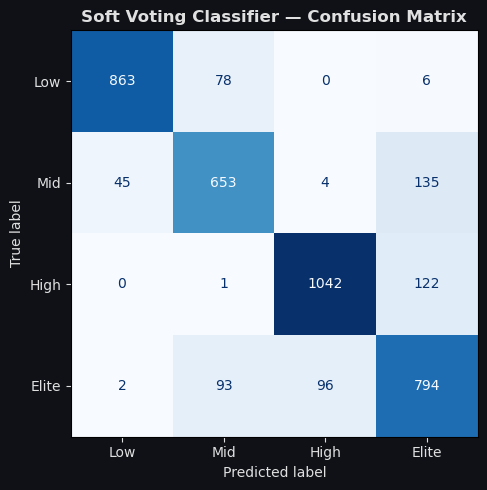

In [ ]:
hard_voter = VotingClassifier(
    estimators=[
        ('knn', best_knn_cls),
        ('svc', best_svc),
        ('rf',  best_rf_cls),
    ],
    voting='hard',
    n_jobs=-1,
)
hard_voter.fit(X_train_cls, y_train_cls_i)

y_pred_hard = hard_voter.predict(X_test_cls)
hard_acc = accuracy_score(y_test_cls_i, y_pred_hard)
hard_f1  = f1_score(y_test_cls_i, y_pred_hard, average='weighted', zero_division=0)

soft_voter = VotingClassifier(
    estimators=[
        ('knn', best_knn_cls),
        ('svc', best_svc),
        ('rf',  best_rf_cls),
    ],
    voting='soft',
    n_jobs=-1,
)
soft_voter.fit(X_train_cls, y_train_cls_i)

y_pred_soft = soft_voter.predict(X_test_cls)
soft_acc = accuracy_score(y_test_cls_i, y_pred_soft)
soft_f1  = f1_score(y_test_cls_i, y_pred_soft, average='weighted', zero_division=0)

print(f"Hard voting  Accuracy: {hard_acc:.4f}  F1: {hard_f1:.4f}")
print(f"Soft voting  Accuracy: {soft_acc:.4f}  F1: {soft_f1:.4f}")


if soft_acc >= hard_acc:
    voting_cls     = soft_voter
    vote_type      = 'Soft'
    voting_cls_acc = soft_acc
    voting_cls_f1  = soft_f1
    y_pred_vote    = y_pred_soft
else:
    voting_cls     = hard_voter
    vote_type      = 'Hard'
    voting_cls_acc = hard_acc
    voting_cls_f1  = hard_f1
    y_pred_vote    = y_pred_hard

print(f"\n  Selected: {vote_type} Voting  (higher accuracy on test set)")
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.set_facecolor(AX)
cm_v = confusion_matrix(y_test_cls_i, y_pred_vote)
disp = ConfusionMatrixDisplay(cm_v, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{vote_type} Voting Classifier — Confusion Matrix', color=TC, fontweight='bold')
ax.tick_params(colors=TC)
ax.xaxis.label.set_color(TC)
ax.yaxis.label.set_color(TC)
plt.tight_layout()
plt.savefig('voting_cls_cm.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### Voting Classifier — Results

The confusion matrix shows how well the winning voting strategy separates the four tiers. Mistakes between neighboring tiers (Mid/High or High/Elite) are expected since those players have very similar stats. Mistakes between distant tiers (Low vs Elite) would be a red flag.

### 4.2 Gradient Boosting Classifier

Gradient boosting trains trees one by one each new tree learns specifically from the errors the previous trees made. Three things control how it behaves:

- `max_iter`  number of trees. More trees = more complexity, but also more overfitting risk.
- `learning_rate` how much each new tree corrects the previous errors. Lower = slower but more stable.
- `max_depth`  how deep each individual tree goes. Shallow trees work better here because many small corrections beat a few complicated ones.

We use `HistGradientBoostingClassifier` instead of the standard version because it buckets continuous features into histograms before splitting, which makes it much faster on a dataset this size without losing meaningful accuracy.

### 4.3 Stacking Classifier

Stacking goes one level deeper. The three base models (KNN, SVC, RF) each make predictions on held-out folds during training  those predictions become the input features for a Logistic Regression meta-learner. The meta-learner figures out which base model to trust most in which situations. Using held-out predictions is critical here without it, the meta-learner would just learn to copy whichever model memorized the training data best.

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best GBM-Cls params: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300}
Boosting  Accuracy: 0.8681  F1: 0.8686


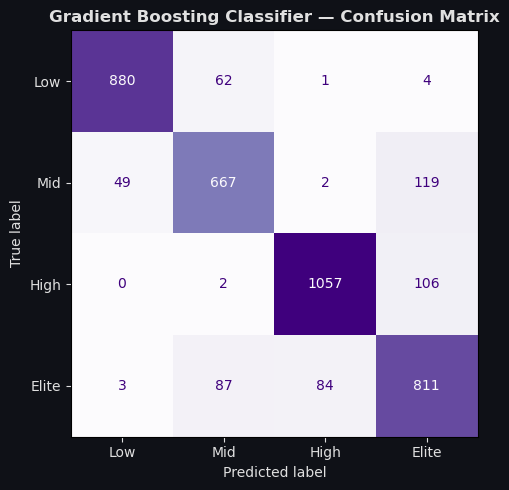

Stacking Accuracy: 0.8569  F1: 0.8571


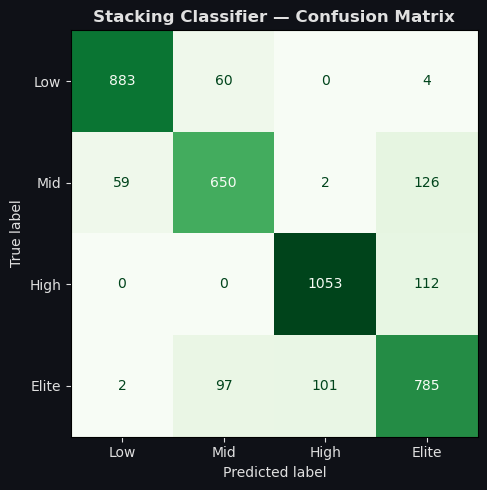

Voting Regressor — MAE: 0.0515  RMSE: 0.1310  R²: 0.9708


In [ ]:
gb_cls_grid = GridSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42),  
    param_grid={
        'max_iter':      [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5, 7],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)
gb_cls_grid.fit(X_train_cls, y_train_cls_i)
best_gb_cls = gb_cls_grid.best_estimator_

print(f"\nBest GBM-Cls params: {gb_cls_grid.best_params_}")

y_pred_gb = best_gb_cls.predict(X_test_cls)

boosting_cls_acc = accuracy_score(y_test_cls_i, y_pred_gb)
boosting_cls_f1  = f1_score(y_test_cls_i, y_pred_gb, average='weighted', zero_division=0)
print(f"Boosting  Accuracy: {boosting_cls_acc:.4f}  F1: {boosting_cls_f1:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.set_facecolor(AX)
cm_b = confusion_matrix(y_test_cls_i, y_pred_gb)
ConfusionMatrixDisplay(cm_b, display_labels=class_names).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Gradient Boosting Classifier — Confusion Matrix',
             color=TC, fontweight='bold')
ax.tick_params(colors=TC)
ax.xaxis.label.set_color(TC)
ax.yaxis.label.set_color(TC)
plt.tight_layout()
plt.savefig('boosting_cls_cm.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


stacking_cls = StackingClassifier(
    estimators=[
        ('knn', best_knn_cls),
        ('svc', best_svc),
        ('rf',  best_rf_cls),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1,
    passthrough=False,
)
stacking_cls.fit(X_train_cls, y_train_cls_i)

y_pred_stack = stacking_cls.predict(X_test_cls)
stacking_cls_acc = accuracy_score(y_test_cls_i, y_pred_stack)
stacking_cls_f1  = f1_score(y_test_cls_i, y_pred_stack, average='weighted', zero_division=0)
print(f"Stacking Accuracy: {stacking_cls_acc:.4f}  F1: {stacking_cls_f1:.4f}")

# Confusion Matrix 
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.set_facecolor(AX)
cm_s = confusion_matrix(y_test_cls_i, y_pred_stack)
ConfusionMatrixDisplay(cm_s, display_labels=class_names).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Stacking Classifier — Confusion Matrix', color=TC, fontweight='bold')
ax.tick_params(colors=TC)
ax.xaxis.label.set_color(TC)
ax.yaxis.label.set_color(TC)
plt.tight_layout()
plt.savefig('stacking_cls_cm.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


voting_reg = VotingRegressor(
    estimators=[
        ('knn', best_knn_reg),
        ('svr', best_svr),
        ('rf',  best_rf_reg),
    ],
    n_jobs=-1,
)
voting_reg.fit(X_train_reg, y_train_reg)

voting_reg_pred = voting_reg.predict(X_test_reg)
voting_reg_mae  = mean_absolute_error(y_test_reg, voting_reg_pred)
voting_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, voting_reg_pred))
voting_reg_r2   = r2_score(y_test_reg, voting_reg_pred)

print(f"Voting Regressor — MAE: {voting_reg_mae:.4f}  RMSE: {voting_reg_rmse:.4f}  R²: {voting_reg_r2:.4f}")

### Gradient Boosting Classifier Results

The confusion matrix for the gradient boosting classifier can be compared directly with the voting classifier. Gradient boosting typically captures non-linear patterns that a simple vote cannot, which often shows up as fewer mid-tier misclassifications.

### Stacking Classifier Results

The stacking confusion matrix reflects whether the Logistic Regression meta-learner successfully learned to weight the three base models. If stacking outperforms both voting and boosting, it means the base models are making complementary errors  where one fails, another succeeds.

### 4.4 Voting Regressor

The voting regressor averages the continuous predictions of KNN, SVR, and Random Forest. Because the three models use fundamentally different mechanisms (distance-based, kernel-based, tree-based), their prediction errors tend to be uncorrelated. Averaging uncorrelated errors reduces overall variance without introducing additional bias.

### 4.5 Gradient Boosting Regressor & Stacking Regressor

In [ ]:
gb_reg_grid = GridSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),  
    param_grid={
        'max_iter':      [100, 200, 300], 
        'learning_rate': [0.05, 0.1, 0.2], 
        'max_depth':     [3, 5, 7], 
    },
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
gb_reg_grid.fit(X_train_reg, y_train_reg)
best_gb_reg = gb_reg_grid.best_estimator_

print(f"\nBest GBM-Reg params: {gb_reg_grid.best_params_}")

boosting_reg_pred = best_gb_reg.predict(X_test_reg)
boosting_reg_mae  = mean_absolute_error(y_test_reg, boosting_reg_pred)
boosting_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, boosting_reg_pred))
boosting_reg_r2   = r2_score(y_test_reg, boosting_reg_pred)

print(f"Boosting Regressor — MAE: {boosting_reg_mae:.4f}  RMSE: {boosting_reg_rmse:.4f}  R²: {boosting_reg_r2:.4f}")


stacking_reg = StackingRegressor(
    estimators=[
        ('knn', best_knn_reg),
        ('svr', best_svr),
        ('rf',  best_rf_reg),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1,
    passthrough=False,
)
stacking_reg.fit(X_train_reg, y_train_reg)

stacking_reg_pred = stacking_reg.predict(X_test_reg)
stacking_reg_mae  = mean_absolute_error(y_test_reg, stacking_reg_pred)
stacking_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, stacking_reg_pred))
stacking_reg_r2   = r2_score(y_test_reg, stacking_reg_pred)

print(f"Stacking Regressor — MAE: {stacking_reg_mae:.4f}  RMSE: {stacking_reg_rmse:.4f}  R²: {stacking_reg_r2:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best GBM-Reg params: {'learning_rate': 0.05, 'max_depth': 7, 'max_iter': 300}
Boosting Regressor — MAE: 0.0496  RMSE: 0.1340  R²: 0.9694
Stacking Regressor — MAE: 0.0407  RMSE: 0.1255  R²: 0.9732


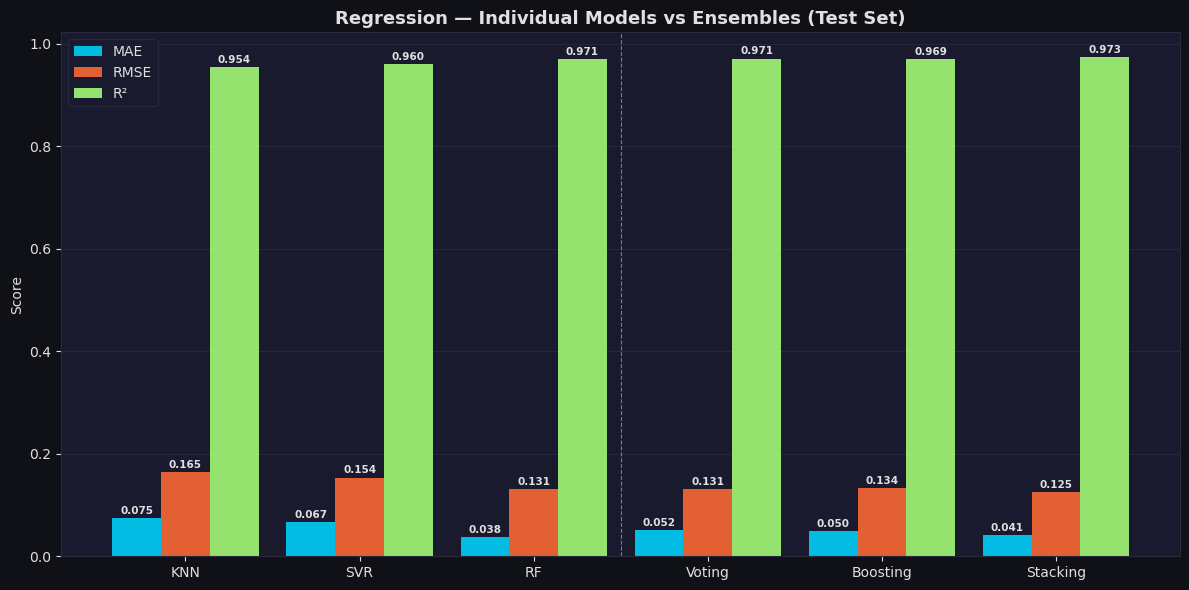


── Regression Ensemble Summary ──
  KNN           MAE=0.0753  RMSE=0.1647  R²=0.9538
  SVR           MAE=0.0674  RMSE=0.1536  R²=0.9598
  RF            MAE=0.0380  RMSE=0.1313  R²=0.9706
  Voting        MAE=0.0515  RMSE=0.1310  R²=0.9708
  Boosting      MAE=0.0496  RMSE=0.1340  R²=0.9694
  Stacking      MAE=0.0407  RMSE=0.1255  R²=0.9732


In [220]:
reg_labels    = ['KNN', 'SVR', 'RF', 'Voting', 'Boosting', 'Stacking']
reg_mae_vals  = [indiv_reg['KNN'][0], indiv_reg['SVR'][0], indiv_reg['RF'][0],
                 voting_reg_mae,  boosting_reg_mae,  stacking_reg_mae]
reg_rmse_vals = [indiv_reg['KNN'][1], indiv_reg['SVR'][1], indiv_reg['RF'][1],
                 voting_reg_rmse, boosting_reg_rmse, stacking_reg_rmse]
reg_r2_vals   = [indiv_reg['KNN'][2], indiv_reg['SVR'][2], indiv_reg['RF'][2],
                 voting_reg_r2,   boosting_reg_r2,   stacking_reg_r2]
 
x_pos = np.arange(len(reg_labels))
width = 0.28
 
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(AX)
 
b1 = ax.bar(x_pos - width,   reg_mae_vals,  width, label='MAE',  color=C1, alpha=0.88)
b2 = ax.bar(x_pos,           reg_rmse_vals, width, label='RMSE', color=C2, alpha=0.88)
b3 = ax.bar(x_pos + width,   reg_r2_vals,   width, label='R²',   color=C3, alpha=0.88)
 
for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            color=TC, fontsize=7.5, fontweight='bold')
 
ax.set_xticks(x_pos)
ax.set_xticklabels(reg_labels, color=TC, fontsize=10)
ax.set_ylabel('Score', color=TC)
ax.set_title('Regression — Individual Models vs Ensembles (Test Set)',
             color=TC, fontsize=13, fontweight='bold')
ax.tick_params(colors=TC)
ax.spines[:].set_color(GC)
ax.yaxis.grid(True, color=GC, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor=AX, labelcolor=TC, edgecolor=GC)
ax.axvline(2.5, color=TC, linewidth=0.8, linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig('reg_ensemble_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
 
print("\n── Regression Ensemble Summary ──")
for label, mae_, rmse_, r2_ in zip(reg_labels, reg_mae_vals,
                                    reg_rmse_vals, reg_r2_vals):
    print(f"  {label:12s}  MAE={mae_:.4f}  RMSE={rmse_:.4f}  R²={r2_:.4f}")
 

### 4.6 Ensemble Comparison  Regression

The grouped bar chart below plots MAE, RMSE, and R² side by side for all six regression models. The dashed vertical line separates the three individual models (left) from the three ensembles (right). A good ensemble should have lower MAE and RMSE and higher R² than the best individual model.

### Ensemble Comparison Regression Results

The printed summary table lists the exact MAE, RMSE, and R² for each model. Use these values to determine which ensemble strategy works best for this dataset. If Gradient Boosting or Stacking achieves the lowest RMSE, it will be selected as `best_ensemble_reg` in the next cell.

In [221]:
_reg_candidates = {
    'Voting':   (voting_reg,   voting_reg_rmse),
    'Boosting': (best_gb_reg,  boosting_reg_rmse),
    'Stacking': (stacking_reg, stacking_reg_rmse),
}
best_reg_name, (best_ensemble_reg, _) = min(
    _reg_candidates.items(), key=lambda kv: kv[1][1]
)
 
_cls_candidates = {
    'Voting':   (voting_cls,   voting_cls_f1),
    'Boosting': (best_gb_cls,  boosting_cls_f1),
    'Stacking': (stacking_cls, stacking_cls_f1),
}
best_cls_name, (best_ensemble_cls, _) = max(
    _cls_candidates.items(), key=lambda kv: kv[1][1]
)
 
print(f"  best_ensemble_reg : {best_reg_name}")
print(f"  best_ensemble_cls : {best_cls_name}")
 

joblib.dump(best_ensemble_reg, 'best_ensemble_reg.pkl')
joblib.dump(best_ensemble_cls, 'best_ensemble_cls.pkl')
print("   Saved best_ensemble_reg.pkl and best_ensemble_cls.pkl")
 

p4_best_params = {
    'GradientBoostingClassifier': gb_cls_grid.best_params_,
    'GradientBoostingRegressor':  gb_reg_grid.best_params_,
}
 
print("── p4_best_params ──")
for model, params in p4_best_params.items():
    print(f"  {model}:")
    for k, v in params.items():
        print(f"    {k}: {v}")

  best_ensemble_reg : Stacking
  best_ensemble_cls : Boosting
   Saved best_ensemble_reg.pkl and best_ensemble_cls.pkl
── p4_best_params ──
  GradientBoostingClassifier:
    learning_rate: 0.05
    max_depth: 3
    max_iter: 300
  GradientBoostingRegressor:
    learning_rate: 0.05
    max_depth: 7
    max_iter: 300


## 4.7 Scouting System

The `ScoutingSystem` class ties everything together into one clean object. You give it a raw player  country name, position, age, rating, stats and it gives back two things:

1. **Predicted market value** in millions of dollars (regression output, converted back from log scale).
2. **Predicted performance tier**  Low, Mid, High, or Elite (classification output, decoded back to a label).

### Why wrap it in a class?

In a real scouting scenario, nobody wants to manually run encoding, scaling, and model inference every time. The class handles all of that internally so you can just call `.predict()` with a player's raw attributes and get a clean result.

### How preprocessing works inside

Every input goes through two separate paths:

- **Regression path** categorical columns are target-encoded using the maps built from training data, then the full feature vector is scaled with the same `StandardScaler` used during training.
- **Classification path** same target encoding but using the classification maps (bin-mean encoded), then scaled with the classification scaler. `Overall_Rating` is excluded from this path since it was used to create the tier labels.

In [222]:
class ScoutingSystem:

    def __init__(self, regressor, classifier, scaler_reg, scaler_cls,
                 reg_target_encoding_maps, cls_target_encoding_maps,
                 reg_global_mean, cls_global_mean,
                 reg_features, cls_features, class_labels,
                 categorical_cols, numerical_cols):

        self.regressor  = regressor
        self.classifier = classifier
        self.scaler_reg = scaler_reg
        self.scaler_cls = scaler_cls
        self.reg_target_encoding_maps = {
            col: (m.to_dict() if hasattr(m, 'to_dict') else m)
            for col, m in reg_target_encoding_maps.items()
        }
        self.cls_target_encoding_maps = {
            col: (m.to_dict() if hasattr(m, 'to_dict') else m)
            for col, m in cls_target_encoding_maps.items()
        }
        self.reg_global_mean  = reg_global_mean
        self.cls_global_mean  = cls_global_mean
        self.reg_features     = reg_features
        self.cls_features     = cls_features
        self.class_labels     = class_labels
        self.categorical_cols = categorical_cols
        self.numerical_cols   = numerical_cols

    def _encode_and_scale(self, raw_input, feature_list, scaler, encoding_maps, global_mean):
        if isinstance(raw_input, dict):
            row = pd.DataFrame([raw_input])
        elif isinstance(raw_input, pd.Series):
            row = raw_input.to_frame().T.reset_index(drop=True)
        else:
            row = pd.DataFrame(raw_input).reset_index(drop=True)
        row = row.reindex(columns=feature_list, fill_value=global_mean)
        for col in self.categorical_cols:
            if col in row.columns:
                enc_map = encoding_maps.get(col, {})
                row[col] = row[col].map(lambda v, e=enc_map: e.get(v, global_mean))
        row = row.fillna(global_mean).astype(float)
        return scaler.transform(row)

    def predict(self, raw_input):
        X_reg = self._encode_and_scale(raw_input, self.reg_features, self.scaler_reg,
                                        self.reg_target_encoding_maps, self.reg_global_mean)
        X_cls = self._encode_and_scale(raw_input, self.cls_features, self.scaler_cls,
                                        self.cls_target_encoding_maps, self.cls_global_mean)
        log_value       = self.regressor.predict(X_reg)[0]
        predicted_value = float(np.expm1(log_value))
        tier_idx        = int(self.classifier.predict(X_cls)[0])
        tier_name       = self.class_labels[tier_idx]
        return {
            "predicted_value_M$": round(predicted_value, 4),
            "performance_tier":   tier_name,
            "tier_index":         tier_idx,
        }

    def predict_batch(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        return pd.DataFrame(
            [self.predict(raw_df.iloc[[i]]) for i in range(len(raw_df))]
        )

In [223]:
scouting_system = ScoutingSystem(
    regressor  = best_ensemble_reg,
    classifier = best_ensemble_cls,
    scaler_reg = scaler,
    scaler_cls = scaler_clf,
    reg_target_encoding_maps = target_encoding_maps,
    cls_target_encoding_maps = _cls_enc_maps,
    reg_global_mean = global_mean,
    cls_global_mean = float(_cls_global_mean),
    reg_features    = list(x_train.columns),
    cls_features    = list(x_train_clf.columns),
    class_labels    = list(_le.classes_),
    categorical_cols = CATEGORICAL_COLS,
    numerical_cols   = NUMERICAL_COLS,
)

print("ScoutingSystem instantiated successfully.")
print(f"  reg_features ({len(scouting_system.reg_features)}): {scouting_system.reg_features}")
print(f"  cls_features ({len(scouting_system.cls_features)}): {scouting_system.cls_features}")
print(f"  class_labels : {scouting_system.class_labels}")

ScoutingSystem instantiated successfully.
  reg_features (7): ['Country', 'Position', 'Age', 'Overall_Rating', 'Future Potential', 'Team', 'Total_Stats Score']
  cls_features (6): ['Age', 'Future Potential', 'Total_Stats Score', 'Position', 'Country', 'Team']
  class_labels : [np.str_('Elite'), np.str_('High'), np.str_('Low'), np.str_('Mid')]


In [224]:
y_test_reg_series = pd.Series(y_test_reg)
y_test_cls_series = pd.Series(y_test_cls_i)

sample_idx  = list(range(0, len(X_test_raw_full), len(X_test_raw_full) // 5))[:5]
sample_rows = X_test_raw_full.iloc[sample_idx].reset_index(drop=True)
y_test_reg_s = y_test_reg_series.iloc[sample_idx].reset_index(drop=True)
y_test_cls_s = y_test_cls_series.iloc[sample_idx].reset_index(drop=True)

results_demo = []

for i, (_, row) in enumerate(sample_rows.iterrows()):
    raw = row.to_dict()
    out = scouting_system.predict(raw)

    actual_val  = round(float(np.expm1(y_test_reg_s.iloc[i])), 4)
    actual_tier = class_names[int(y_test_cls_s.iloc[i])]
    ok = "✓" if actual_tier == out["performance_tier"] else "✗"

    results_demo.append({
        "#":           i + 1,
        "Country":     raw.get("Country",        "?"),
        "Position":    raw.get("Position",       "?"),
        "Age":         raw.get("Age",            "?"),
        "OVR":         raw.get("Overall_Rating", "?"),
        "Actual $M":   actual_val,
        "Pred $M":     out["predicted_value_M$"],
        "Actual Tier": actual_tier,
        "Pred Tier":   out["performance_tier"],
        "Correct?":    ok,
    })

results_df = pd.DataFrame(results_demo)
print("\n── ScoutingSystem Demo ──\n")
print(results_df.to_string(index=False))


── ScoutingSystem Demo ──

 #     Country Position  Age  OVR  Actual $M  Pred $M Actual Tier Pred Tier Correct?
 1     Uruguay      CDM 34.0 68.0       0.55   0.4651         Mid      High        ✗
 2     Belarus       ST 21.0 66.0       1.40   1.3609         Mid      High        ✗
 3 Netherlands      LWB 19.0 72.0       5.50   5.6325         Low     Elite        ✗
 4     Ecuador       CM 31.0 59.0       0.00   0.1189       Elite     Elite        ✓
 5   Argentina       CM 20.0 63.0       1.00   1.0722       Elite       Mid        ✗


### Results Discussion

A few things to keep in mind when reading the table:

- **Market value errors** are larger for high-value players that's expected, since elite players are rare and their values are driven by factors the model doesn't see (transfer demand, media profile, contract status).
- **Tier mismatches** at neighboring boundarie are acceptable —the rating difference between those classes is intentionally small by design.
- **The pipeline running cleanly end to end** from raw strings all the way through encoding, scaling, prediction, and label decoding  confirms the ScoutingSystem is correctly wired together.

## 5. Comparison and Evaluation

This section provides a complete cross-assignment evaluation of every model trained throughout Assignments 2 and 3.

The goal is to answer three questions in one place:
- **Which model generalizes best** on unseen test data?
- **Are the ensemble methods actually better** than the individual models?
- **Is the best A3 ensemble more stable** than the best A2 model, measured by cross-validation variance?

Style constants are loaded here and reused across all plots in this section for visual consistency.

In [ ]:
BG = '#0f1117'   # figure background
AX = '#1a1a2e'   # axes background
GC = '#2a2a3e'   # grid colour
TC = '#e0e0e0'   # text colour
C1 = '#00d4ff'   # accent 1  (cyan)
C2 = '#ff6b35'   # accent 2  (orange)
C3 = '#a8ff78'   # accent 3  (green)
C4 = '#9b59b6'   # accent 4  (purple)

import json, warnings
warnings.filterwarnings('ignore')

print("Person 5 — style constants loaded.")
print(f"  best_ensemble_reg  : {type(best_ensemble_reg).__name__}")
print(f"  best_ensemble_cls  : {type(best_ensemble_cls).__name__}")


Person 5 — style constants loaded.
  best_ensemble_reg  : StackingRegressor
  best_ensemble_cls  : HistGradientBoostingClassifier


### Step 1: Cross-Validation Stability — Best Regression Ensemble

A single train/test split can be misleading — the model might happen to perform well or poorly depending on which rows end up in the test set.

**5-Fold Cross-Validation** solves this by training and evaluating the model on 5 different splits of the training data. The mean RMSE tells us the expected error; the standard deviation tells us how sensitive performance is to the choice of split.

We also compare against the **A2 Ridge baseline** (degree 4, α ≈ 104.81) from Task 7, to check whether the A3 ensemble is not only more accurate but also more stable.

In [226]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 5-Fold CV on best regression ensemble
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_reg_scores = cross_val_score(
    best_ensemble_reg,
    X_train_reg, y_train_reg,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
cv_reg_rmse = -cv_reg_scores   # flip sign → positive RMSE per fold

p5_reg_cv_mean = round(float(cv_reg_rmse.mean()), 4)
p5_reg_cv_std  = round(float(cv_reg_rmse.std()),  4)

print("── 5-Fold CV RMSE — Best Ensemble Regressor ──")
for i, rmse_val in enumerate(cv_reg_rmse, 1):
    print(f"  Fold {i}: RMSE = {rmse_val:.4f}")
print(f"\n  Mean RMSE : {p5_reg_cv_mean}")
print(f"  Std  RMSE : {p5_reg_cv_std}")

# ── A2 Ridge baseline for comparison 
# From A2 Task 7 (Ridge degree=4, alpha≈104.81)
A2_RIDGE_RMSE_MEAN = round(float(rmse_scores.mean()), 4)
A2_RIDGE_RMSE_STD  = round(float(rmse_scores.std()),  4)

print(f"\n── Stability Comparison (Regression) ──")
print(f"  A2 Ridge pipeline   Mean RMSE = {A2_RIDGE_RMSE_MEAN:.4f}  Std = {A2_RIDGE_RMSE_STD:.4f}")
print(f"  A3 Best Ensemble    Mean RMSE = {p5_reg_cv_mean:.4f}  Std = {p5_reg_cv_std:.4f}")
improvement = 'YES ✓' if p5_reg_cv_std <= A2_RIDGE_RMSE_STD else 'No — higher variance'
print(f"  More stable than A2? → {improvement}")


── 5-Fold CV RMSE — Best Ensemble Regressor ──
  Fold 1: RMSE = 0.1015
  Fold 2: RMSE = 0.1506
  Fold 3: RMSE = 0.1100
  Fold 4: RMSE = 0.1132
  Fold 5: RMSE = 0.1321

  Mean RMSE : 0.1215
  Std  RMSE : 0.0177

── Stability Comparison (Regression) ──
  A2 Ridge pipeline   Mean RMSE = 0.2206  Std = 0.0135
  A3 Best Ensemble    Mean RMSE = 0.1215  Std = 0.0177
  More stable than A2? → No — higher variance


#### Cross-Validation RMSE per Fold — Regression

Each bar represents the RMSE on the held-out fold. The dashed line marks the mean across all 5 folds.

- **Bars close to the mean line** → low variance → the model is consistent regardless of which players it trains on
- **One bar much higher than the rest** → the model is sensitive to a particular data subset, a warning sign of instability

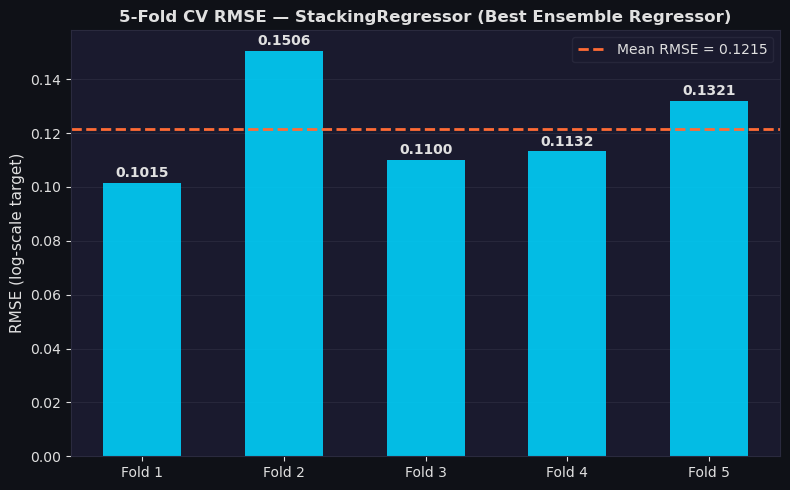

Saved: p5_reg_cv_rmse.png


In [227]:
import matplotlib.pyplot as plt

fold_labels = [f'Fold {i}' for i in range(1, 6)]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(AX)

bars = ax.bar(fold_labels, cv_reg_rmse, color=C1, edgecolor='none', alpha=0.88, width=0.55)

# Annotate bar tops
for bar, val in zip(bars, cv_reg_rmse):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom',
            color=TC, fontsize=10, fontweight='bold')

# Mean line
ax.axhline(cv_reg_rmse.mean(), color=C2, linestyle='--', linewidth=2,
           label=f'Mean RMSE = {cv_reg_rmse.mean():.4f}')

ax.set_ylabel('RMSE (log-scale target)', color=TC, fontsize=11)
ax.set_title(f'5-Fold CV RMSE — {type(best_ensemble_reg).__name__} (Best Ensemble Regressor)',
             color=TC, fontsize=12, fontweight='bold')
ax.tick_params(colors=TC)
ax.spines[:].set_color(GC)
ax.yaxis.grid(True, color=GC, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor=AX, labelcolor=TC, edgecolor=GC)

plt.tight_layout()
plt.savefig('p5_reg_cv_rmse.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: p5_reg_cv_rmse.png")


### Step 2: Cross-Validation Stability — Best Classification Ensemble

For classification, we use **Stratified** K-Fold instead of plain K-Fold. Stratification ensures that each fold contains roughly the same proportion of Low, Mid, High, and Elite players as the full dataset. Without it, a fold might accidentally contain very few Elite players, making accuracy estimates unreliable.

We compare the best A3 ensemble against the **A2 Logistic Regression** baseline (best C, L2) from Task 7, checking both mean accuracy and standard deviation across folds.

In [228]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_cls_scores = cross_val_score(
    best_ensemble_cls,
    X_train_cls, y_train_cls_i,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
)

p5_cls_cv_mean = round(float(cv_cls_scores.mean()), 4)
p5_cls_cv_std  = round(float(cv_cls_scores.std()),  4)

print("── Stratified 5-Fold CV Accuracy — Best Ensemble Classifier ──")
for i, acc in enumerate(cv_cls_scores, 1):
    print(f"  Fold {i}: Accuracy = {acc:.4f}")
print(f"\n  Mean Accuracy : {p5_cls_cv_mean}")
print(f"  Std  Accuracy : {p5_cls_cv_std}")


A2_LR_ACC_MEAN = lr_scores.mean()  
A2_LR_ACC_STD  = lr_scores.std()

print(f"\n── Stability Comparison (Classification) ──")
print(f"  A2 Logistic Regression   Mean Acc = {A2_LR_ACC_MEAN:.4f}  Std = {A2_LR_ACC_STD:.4f}")
print(f"  A3 Best Ensemble         Mean Acc = {p5_cls_cv_mean:.4f}  Std = {p5_cls_cv_std:.4f}")
more_stable = 'YES ✓' if p5_cls_cv_std <= A2_LR_ACC_STD else 'No — higher variance'
higher_acc  = 'YES ✓' if p5_cls_cv_mean >= A2_LR_ACC_MEAN else 'No'
print(f"  More stable than A2? → {more_stable}")
print(f"  Higher accuracy?     → {higher_acc}")


── Stratified 5-Fold CV Accuracy — Best Ensemble Classifier ──
  Fold 1: Accuracy = 0.8567
  Fold 2: Accuracy = 0.8659
  Fold 3: Accuracy = 0.8554
  Fold 4: Accuracy = 0.8516
  Fold 5: Accuracy = 0.8643

  Mean Accuracy : 0.8588
  Std  Accuracy : 0.0055

── Stability Comparison (Classification) ──
  A2 Logistic Regression   Mean Acc = 0.7711  Std = 0.0081
  A3 Best Ensemble         Mean Acc = 0.8588  Std = 0.0055
  More stable than A2? → YES ✓
  Higher accuracy?     → YES ✓


#### Cross-Validation Accuracy per Fold — Classification

Each bar shows the accuracy on the held-out fold. Consistent bar heights confirm that the ensemble generalizes reliably and is not overfitting to any particular split of the training data.

A model with high mean accuracy but high standard deviation is unreliable in practice — it performs well on some data distributions and poorly on others. We want both: **high mean and low std**.

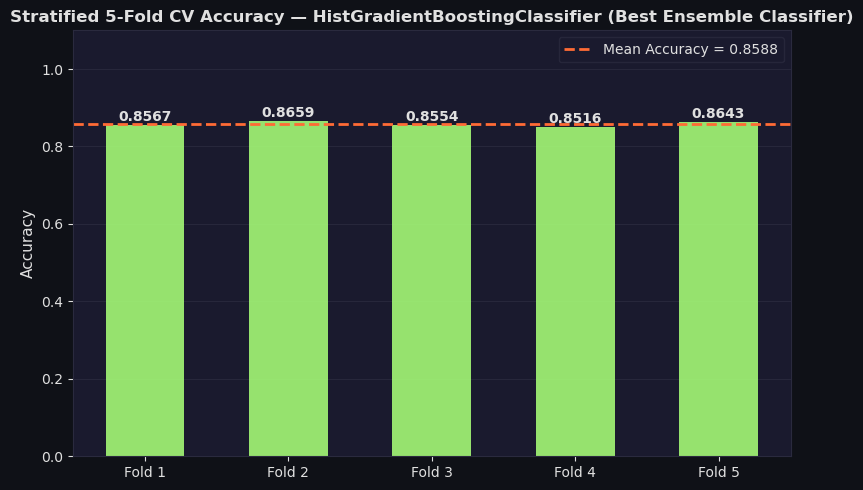

Saved: p5_cls_cv_acc.png


In [229]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(AX)

bars = ax.bar(fold_labels, cv_cls_scores, color=C3, edgecolor='none', alpha=0.88, width=0.55)

for bar, val in zip(bars, cv_cls_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom',
            color=TC, fontsize=10, fontweight='bold')

ax.axhline(cv_cls_scores.mean(), color=C2, linestyle='--', linewidth=2,
           label=f'Mean Accuracy = {cv_cls_scores.mean():.4f}')

ax.set_ylabel('Accuracy', color=TC, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title(f'Stratified 5-Fold CV Accuracy — {type(best_ensemble_cls).__name__} (Best Ensemble Classifier)',
             color=TC, fontsize=12, fontweight='bold')
ax.tick_params(colors=TC)
ax.spines[:].set_color(GC)
ax.yaxis.grid(True, color=GC, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor=AX, labelcolor=TC, edgecolor=GC)

plt.tight_layout()
plt.savefig('p5_cls_cv_acc.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: p5_cls_cv_acc.png")


### Step 3: Collect All A2 Baseline Metrics

Before building the full comparison table, we retrieve the test-set scores for every model trained in Assignment 2:

- **Linear Regression** (degree 1, single feature and all features)
- **Polynomial Regression** (best degree)
- **Ridge** and **Lasso** at their best alpha values
- **Logistic Regression** baseline and best-C L2 version
- **GaussianNB** (scaled)

These are paired with the A3 individual model and ensemble scores in the next step to produce a unified comparison across both assignments.

In [230]:
# Linear Regression
a2_lin_mae  = round(float(mae(y_test,  y_pred_test)), 4)
a2_lin_rmse = round(float(rmse(y_test, y_pred_test)), 4)
a2_lin_r2   = round(float(r2(y_test,   y_pred_test)), 4)

# Polynomial deg-4
a2_poly4_mae  = round(float(mae(y_test,  y_predict_poly_test)), 4)
a2_poly4_rmse = round(float(rmse(y_test, y_predict_poly_test)), 4)
a2_poly4_r2   = round(float(r2(y_test,   y_predict_poly_test)), 4)

# Ridge (best alpha)
a2_ridge_mae  = round(float(mae(y_test,  ridge_models[best_idx_ridge].predict(x_test_final))), 4)
a2_ridge_rmse = round(float(rmse_ridge_test[best_idx_ridge]), 4)
a2_ridge_r2   = round(float(r2(y_test,   ridge_models[best_idx_ridge].predict(x_test_final))), 4)

# Lasso (best alpha)
a2_lasso_mae  = round(float(mae(y_test,  lasso_models[best_idx_lasso].predict(x_test_final))), 4)
a2_lasso_rmse = round(float(rmse_lasso_test[best_idx_lasso]), 4)
a2_lasso_r2   = round(float(r2(y_test,   lasso_models[best_idx_lasso].predict(x_test_final))), 4)

# Baseline Logistic Regression
_log_pred       = log_model.predict(x_test_clf)
a2_lr_base_acc  = round(float(accuracy_score(y_test_clf, _log_pred)), 4)
a2_lr_base_f1   = round(float(f1_score(y_test_clf, _log_pred, average='weighted', zero_division=0)), 4)

# Best-C L2 Logistic Regression (model_l2)
_l2_pred        = model_l2.predict(x_test_clf)
a2_lr_l2_acc    = round(float(accuracy_score(y_test_clf, _l2_pred)), 4)
a2_lr_l2_f1     = round(float(f1_score(y_test_clf, _l2_pred, average='weighted', zero_division=0)), 4)

# GaussianNB (scaled version — acc_gnb_s already computed in A2)
a2_gnb_acc      = round(float(acc_gnb_s), 4)
a2_gnb_f1       = round(float(f1_gnb_s),  4)


### Step 4: Full Model Comparison Tables

Two summary tables are built — one for regression, one for classification — covering every model from both assignments evaluated on the **same held-out test set**.

**Regression table** columns: Assignment, Model, MAE, RMSE, R²
**Classification table** columns: Assignment, Model, Accuracy, F1 (weighted)

The best model in each table is identified automatically. A lower RMSE is better for regression; a higher accuracy is better for classification. The `reg_metrics` and `cls_metrics` helper functions ensure all scores are computed identically, making the comparison fair.

In [231]:
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score
)

def reg_metrics(model, X, y):
    p = model.predict(X)
    return (round(mean_absolute_error(y, p), 4),
            round(np.sqrt(mean_squared_error(y, p)), 4),
            round(r2_score(y, p), 4))

def cls_metrics(model, X, y):
    p = model.predict(X)
    return (round(accuracy_score(y, p), 4),
            round(f1_score(y, p, average='weighted', zero_division=0), 4))

reg_rows = [
    # Assignment 2 models
    ('A2', 'Linear Regression (deg 1)', a2_lin_mae,   a2_lin_rmse,   a2_lin_r2),
    ('A2', f'Polynomial Reg (deg {best_poly_degree})', a2_poly4_mae, a2_poly4_rmse, a2_poly4_r2),
    ('A2', f'Ridge (deg {best_poly_degree}, α={best_alpha_ridge:.4f})', a2_ridge_mae, a2_ridge_rmse, a2_ridge_r2),
    ('A2', f'Lasso (deg {best_poly_degree}, α={best_alpha_lasso:.4f})', a2_lasso_mae, a2_lasso_rmse, a2_lasso_r2),
    # Assignment 3 individual models (Test Set)
    ('A3', 'KNN Regressor (tuned)', *reg_metrics(best_knn_reg, X_test_reg, y_test_reg)),
    ('A3', 'SVR (tuned)', *reg_metrics(best_svr,     X_test_reg, y_test_reg)),
    ('A3', 'Random Forest Reg (tuned)', *reg_metrics(best_rf_reg,  X_test_reg, y_test_reg)),
    # Assignment 3 ensembles (Test Set)
    ('A3', 'Voting Regressor', *reg_metrics(voting_reg,        X_test_reg, y_test_reg)),
    ('A3', 'GBM Regressor (tuned)',*reg_metrics(best_gb_reg,       X_test_reg, y_test_reg)),
    ('A3', 'Stacking Regressor', *reg_metrics(stacking_reg,      X_test_reg, y_test_reg)),
    ('A3', f'BEST Ensemble Reg ({best_reg_name})',*reg_metrics(best_ensemble_reg, X_test_reg, y_test_reg)),
]

reg_df = pd.DataFrame(reg_rows, columns=['Assignment', 'Model', 'MAE', 'RMSE', 'R²'])
print("        REGRESSION — FULL MODEL COMPARISON TABLE")
print(reg_df.to_string(index=False))

# ─── Classification Table ─────────────────────────────────────────────────────
cls_rows = [
    # Assignment 2 models
    ('A2', 'Logistic Regression (baseline)', a2_lr_base_acc, a2_lr_base_f1),
    ('A2', f'Logistic Reg (L2, best C={best_C:.4f})', a2_lr_l2_acc,   a2_lr_l2_f1),
    ('A2', 'GaussianNB', a2_gnb_acc,     a2_gnb_f1),
    # Assignment 3 individual models
    ('A3', 'KNN Classifier (tuned)', *cls_metrics(best_knn_cls, X_test_cls, y_test_cls_i)),
    ('A3', 'SVC (tuned)', *cls_metrics(best_svc,     X_test_cls, y_test_cls_i)),
    ('A3', 'Random Forest Cls (tuned)', *cls_metrics(best_rf_cls,  X_test_cls, y_test_cls_i)),
    # Assignment 3 ensembles
    ('A3', f'Voting Classifier ({vote_type})', *cls_metrics(voting_cls,        X_test_cls, y_test_cls_i)),
    ('A3', 'GBM Classifier (tuned)', *cls_metrics(best_gb_cls,       X_test_cls, y_test_cls_i)),
    ('A3', 'Stacking Classifier',*cls_metrics(stacking_cls,      X_test_cls, y_test_cls_i)),
    ('A3', f'BEST Ensemble Cls ({best_cls_name})', *cls_metrics(best_ensemble_cls, X_test_cls, y_test_cls_i))
]

cls_df = pd.DataFrame(cls_rows, columns=['Assignment', 'Model', 'Accuracy', 'F1 (weighted)'])
print("      CLASSIFICATION — FULL MODEL COMPARISON TABLE")
print(cls_df.to_string(index=False))

        REGRESSION — FULL MODEL COMPARISON TABLE
Assignment                        Model    MAE   RMSE     R²
        A2    Linear Regression (deg 1) 0.2354 0.3849 0.7475
        A2       Polynomial Reg (deg 4) 0.1065 0.2276 0.9117
        A2    Ridge (deg 4, α=104.8113) 0.1059 0.2240 0.9144
        A2      Lasso (deg 4, α=0.0010) 0.1052 0.2243 0.9142
        A3        KNN Regressor (tuned) 0.0753 0.1647 0.9538
        A3                  SVR (tuned) 0.0674 0.1536 0.9598
        A3    Random Forest Reg (tuned) 0.0380 0.1313 0.9706
        A3             Voting Regressor 0.0515 0.1310 0.9708
        A3        GBM Regressor (tuned) 0.0496 0.1340 0.9694
        A3           Stacking Regressor 0.0407 0.1255 0.9732
        A3 BEST Ensemble Reg (Stacking) 0.0407 0.1255 0.9732
      CLASSIFICATION — FULL MODEL COMPARISON TABLE
Assignment                             Model  Accuracy  F1 (weighted)
        A2    Logistic Regression (baseline)    0.7768         0.7781
        A2 Logistic Reg (L2,

### Step 5: Styled Visual Comparison Tables

The comparison tables are rendered as styled matplotlib figures with color-coded rows:

- **Dark blue rows** → Assignment 2 models
- **Dark grey rows** → Assignment 3 models
- **Green highlighted cell** → the single best score in the highlighted column

This visual format makes it immediately clear how much each progression — from linear models to individual learners to ensembles — improved performance, and which model should be used in a production setting.

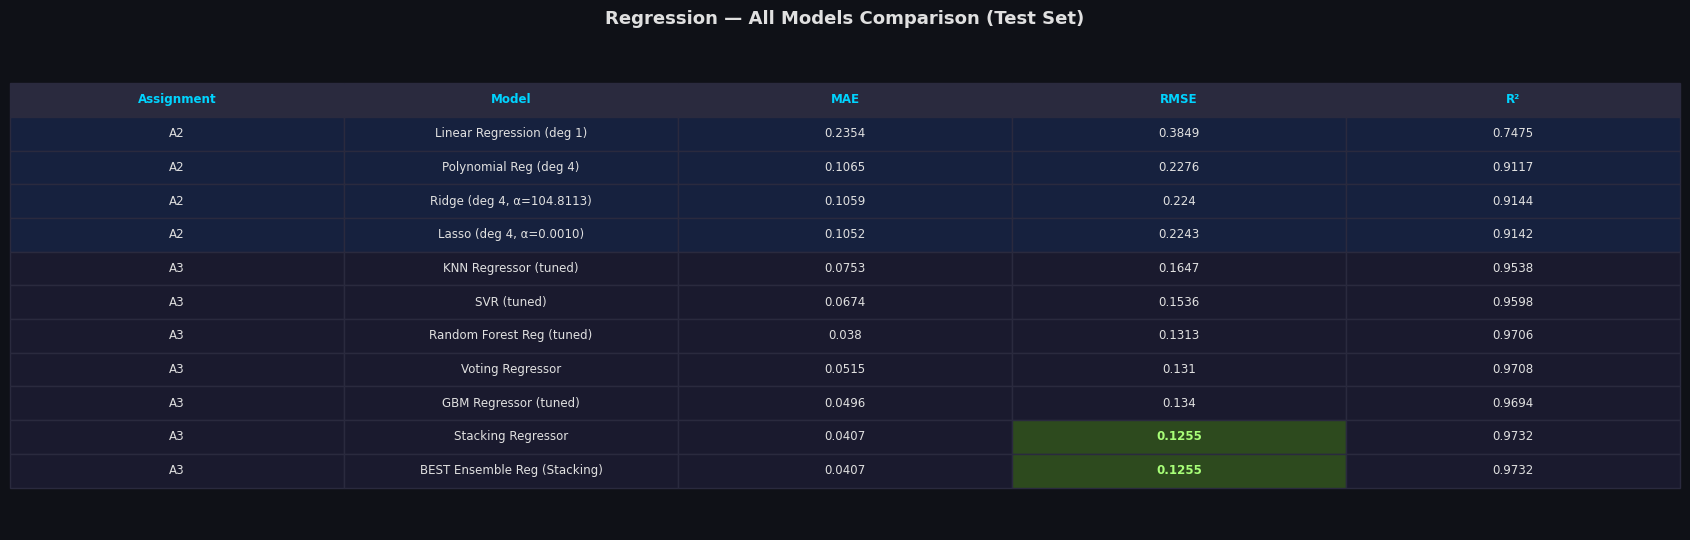

Saved: p5_reg_comparison_table.png


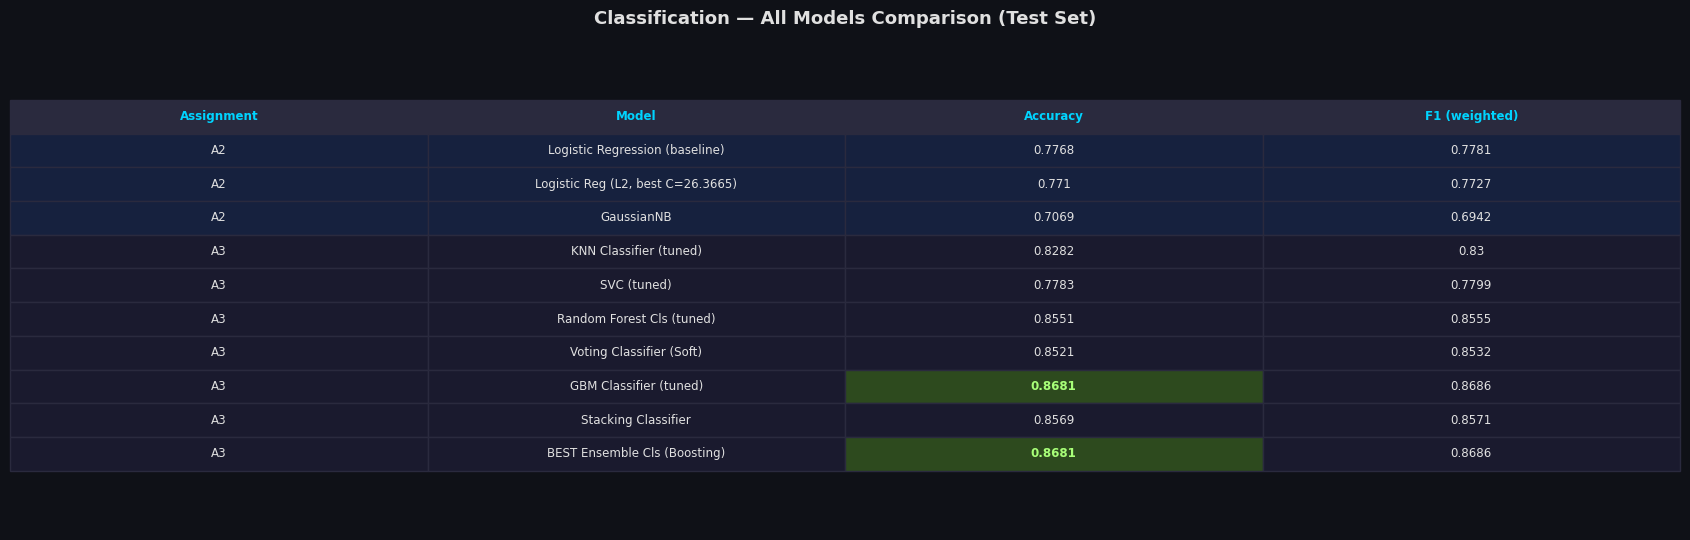

Saved: p5_cls_comparison_table.png


In [232]:
def render_table(df, title, highlight_col, higher_is_better=True, figsize=(16, 4.5)):
    fig, ax = plt.subplots(figsize=figsize, facecolor=BG)
    ax.set_facecolor(BG)
    ax.axis('off')

    tbl = ax.table(
        cellText   = df.values,
        colLabels  = df.columns,
        loc        = 'center',
        cellLoc    = 'center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.75)

    col_idx = list(df.columns).index(highlight_col)
    vals    = [float(df.iloc[r, col_idx]) for r in range(len(df))]
    best_v  = max(vals) if higher_is_better else min(vals)

    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2a2a3e')
            cell.set_text_props(color='#00d4ff', fontweight='bold')
        else:
            # Highlight A2 vs A3
            assign = df.iloc[row - 1, 0]
            base   = '#16213e' if assign == 'A2' else '#1a1a2e'
            cell.set_facecolor(base)
            cell.set_text_props(color=TC)
            # Gold highlight for best model in highlight column
            if col == col_idx and float(df.iloc[row - 1, col_idx]) == best_v:
                cell.set_facecolor('#2d4a1e')
                cell.set_text_props(color='#a8ff78', fontweight='bold')
        cell.set_edgecolor(GC)

    ax.set_title(title, color=TC, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig

# Regression
fig_reg = render_table(reg_df, 'Regression — All Models Comparison (Test Set)',
                       highlight_col='RMSE', higher_is_better=False, figsize=(17, 5.5))
fig_reg.savefig('p5_reg_comparison_table.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: p5_reg_comparison_table.png")

# Classification
fig_cls = render_table(cls_df, 'Classification — All Models Comparison (Test Set)',
                       highlight_col='Accuracy', higher_is_better=True, figsize=(17, 5.5))
fig_cls.savefig('p5_cls_comparison_table.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: p5_cls_comparison_table.png")


### Step 6: Export Results to JSON

All metrics, best hyperparameters, and cross-validation stability scores are collected into a single structured dictionary and saved as `results.json`.

The JSON file contains four top-level keys:
- `best_hyperparameters` — the winning parameters from GridSearchCV for KNN, SVM, RF, and the ensemble methods
- `regression_results` — MAE, RMSE, and R² for every regression model from A2 and A3
- `classification_results` — Accuracy and F1 for every classifier from A2 and A3
- `p5_stability_summary` — the CV mean and std for the best ensemble vs the best A2 baseline, with a boolean flag indicating whether the ensemble is more stable

This file serves as the single source of truth for all reported results.

In [233]:
results = {

    # Best Hyperparameters from all persons
    "best_hyperparameters": {
        "Person_1_KNN": p1_best_params,
        "Person_2_SVM": p2_best_params,
        "Person_3_RF":  p3_best_params,
        "Person_4_Ensembles": p4_best_params,
    },

    #  Regression Results
    "regression_results": {

        "A2_Linear_Regression":  {"MAE": a2_lin_mae,   "RMSE": a2_lin_rmse,   "R2": a2_lin_r2},
        "A2_Polynomial_deg4":    {"MAE": a2_poly4_mae,  "RMSE": a2_poly4_rmse,  "R2": a2_poly4_r2},
        "A2_Ridge_deg4":         {"MAE": a2_ridge_mae,  "RMSE": a2_ridge_rmse,  "R2": a2_ridge_r2,
                                  "best_alpha": round(float(best_alpha_ridge), 6),
                                  "cv_5fold_rmse_mean": A2_RIDGE_RMSE_MEAN,
                                  "cv_5fold_rmse_std":  A2_RIDGE_RMSE_STD},
        "A2_Lasso_deg4":         {"MAE": a2_lasso_mae,  "RMSE": a2_lasso_rmse,  "R2": a2_lasso_r2,
                                  "best_alpha": round(float(best_alpha_lasso), 6)},

        "A3_KNN_Reg": {
            "MAE":  round(indiv_reg['KNN'][0], 4),
            "RMSE": round(indiv_reg['KNN'][1], 4),
            "R2":   round(indiv_reg['KNN'][2], 4),
        },
        "A3_SVR": {
            "MAE":  round(indiv_reg['SVR'][0], 4),
            "RMSE": round(indiv_reg['SVR'][1], 4),
            "R2":   round(indiv_reg['SVR'][2], 4),
        },
        "A3_RF_Reg": {
            "MAE":  round(indiv_reg['RF'][0], 4),
            "RMSE": round(indiv_reg['RF'][1], 4),
            "R2":   round(indiv_reg['RF'][2], 4),
        },
        "A3_Voting_Reg": {
            "MAE":  round(voting_reg_mae,  4),
            "RMSE": round(voting_reg_rmse, 4),
            "R2":   round(voting_reg_r2,   4),
        },
        "A3_GBM_Reg": {
            "MAE":  round(boosting_reg_mae,  4),
            "RMSE": round(boosting_reg_rmse, 4),
            "R2":   round(boosting_reg_r2,   4),
        },
        "A3_Stacking_Reg": {
            "MAE":  round(stacking_reg_mae,  4),
            "RMSE": round(stacking_reg_rmse, 4),
            "R2":   round(stacking_reg_r2,   4),
        },
        f"A3_Best_Ensemble_Reg_{best_reg_name}": {
            "cv_5fold_rmse_mean": p5_reg_cv_mean,
            "cv_5fold_rmse_std":  p5_reg_cv_std,
        },
    },

    # Classification Results
    "classification_results": {

        "A2_Logistic_Reg_baseline": {"Accuracy": a2_lr_base_acc, "F1_weighted": a2_lr_base_f1},
        "A2_Logistic_Reg_best_C_L2":{"Accuracy": a2_lr_l2_acc,  "F1_weighted": a2_lr_l2_f1,
                                     "best_C": round(float(best_C), 6),
                                     "cv_5fold_acc_mean": round(float(lr_scores.mean()), 4),
                                     "cv_5fold_acc_std":  round(float(lr_scores.std()),  4)},
        "A2_GaussianNB":             {"Accuracy": a2_gnb_acc,    "F1_weighted": a2_gnb_f1},

        "A3_KNN_Cls": {
            "Accuracy":    round(indiv_cls['KNN'][0], 4),
            "F1_weighted": round(indiv_cls['KNN'][1], 4),
        },
        "A3_SVC": {
            "Accuracy":    round(indiv_cls['SVC'][0], 4),
            "F1_weighted": round(indiv_cls['SVC'][1], 4),
        },
        "A3_RF_Cls": {
            "Accuracy":    round(indiv_cls['RF'][0], 4),
            "F1_weighted": round(indiv_cls['RF'][1], 4),
        },
        "A3_Voting_Cls": {
            "Accuracy":    round(voting_cls_acc, 4),
            "F1_weighted": round(voting_cls_f1,  4),
            "voting_type": vote_type,
        },
        "A3_GBM_Cls": {
            "Accuracy":    round(boosting_cls_acc, 4),
            "F1_weighted": round(boosting_cls_f1,  4),
        },
        "A3_Stacking_Cls": {
            "Accuracy":    round(stacking_cls_acc, 4),
            "F1_weighted": round(stacking_cls_f1,  4),
        },
        f"A3_Best_Ensemble_Cls_{best_cls_name}": {
            "cv_5fold_acc_mean": p5_cls_cv_mean,
            "cv_5fold_acc_std":  p5_cls_cv_std,
        },
    },

    # Person 5 CV Stability Summary 
    "p5_stability_summary": {
        "regression": {
            "model":            f"best_ensemble_reg ({best_reg_name})",
            "cv_mean_rmse":     p5_reg_cv_mean,
            "cv_std_rmse":      p5_reg_cv_std,
            "a2_ridge_std":     A2_RIDGE_RMSE_STD,
            "more_stable_than_a2": bool(p5_reg_cv_std <= A2_RIDGE_RMSE_STD),
        },
        "classification": {
            "model":            f"best_ensemble_cls ({best_cls_name})",
            "cv_mean_acc":      p5_cls_cv_mean,
            "cv_std_acc":       p5_cls_cv_std,
            "a2_lr_std":        round(float(lr_scores.std()), 4),
            "more_stable_than_a2": bool(p5_cls_cv_std <= lr_scores.std()),
        },
    },
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\nresults.json saved.")
print(f"  Regression models    : {len(results['regression_results'])}")
print(f"  Classification models: {len(results['classification_results'])}")



results.json saved.
  Regression models    : 11
  Classification models: 10


In [234]:
with open('results.json', 'r') as f:
    loaded = json.load(f)

print("✔  results.json round-trip validation passed.")
print()
print(json.dumps(loaded, indent=4))


✔  results.json round-trip validation passed.

{
    "best_hyperparameters": {
        "Person_1_KNN": {
            "knn_regression": {
                "metric": "manhattan",
                "n_neighbors": 5,
                "weights": "distance"
            },
            "knn_classification": {
                "metric": "manhattan",
                "n_neighbors": 15,
                "weights": "distance"
            }
        },
        "Person_2_SVM": {
            "SVR": {
                "C": 10,
                "gamma": "scale",
                "kernel": "rbf"
            },
            "SVC": {
                "C": 10,
                "decision_function_shape": "ovr"
            }
        },
        "Person_3_RF": {
            "rf_reg": {
                "max_depth": 30,
                "min_samples_split": 2,
                "n_estimators": 300
            },
            "rf_cls": {
                "max_depth": null,
                "min_samples_split": 5,
                "n_